# 03 Deep Dive: Tối ưu tồn kho

Notebook này trả lời một câu hỏi quản trị: doanh nghiệp nên phân bổ lại tồn kho như thế nào để giảm thất thoát doanh thu mà không làm tăng vốn bị khóa trong kho?

Câu chuyện chính gồm 4 bước:

1. **What happened?** Stockout và overstock có nghiêm trọng không?
2. **Why?** Vấn đề tập trung ở category/SKU nào?
3. **What next?** Tín hiệu nào cảnh báo rủi ro thiếu hàng kỳ tới?
4. **What should we do?** Nên ưu tiên SKU/nhóm sản phẩm nào trước?

Thông điệp xuyên suốt: đây không phải bài toán “nhập thêm hàng”, mà là bài toán **tái phân bổ tồn kho theo tác động tài chính**.

## Bản đồ 4 cấp độ phân tích

Phần này giúp người đọc biết notebook đang đi theo logic nào. Một bài EDA tốt không chỉ đưa ra nhiều biểu đồ, mà phải đi từ hiện trạng đến hành động.

| Cấp độ phân tích | Câu hỏi đơn giản | Phần trong notebook | Kết quả mong muốn |
|---|---|---|---|
| **Descriptive** | Chuyện gì đang xảy ra? | Section 3-3.1 | Giải thích rõ thiếu hàng, dư hàng, fill rate và days of supply |
| **Diagnostic** | Vì sao xảy ra? | Sections 4-7.1 và 14 | Biết vấn đề tập trung ở nhóm nào, mã nào, và có liên quan promotion/traffic/returns không |
| **Predictive** | Điều gì có thể xảy ra tiếp? | Sections 8-10 | Hiểu vì sao ROP yếu, hiệu chỉnh ROP và tạo danh sách rủi ro thiếu hàng |
| **Prescriptive** | Nên làm gì? | Sections 11-13.1 | Có ROI, kịch bản thực tế, owner và timeline hành động |

Nói ngắn gọn: notebook này không chỉ dừng ở việc “mô tả dữ liệu”, mà trả lời câu hỏi quan trọng hơn: **doanh nghiệp nên ra quyết định gì, tốn bao nhiêu vốn, ai làm và trong bao lâu?**

## Glossary: Các thuật ngữ chính

| Thuật ngữ | Ý nghĩa dễ hiểu | Vì sao quan trọng |
|---|---|---|
| SKU / Mã sản phẩm | Một sản phẩm cụ thể trong danh mục | Giúp phân tích ở cấp sản phẩm chi tiết |
| Stockout | Tình trạng thiếu hàng | Có thể làm mất doanh thu |
| Overstock | Tình trạng dư hàng | Làm vốn bị khóa trong kho |
| Fill rate | Tỷ lệ nhu cầu/đơn hàng được đáp ứng | Đo khả năng phục vụ khách hàng |
| Days of supply | Số ngày tồn kho có thể đủ bán theo tốc độ hiện tại | Cao bất thường có thể là hàng bán chậm |
| ROP | Điểm đặt hàng lại | Dùng để cảnh báo khi cần bổ sung hàng |
| Safety stock | Tồn kho an toàn | Giúp giảm rủi ro thiếu hàng khi nhu cầu biến động |
| Lost revenue | Doanh thu ước tính bị mất | Quy đổi stockout thành tác động tài chính |
| Locked capital | Vốn bị khóa trong hàng tồn | Cho biết tiền đang nằm trong hàng dư |


## Metric Definitions: Cách hiểu và công thức

| Metric | Cách tính trong notebook | Cách hiểu |
|---|---|---|
| stockout_rate | Trung bình của `stockout_flag` | % product-month có phát sinh thiếu hàng |
| overstock_rate | Trung bình của `overstock_flag` | % product-month có phát sinh dư hàng |
| fill_rate | Có sẵn trong dữ liệu | Mức đáp ứng đơn hàng trung bình |
| gross_margin_per_unit | `price - cogs` | Lợi nhuận gộp trên mỗi sản phẩm |
| gross_margin_rate | `(price - cogs) / price` | Tỷ lệ lợi nhuận gộp |
| demand_est_3m | Trung bình `units_sold` 3 tháng trước | Proxy cho nhu cầu kỳ vọng |
| lost_units_est | `max(0, demand_est_3m - units_sold)` khi stockout | Số lượng bán bị mất ước tính |
| lost_revenue_est | `lost_units_est × price` | Doanh thu bị mất ước tính |
| lost_margin_est | `lost_units_est × gross_margin_per_unit` | Lợi nhuận gộp bị mất ước tính |
| inventory_value | `stock_on_hand × cogs` | Giá trị hàng tồn theo giá vốn |
| dynamic_rop | `lead_time_demand + safety_stock` | Mức tồn kho tối thiểu nên có |
| priority_score | `lost_revenue × margin_rate × (1 + stockout_rate)` | Điểm ưu tiên xử lý SKU |


## **1. [Business Context] Định nghĩa vấn đề**

Hãy tưởng tượng doanh nghiệp đang bán thời trang online. Nếu khách muốn mua một sản phẩm nhưng sản phẩm đó hết hàng, doanh nghiệp mất doanh thu ngay tại thời điểm đó. Nhưng nếu nhập quá nhiều những sản phẩm bán chậm, tiền lại bị nằm trong kho và có thể phải giảm giá để bán ra.

Vì vậy tồn kho luôn có hai rủi ro đối nghịch:

- **Thiếu hàng:** khách có nhu cầu nhưng không đủ hàng để bán.
- **Dư hàng:** có hàng trong kho nhưng hàng đó không bán đủ nhanh.

Điểm khó là hai vấn đề này có thể xảy ra cùng lúc. Một số mã sản phẩm bán tốt thì thiếu hàng, trong khi một số mã khác lại dư rất nhiều. Khi đó, giải pháp không phải là “nhập thêm hàng cho tất cả”, mà là **đặt đúng lượng hàng vào đúng mã sản phẩm**.

Notebook này sẽ giúp trả lời câu hỏi mà stakeholder thường quan tâm: **nếu phải cải thiện tồn kho, nên bắt đầu từ đâu để vừa tăng doanh thu vừa không làm vốn bị kẹt thêm trong kho?**

## **2. [Preparation] Chuẩn bị dữ liệu**

Phần này giống như bước chuẩn bị nguyên liệu trước khi nấu ăn. Dữ liệu tồn kho cho ta biết sản phẩm nào thiếu hàng, sản phẩm nào dư hàng, nhưng chỉ như vậy thì chưa đủ để ra quyết định kinh doanh.

Ví dụ: hai sản phẩm cùng thiếu hàng 10 lần, nhưng một sản phẩm có giá bán và lợi nhuận cao hơn sản phẩm còn lại. Khi đó, sản phẩm có lợi nhuận cao nên được ưu tiên xử lý trước.

Vì vậy notebook cần ghép thêm thông tin từ bảng sản phẩm, đặc biệt là:

- **Giá bán (`price`)**: để ước tính doanh thu bị mất.
- **Giá vốn (`cogs`)**: để ước tính lợi nhuận gộp bị mất và vốn đang bị khóa.
- **Category/segment**: để xem vấn đề tập trung ở nhóm sản phẩm nào.

Sau bước này, mỗi dòng dữ liệu không chỉ nói “sản phẩm này thiếu/dư hàng”, mà còn giúp trả lời “việc thiếu/dư đó ảnh hưởng bao nhiêu đến tiền”.

In [1]:
# Core
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Path setup: works when executed from repo root or from notebooks/
CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / 'dataset').exists() else CWD.parent
DATA_DIR = PROJECT_ROOT / 'dataset'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

BACKGROUND = '#F6F8FB'
CARD = '#FFFFFF'
TEXT = '#1F2937'
MUTED = '#6B7280'
GRID = '#D8DEE8'
PALETTE = {
    'stockout': '#2563EB',
    'overstock': '#F59E0B',
    'stable': '#16A34A',
    'volatile': '#DC2626',
    'neutral': '#475569',
    'accent': '#0891B2',
    'warning': '#EAB308',
    'ink': TEXT,
    'muted': MUTED
}
GROUP_COLORS = {
    'Thiếu hàng thường xuyên': PALETTE['stockout'],
    'Dư hàng': PALETTE['overstock'],
    'Tồn kho biến động': PALETTE['volatile'],
    'Ổn định': PALETTE['stable']
}

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)


sns.set_theme(
    style='whitegrid',
    context='notebook',
    rc={
        'axes.facecolor': CARD,
        'figure.facecolor': BACKGROUND,
        'axes.edgecolor': '#CBD5E1',
        'axes.labelcolor': TEXT,
        'xtick.color': MUTED,
        'ytick.color': MUTED,
        'text.color': TEXT,
        'grid.color': GRID,
        'grid.alpha': 0.45,
        'axes.titleweight': 'bold',
        'axes.titlesize': 13,
        'axes.labelsize': 10,
        'font.family': 'DejaVu Sans'
    }
)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 160,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlepad': 12
})


def fmt_number(value, decimals=0):
    if pd.isna(value):
        return 'NA'
    return f'{value:,.{decimals}f}'


def fmt_currency(value, decimals=1):
    if pd.isna(value):
        return 'NA'
    if abs(value) >= 1_000_000:
        return f'{value / 1_000_000:,.{decimals}f}M'
    if abs(value) >= 1_000:
        return f'{value / 1_000:,.{decimals}f}K'
    return f'{value:,.{decimals}f}'


def fmt_percent(value, decimals=1):
    if pd.isna(value):
        return 'NA'
    return f'{value * 100:.{decimals}f}%'


def clean_axis(ax, title, xlabel, ylabel, subtitle=None):
    ax.set_title(title, loc='left', fontsize=13, fontweight='bold', color=TEXT, pad=12)
    if subtitle:
        ax.text(0, 1.01, subtitle, transform=ax.transAxes, ha='left', va='bottom', fontsize=9, color=MUTED)
    ax.set_xlabel(xlabel, color=TEXT)
    ax.set_ylabel(ylabel, color=TEXT)
    ax.grid(axis='y', alpha=0.35)
    ax.grid(axis='x', alpha=0.18)
    ax.set_axisbelow(True)
    return ax


def kpi_card(ax, title, value, subtitle, color):
    ax.set_axis_off()
    card = FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle='round,pad=0.018,rounding_size=0.035',
        linewidth=1.1,
        edgecolor='#D8DEE8',
        facecolor=CARD,
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(card)
    ax.add_patch(plt.Rectangle((0, 0), 0.025, 1, transform=ax.transAxes, color=color, clip_on=False))
    ax.text(0.08, 0.76, title, transform=ax.transAxes, fontsize=9.5, color=MUTED, weight='bold')
    ax.text(0.08, 0.40, value, transform=ax.transAxes, fontsize=20, color=TEXT, weight='bold')
    ax.text(0.08, 0.16, subtitle, transform=ax.transAxes, fontsize=8.5, color=MUTED)


def label_hbars(ax, fmt=lambda v: f'{v:,.0f}', pad=0.012, fontsize=9, color=TEXT):
    xmax = ax.get_xlim()[1]
    ax.margins(x=0.14)
    for patch in ax.patches:
        width = patch.get_width()
        ax.text(
            width + xmax * pad,
            patch.get_y() + patch.get_height() / 2,
            fmt(width),
            va='center',
            ha='left',
            fontsize=fontsize,
            color=color,
            weight='bold'
        )


def label_vbars(ax, fmt=lambda v: f'{v:,.0f}', fontsize=9, color=TEXT):
    ymax = ax.get_ylim()[1]
    ax.margins(y=0.18)
    for patch in ax.patches:
        height = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + ymax * 0.018,
            fmt(height),
            va='bottom',
            ha='center',
            fontsize=fontsize,
            color=color,
            weight='bold'
        )


def top_n_barh(df, x, y, title, xlabel, ylabel='', n=20, color='#2563EB', value_format=None, figsize=(11, 7)):
    plot_df = df.sort_values(x, ascending=False).head(n).sort_values(x, ascending=True)
    colors = sns.light_palette(color, n_colors=len(plot_df) + 2, reverse=False)[2:]
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(plot_df[y].astype(str), plot_df[x], color=colors, edgecolor='white', linewidth=0.8)
    clean_axis(ax, title, xlabel, ylabel, subtitle=f'Top {min(n, len(plot_df))} ranked by {x}')
    if value_format is not None:
        label_hbars(ax, fmt=value_format)
    plt.tight_layout()
    plt.show()

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')


PROJECT_ROOT: /home/ductien/Documents/DATATHON_2026
DATA_DIR: /home/ductien/Documents/DATATHON_2026/dataset
OUTPUT_DIR: /home/ductien/Documents/DATATHON_2026/outputs


In [2]:
inventory = pd.read_csv(DATA_DIR / 'inventory.csv', parse_dates=['snapshot_date'])
products = pd.read_csv(DATA_DIR / 'products.csv')

inv = inventory.copy()

inv['year'] = inv['snapshot_date'].dt.year
inv['month'] = inv['snapshot_date'].dt.month
inv['year_month'] = inv['snapshot_date'].dt.to_period('M').astype(str)

if 'price' not in inv.columns or 'cogs' not in inv.columns:
    inv = inv.merge(
        products[['product_id', 'price', 'cogs']],
        on='product_id',
        how='left'
    )

inv['gross_margin_per_unit'] = inv['price'] - inv['cogs']
inv['gross_margin_rate'] = np.where(
    inv['price'] > 0,
    inv['gross_margin_per_unit'] / inv['price'],
    np.nan
)

print('Inventory sample')
display(inv.head())

print('\nInventory info')
inv.info()

missing_summary = (
    inv.isna().sum().rename('missing_count').to_frame()
    .assign(missing_rate=lambda d: d['missing_count'] / len(inv))
    .query('missing_count > 0')
    .sort_values('missing_count', ascending=False)
)

print('\nMissing value summary')
display(missing_summary if len(missing_summary) else pd.DataFrame({'message': ['No missing values detected']}))

basic_profile = pd.DataFrame({
    'Metric': ['Rows', 'Products', 'Start date', 'End date', 'Categories', 'Segments'],
    'Value': [
        len(inv),
        inv['product_id'].nunique(),
        inv['snapshot_date'].min().strftime('%Y-%m-%d'),
        inv['snapshot_date'].max().strftime('%Y-%m-%d'),
        inv['category'].nunique(),
        inv['segment'].nunique()
    ]
})
display(basic_profile)


Inventory sample


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month,year_month,price,cogs,gross_margin_per_unit,gross_margin_rate
0,2022-10-31,1,3,1,1,2,90.0000,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10,2022-10,"4,945.5000","2,732.8833","2,212.6167",0.4474
1,2022-11-30,1,3,1,1,1,90.0000,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11,2022-11,"4,945.5000","2,732.8833","2,212.6167",0.4474
2,2022-12-31,1,3,1,1,1,90.0000,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12,2022-12,"4,945.5000","2,732.8833","2,212.6167",0.4474
3,2016-04-30,3,35,13,11,2,95.5000,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4,2016-04,"10,831.3772","10,289.8083",541.5689,0.0500
4,2016-05-31,3,36,11,10,1,108.0000,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5,2016-05,"10,831.3772","10,289.8083",541.5689,0.0500



Inventory info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   snapshot_date          60247 non-null  datetime64[ns]
 1   product_id             60247 non-null  int64         
 2   stock_on_hand          60247 non-null  int64         
 3   units_received         60247 non-null  int64         
 4   units_sold             60247 non-null  int64         
 5   stockout_days          60247 non-null  int64         
 6   days_of_supply         60247 non-null  float64       
 7   fill_rate              60247 non-null  float64       
 8   stockout_flag          60247 non-null  int64         
 9   overstock_flag         60247 non-null  int64         
 10  reorder_flag           60247 non-null  int64         
 11  sell_through_rate      60247 non-null  float64       
 12  product_name           60247 non-null  objec

,message
0,No missing values detected


,Metric,Value
0,Rows,60247
1,Products,1624
2,Start date,2012-07-31
3,End date,2022-12-31
4,Categories,4
5,Segments,8


### **Nhận xét sau bước chuẩn bị dữ liệu**

Dữ liệu sau khi chuẩn bị có **60,247 dòng theo sản phẩm-tháng** và bao phủ **1,624 mã sản phẩm** trong giai đoạn từ **2012-07-31 đến 2022-12-31**. Điều này có nghĩa là ta đang nhìn vào lịch sử tồn kho khá dài, đủ để thấy các mẫu lặp lại chứ không chỉ một vài tháng bất thường.

Điểm quan trọng là bảng tồn kho đã được bổ sung thêm giá bán và giá vốn. Nhờ vậy, các phần sau có thể chuyển đổi vấn đề vận hành thành ngôn ngữ mà business dễ ra quyết định hơn: **doanh thu bị mất, lợi nhuận bị mất và vốn bị khóa trong hàng tồn**.

Với người không đọc code, chỉ cần hiểu rằng sau phần này notebook đã có một bảng dữ liệu đầy đủ để trả lời ba câu hỏi: sản phẩm nào thiếu hàng, sản phẩm nào dư hàng, và vấn đề đó đáng bao nhiêu tiền.

**Kết luận:** Dữ liệu đã đủ tốt để chuyển từ “xem tình trạng kho” sang “đo tác động kinh doanh của tồn kho”.

## **3. [Descriptive] Tổng quan: Chuyện gì đang xảy ra?**

Phần này là bức tranh toàn cảnh. Trước khi đi tìm nguyên nhân chi tiết, ta cần biết vấn đề tổng thể của doanh nghiệp là gì.

Có ba điều cần nhìn:

- **Tỷ lệ thiếu hàng:** cho biết mức độ doanh nghiệp có thể đang mất cơ hội bán hàng.
- **Tỷ lệ dư hàng:** cho biết mức độ vốn đang bị nằm trong kho.
- **Tỷ lệ đáp ứng đơn hàng:** cho biết nhìn trung bình hệ thống có phục vụ khách tốt hay không.

Nếu chỉ thiếu hàng cao, câu chuyện có thể là công ty nhập chưa đủ. Nếu chỉ dư hàng cao, câu chuyện có thể là bán chậm hoặc nhập quá nhiều. Nhưng nếu thiếu hàng và dư hàng cùng cao, câu chuyện thường phức tạp hơn: **hàng đang không nằm đúng mã sản phẩm hoặc đúng thời điểm cần bán**.

In [3]:
inventory_kpi = pd.DataFrame({
    'Chỉ số': [
        'Số dòng sản phẩm-tháng',
        'Số sản phẩm',
        'Stockout rate',
        'Overstock rate',
        'Reorder flag rate',
        'Fill rate trung bình',
        'Days of supply trung bình',
        'Tổng stockout days',
        'Tổng units sold',
        'Tổng units received'
    ],
    'Giá trị': [
        len(inv),
        inv['product_id'].nunique(),
        inv['stockout_flag'].mean(),
        inv['overstock_flag'].mean(),
        inv['reorder_flag'].mean(),
        inv['fill_rate'].mean(),
        inv['days_of_supply'].mean(),
        inv['stockout_days'].sum(),
        inv['units_sold'].sum(),
        inv['units_received'].sum()
    ]
})

inventory_kpi_display = inventory_kpi.copy()
percent_rows = {'Stockout rate', 'Overstock rate', 'Reorder flag rate', 'Fill rate trung bình'}
inventory_kpi_display['Giá trị hiển thị'] = inventory_kpi_display.apply(
    lambda r: fmt_percent(r['Giá trị']) if r['Chỉ số'] in percent_rows else fmt_number(r['Giá trị'], 0),
    axis=1
)

display(inventory_kpi_display)
inventory_kpi.to_csv(OUTPUT_DIR / 'inventory_kpi.csv', index=False)


,Chỉ số,Giá trị,Giá trị hiển thị
0,Số dòng sản phẩm-tháng,"60,247.0000","60,247"
1,Số sản phẩm,"1,624.0000","1,624"
2,Stockout rate,0.6734,67.3%
3,Overstock rate,0.7626,76.3%
4,Reorder flag rate,0.0000,0.0%
5,Fill rate trung bình,0.9613,96.1%
6,Days of supply trung bình,912.6776,913
7,Tổng stockout days,"69,925.0000","69,925"
8,Tổng units sold,"928,874.0000","928,874"
9,Tổng units received,"1,087,266.0000","1,087,266"


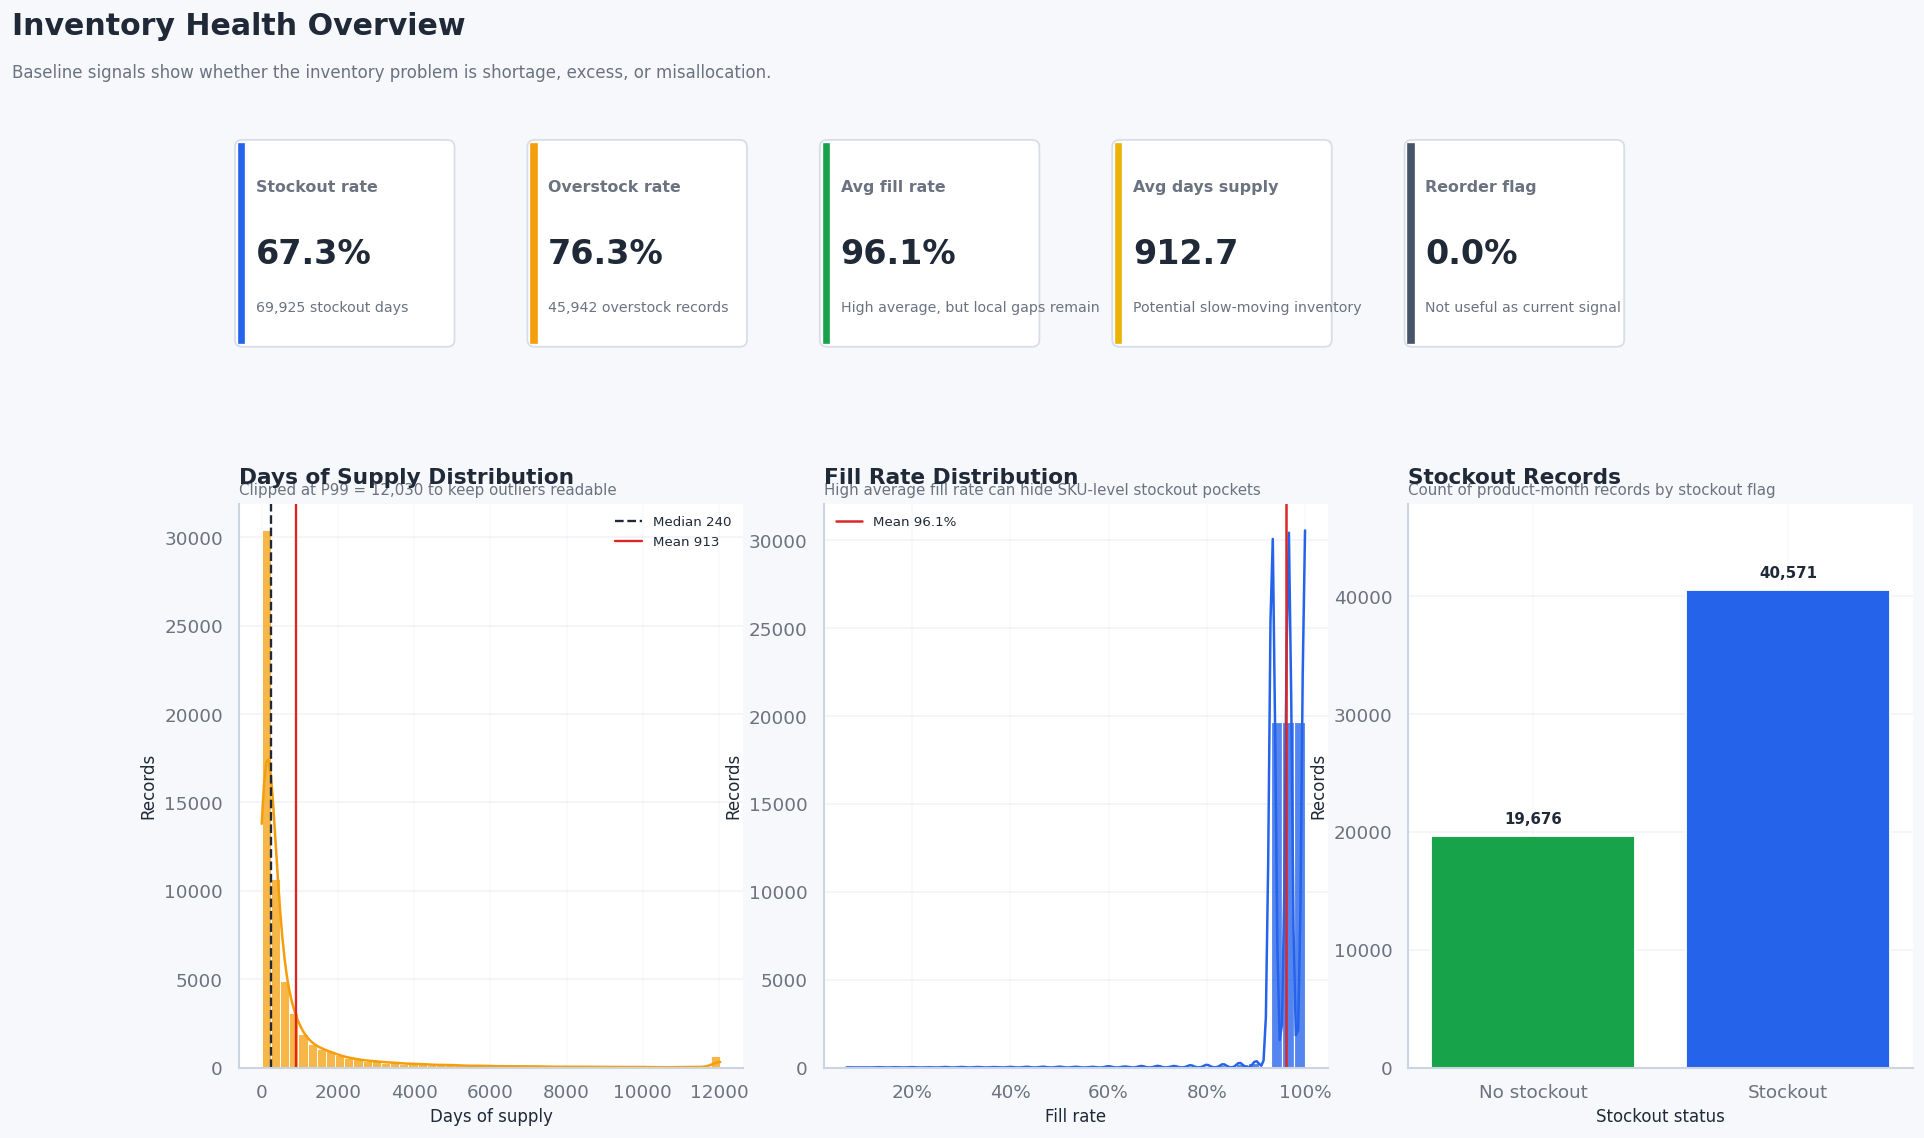

In [4]:
fig = plt.figure(figsize=(18, 10), facecolor=BACKGROUND)
gs = gridspec.GridSpec(2, 6, figure=fig, height_ratios=[0.85, 2.4], hspace=0.42, wspace=0.38)
fig.suptitle('Inventory Health Overview', fontsize=18, fontweight='bold', color=TEXT, x=0.02, ha='left', y=0.99)
fig.text(0.02, 0.935, 'Baseline signals show whether the inventory problem is shortage, excess, or misallocation.', fontsize=10, color=MUTED)

cards = [
    ('Stockout rate', fmt_percent(inv['stockout_flag'].mean()), f"{fmt_number(inv['stockout_days'].sum())} stockout days", PALETTE['stockout']),
    ('Overstock rate', fmt_percent(inv['overstock_flag'].mean()), f"{fmt_number(inv['overstock_flag'].sum())} overstock records", PALETTE['overstock']),
    ('Avg fill rate', fmt_percent(inv['fill_rate'].mean()), 'High average, but local gaps remain', PALETTE['stable']),
    ('Avg days supply', fmt_number(inv['days_of_supply'].mean(), 1), 'Potential slow-moving inventory', PALETTE['warning']),
    ('Reorder flag', fmt_percent(inv['reorder_flag'].mean()), 'Not useful as current signal', PALETTE['neutral'])
]
for idx, (title, value, subtitle, color) in enumerate(cards):
    ax_card = fig.add_subplot(gs[0, idx])
    kpi_card(ax_card, title, value, subtitle, color)

axes = [fig.add_subplot(gs[1, 0:2]), fig.add_subplot(gs[1, 2:4]), fig.add_subplot(gs[1, 4:6])]

p99_days = inv['days_of_supply'].quantile(0.99)
days_clipped = inv['days_of_supply'].clip(upper=p99_days)
sns.histplot(days_clipped, bins=50, kde=True, ax=axes[0], color=PALETTE['overstock'], alpha=0.75, edgecolor='white')
axes[0].axvline(inv['days_of_supply'].median(), color=PALETTE['ink'], linestyle='--', linewidth=1.4, label=f"Median {fmt_number(inv['days_of_supply'].median(), 0)}")
axes[0].axvline(inv['days_of_supply'].mean(), color=PALETTE['volatile'], linestyle='-', linewidth=1.4, label=f"Mean {fmt_number(inv['days_of_supply'].mean(), 0)}")
clean_axis(axes[0], 'Days of Supply Distribution', 'Days of supply', 'Records', subtitle=f'Clipped at P99 = {fmt_number(p99_days)} to keep outliers readable')
axes[0].legend(frameon=False, fontsize=8)

sns.histplot(inv['fill_rate'], bins=40, kde=True, ax=axes[1], color=PALETTE['stockout'], alpha=0.78, edgecolor='white')
axes[1].axvline(inv['fill_rate'].mean(), color=PALETTE['volatile'], linewidth=1.5, label=f"Mean {fmt_percent(inv['fill_rate'].mean())}")
clean_axis(axes[1], 'Fill Rate Distribution', 'Fill rate', 'Records', subtitle='High average fill rate can hide SKU-level stockout pockets')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend(frameon=False, fontsize=8)

stockout_counts = inv['stockout_flag'].value_counts().sort_index()
bar_colors = [PALETTE['stable'], PALETTE['stockout']]
axes[2].bar(['No stockout', 'Stockout'], stockout_counts.values, color=bar_colors, edgecolor='white', linewidth=1.1)
clean_axis(axes[2], 'Stockout Records', 'Stockout status', 'Records', subtitle='Count of product-month records by stockout flag')
label_vbars(axes[2], fmt=lambda v: fmt_number(v))

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [5]:
stockout_rate = inv['stockout_flag'].mean()
overstock_rate = inv['overstock_flag'].mean()
fill_rate_avg = inv['fill_rate'].mean()
days_supply_avg = inv['days_of_supply'].mean()
reorder_rate = inv['reorder_flag'].mean()
stockout_days_total = inv['stockout_days'].sum()

descriptive_key_takeaways = pd.DataFrame({
    'Metric': [
        'Stockout rate',
        'Overstock rate',
        'Average fill rate',
        'Average days of supply',
        'Reorder flag rate',
        'Total stockout days'
    ],
    'Value': [
        fmt_percent(stockout_rate),
        fmt_percent(overstock_rate),
        fmt_percent(fill_rate_avg),
        fmt_number(days_supply_avg, 1),
        fmt_percent(reorder_rate),
        fmt_number(stockout_days_total)
    ],
    'Interpretation': [
        'Availability gap appears repeatedly across product-month records',
        'Capital is also tied up in excess inventory',
        'High average fill rate can hide SKU-level stockout pockets',
        'Very high value suggests slow-moving or misallocated stock',
        'Current reorder flag is not useful as an operational signal',
        'Total duration of missed availability across the catalog'
    ]
})

display(descriptive_key_takeaways)


,Metric,Value,Interpretation
0,Stockout rate,67.3%,Availability gap appears repeatedly across product-month records
1,Overstock rate,76.3%,Capital is also tied up in excess inventory
2,Average fill rate,96.1%,High average fill rate can hide SKU-level stockout pockets
3,Average days of supply,912.7,Very high value suggests slow-moving or misallocated stock
4,Reorder flag rate,0.0%,Current reorder flag is not useful as an operational signal
5,Total stockout days,"69,925",Total duration of missed availability across the catalog


### **Nhận xét tổng quan tồn kho**

Biểu đồ và bảng KPI cho thấy một nghịch lý lớn: tỷ lệ thiếu hàng là **67.3%**, nhưng tỷ lệ dư hàng cũng lên tới **76.3%**. Nói đơn giản, doanh nghiệp vừa có nhiều thời điểm không đủ hàng để bán, vừa có rất nhiều hàng đang nằm trong kho.

Nếu công ty thật sự thiếu hàng trên toàn hệ thống, ta thường kỳ vọng tỷ lệ dư hàng thấp. Nhưng ở đây hai chỉ số cùng cao, nên cách hiểu hợp lý hơn là: **hàng có trong hệ thống, nhưng chưa được đặt đúng nơi cần bán**. Một số mã/tháng thiếu hàng, trong khi mã/tháng khác lại dư hàng.

Tỷ lệ đáp ứng đơn hàng trung bình vẫn cao (**96.1%**) cũng củng cố nhận định này. Hệ thống không phải lúc nào cũng vận hành kém, nhưng có nhiều điểm đứt gãy cục bộ theo mã sản phẩm hoặc thời điểm.

**Việc nên làm:** không nên nhập thêm hàng cho toàn bộ danh mục. Cần theo dõi tồn kho ở cấp mã sản phẩm theo từng tháng để biết chỗ nào thiếu thật, chỗ nào dư thật.

**Kết luận:** Vấn đề lớn nhất không phải “thiếu hàng”, mà là **phân bổ hàng chưa đúng mã sản phẩm và chưa đúng thời điểm**.

**Executive takeaway:** Tồn kho không thiếu về tổng thể. Vấn đề là hàng đang nằm sai SKU hoặc sai thời điểm: có nơi thiếu hàng gây mất doanh thu, trong khi nơi khác lại dư hàng làm vốn bị khóa.

### **3.1 [Descriptive] Giải thích các chỉ số tưởng như mâu thuẫn**

Phần này giải thích một điểm rất dễ gây hiểu nhầm: vì sao tỷ lệ thiếu hàng cao nhưng tỷ lệ đáp ứng đơn hàng vẫn cao.

Điểm cần nhớ là các chỉ số này không đo cùng một thứ. `stockout_flag` chỉ cần một tháng có ít nhất một dấu hiệu thiếu hàng là đã được đánh dấu. Trong khi đó, `fill_rate` phản ánh mức đáp ứng trung bình trong kỳ. Vì vậy, nếu một sản phẩm chỉ thiếu hàng 1-2 ngày trong tháng, tháng đó vẫn bị tính là có stockout, nhưng fill rate vẫn có thể rất cao.

Phần này cũng kiểm tra `days_of_supply`, vì con số trung bình hơn 900 ngày là bất thường và cần được xem như tín hiệu hàng bán chậm hoặc outlier, không thể chỉ nhắc qua rồi bỏ.


In [6]:
metric_explanation = pd.DataFrame({
    'Chỉ số': ['stockout_flag', 'fill_rate', 'overstock_flag', 'days_of_supply'],
    'Đo điều gì?': [
        'Tháng đó có phát sinh thiếu hàng hay không',
        'Mức đáp ứng đơn hàng trung bình trong kỳ',
        'Tháng đó có dư hàng so với nhu cầu hay không',
        'Nếu bán theo tốc độ hiện tại, tồn kho đủ dùng trong bao nhiêu ngày'
    ],
    'Cách hiểu cho business': [
        'Chỉ cần thiếu hàng một phần trong tháng là được tính là 1',
        'Vẫn có thể cao nếu chỉ thiếu hàng vài ngày trong tháng',
        'Cho biết vốn có thể đang nằm ở sản phẩm bán chậm',
        'Con số rất cao là dấu hiệu hàng nằm kho quá lâu hoặc tốc độ bán quá thấp'
    ]
})

days_supply_quantiles = inv['days_of_supply'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).rename('days_of_supply').reset_index()
days_supply_quantiles['index'] = days_supply_quantiles['index'].map(lambda x: f'P{int(x*100)}')
stockout_days_distribution = inv['stockout_days'].value_counts().sort_index().rename_axis('stockout_days').reset_index(name='records')
stockout_days_distribution['record_share'] = stockout_days_distribution['records'] / len(inv)

fill_rate_mechanism = pd.DataFrame({
    'Kiểm tra': [
        'Average stock_on_hand',
        'Median stock_on_hand',
        'P90 stock_on_hand',
        'Average days_of_supply',
        'Median days_of_supply',
        'P99 days_of_supply',
        'Correlation fill_rate vs 1 - stockout_days/30'
    ],
    'Giá trị': [
        fmt_number(inv['stock_on_hand'].mean(), 1),
        fmt_number(inv['stock_on_hand'].median(), 1),
        fmt_number(inv['stock_on_hand'].quantile(0.9), 1),
        fmt_number(inv['days_of_supply'].mean(), 1),
        fmt_number(inv['days_of_supply'].median(), 1),
        fmt_number(inv['days_of_supply'].quantile(0.99), 1),
        fmt_number(inv['fill_rate'].corr(1 - inv['stockout_days'] / 30), 3)
    ]
})

display(metric_explanation)
display(fill_rate_mechanism)
display(days_supply_quantiles)
display(stockout_days_distribution.head(12))


,Chỉ số,Đo điều gì?,Cách hiểu cho business
0,stockout_flag,Tháng đó có phát sinh thiếu hàng hay không,Chỉ cần thiếu hàng một phần trong tháng là được tính là 1
1,fill_rate,Mức đáp ứng đơn hàng trung bình trong kỳ,Vẫn có thể cao nếu chỉ thiếu hàng vài ngày trong tháng
2,overstock_flag,Tháng đó có dư hàng so với nhu cầu hay không,Cho biết vốn có thể đang nằm ở sản phẩm bán chậm
3,days_of_supply,"Nếu bán theo tốc độ hiện tại, tồn kho đủ dùng trong bao nhiêu ngày",Con số rất cao là dấu hiệu hàng nằm kho quá lâu hoặc tốc độ bán quá thấp


,Kiểm tra,Giá trị
0,Average stock_on_hand,189.3
1,Median stock_on_hand,62.0
2,P90 stock_on_hand,532.0
3,Average days_of_supply,912.7
4,Median days_of_supply,240.0
5,P99 days_of_supply,"12,030.0"
6,Correlation fill_rate vs 1 - stockout_days/30,1.000


,index,days_of_supply
0,P50,240.0000
1,P75,683.1000
2,P90,"1,926.1200"
3,P95,"3,660.0000"
4,P99,"12,030.0000"


,stockout_days,records,record_share
0,0,19676,0.3266
1,1,19654,0.3262
2,2,19658,0.3263
3,3,237,0.0039
4,4,174,0.0029
5,5,124,0.0021
6,6,100,0.0017
7,7,85,0.0014
8,8,56,0.0009
9,9,61,0.0010


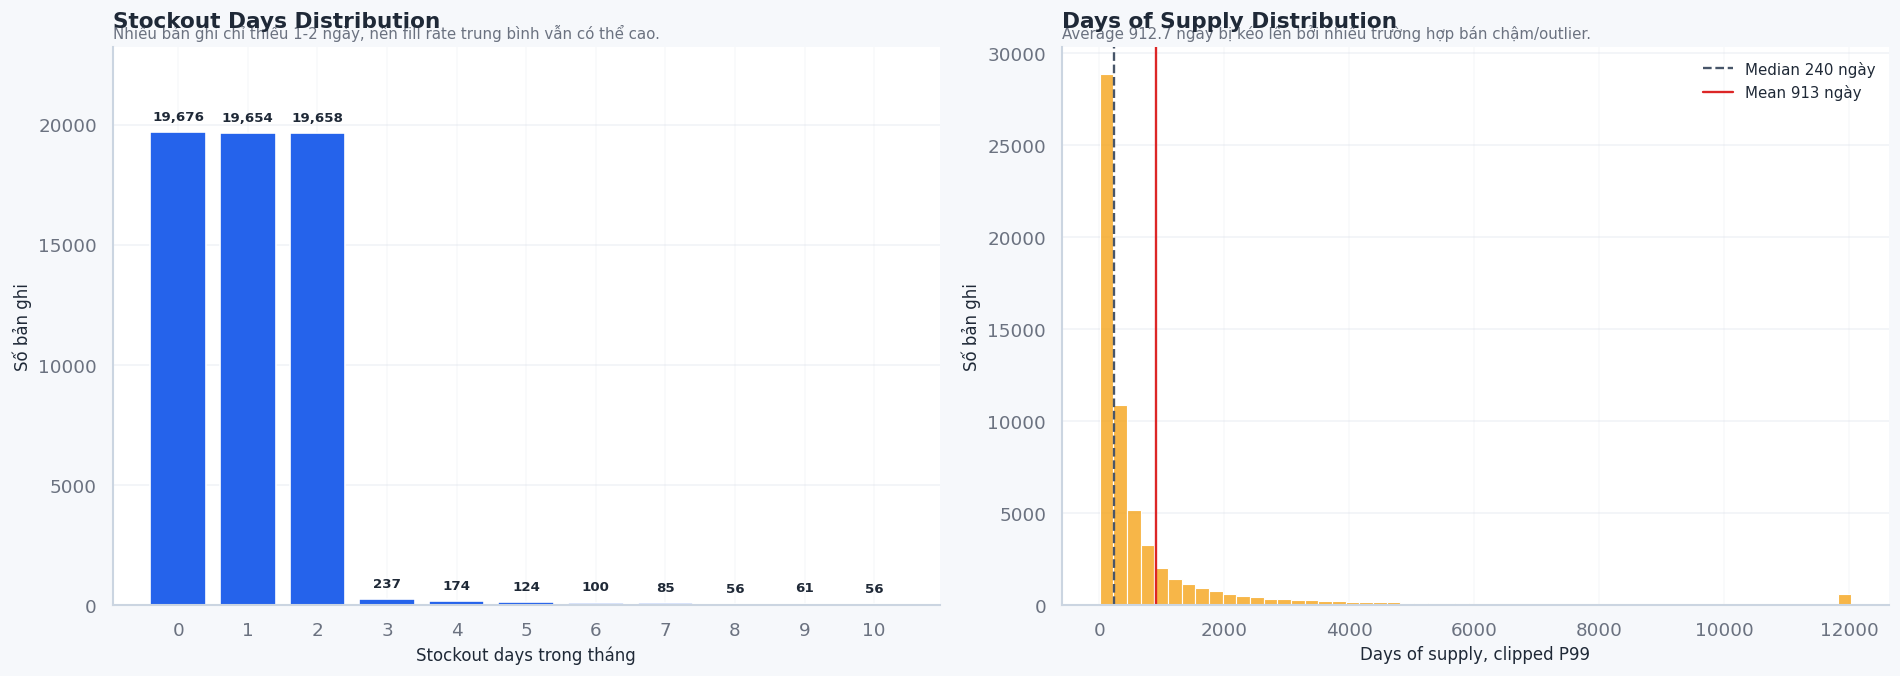

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), facecolor=BACKGROUND)

stockout_plot = stockout_days_distribution[stockout_days_distribution['stockout_days'] <= 10].copy()
axes[0].bar(stockout_plot['stockout_days'].astype(str), stockout_plot['records'], color=PALETTE['stockout'], edgecolor='white')
clean_axis(
    axes[0],
    'Stockout Days Distribution',
    'Stockout days trong tháng',
    'Số bản ghi',
    subtitle='Nhiều bản ghi chỉ thiếu 1-2 ngày, nên fill rate trung bình vẫn có thể cao.'
)
label_vbars(axes[0], fmt=lambda v: fmt_number(v), fontsize=8)

p99_days = inv['days_of_supply'].quantile(0.99)
sns.histplot(inv['days_of_supply'].clip(upper=p99_days), bins=55, ax=axes[1], color=PALETTE['overstock'], edgecolor='white')
axes[1].axvline(inv['days_of_supply'].median(), color=PALETTE['neutral'], linestyle='--', linewidth=1.4, label=f"Median {fmt_number(inv['days_of_supply'].median(), 0)} ngày")
axes[1].axvline(inv['days_of_supply'].mean(), color=PALETTE['volatile'], linewidth=1.4, label=f"Mean {fmt_number(inv['days_of_supply'].mean(), 0)} ngày")
clean_axis(
    axes[1],
    'Days of Supply Distribution',
    'Days of supply, clipped P99',
    'Số bản ghi',
    subtitle='Average 912.7 ngày bị kéo lên bởi nhiều trường hợp bán chậm/outlier.'
)
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


#### **Descriptive Insight: Vì sao stockout cao nhưng fill rate vẫn cao?**

Biểu đồ bên trái giải thích “nghịch lý” quan trọng nhất của notebook: stockout rate cao không có nghĩa là sản phẩm hết hàng cả tháng. Phần lớn bản ghi chỉ rơi vào **0, 1 hoặc 2 ngày stockout trong tháng**; cụ thể nhóm 0, 1 và 2 ngày đều quanh **19.6K bản ghi**. Vì vậy, nếu một SKU chỉ thiếu hàng 1-2 ngày trong tháng, fill rate vẫn có thể rất cao, khoảng 93%-97%.

Điều này cho thấy vấn đề chính không phải là “cửa hàng luôn hết hàng”, mà là **availability bị đứt đoạn ngắn nhưng lặp lại trên nhiều SKU/tháng**. Với khách hàng, chỉ cần đúng ngày họ muốn mua mà sản phẩm không có sẵn thì doanh thu vẫn mất, dù nhìn trung bình cả tháng fill rate vẫn đẹp.

Biểu đồ bên phải cho thấy vấn đề ngược lại: `days_of_supply` bị lệch rất mạnh. Median chỉ khoảng **240 ngày**, nhưng mean lên tới **913 ngày**, nghĩa là một nhóm SKU có tồn kho cực kỳ lâu, kéo trung bình lên bất thường. Đây là dấu hiệu của slow-moving inventory, SKU bán chậm, hoặc tồn kho đang nằm sai sản phẩm/sai thời điểm.

Business implication là doanh nghiệp đang gặp hai vấn đề cùng lúc: một số SKU thiếu hàng ngắn hạn làm mất doanh thu, trong khi một số SKU khác lại giữ tồn kho quá lâu làm khóa vốn. Vì vậy, giải pháp không thể là tăng tồn kho toàn bộ danh mục.

**Khuyến nghị hành động:** với SKU thiếu 1-2 ngày nhưng lost revenue cao, cần chỉnh lịch nhập hàng và reorder timing để tránh đứt hàng ngắn hạn. Với SKU có days of supply quá cao, cần kiểm tra slow-moving stock, dừng replenishment, markdown hoặc bundle để giải phóng vốn.

**Kết luận:** Tồn kho hiện tại không thiếu về tổng lượng, mà đang sai nhịp và sai SKU: chỗ cần hàng thì bị đứt đoạn, chỗ không cần thì vốn bị giữ quá lâu.


## **4. [Diagnostic] Phân tích theo category / segment / sản phẩm**

Sau khi biết doanh nghiệp vừa thiếu vừa dư hàng, câu hỏi tiếp theo là: vấn đề nằm ở đâu?

Phần này chia dữ liệu theo nhóm sản phẩm như category và segment. Cách làm này giúp stakeholder không bị chìm trong hàng nghìn mã sản phẩm, mà nhìn được nhóm nào đang đáng chú ý nhất.

Cách đọc phần này rất đơn giản:

- Nhóm có tỷ lệ thiếu hàng cao: có thể đang không được bổ sung hàng kịp.
- Nhóm có số ngày tồn kho cao: có thể đang bán chậm hoặc nhập quá nhiều.
- Nhóm vừa thiếu vừa dư: cần kiểm tra sâu vì có thể đang sai cơ cấu hàng, tức là dư ở mã này nhưng thiếu ở mã khác.

Mục tiêu của phần này là khoanh vùng “khu vực cháy lớn nhất” trước khi đi xuống cấp mã sản phẩm.

In [8]:
category_stockout = (
    inv.groupby('category')
    .agg(
        records=('product_id', 'size'),
        stockout_rate=('stockout_flag', 'mean'),
        overstock_rate=('overstock_flag', 'mean'),
        avg_fill_rate=('fill_rate', 'mean'),
        avg_days_of_supply=('days_of_supply', 'mean'),
        total_stockout_days=('stockout_days', 'sum'),
        total_units_sold=('units_sold', 'sum')
    )
    .reset_index()
    .sort_values('stockout_rate', ascending=False)
)

segment_stockout = (
    inv.groupby('segment')
    .agg(
        records=('product_id', 'size'),
        stockout_rate=('stockout_flag', 'mean'),
        overstock_rate=('overstock_flag', 'mean'),
        avg_fill_rate=('fill_rate', 'mean'),
        avg_days_of_supply=('days_of_supply', 'mean'),
        total_stockout_days=('stockout_days', 'sum'),
        total_units_sold=('units_sold', 'sum')
    )
    .reset_index()
    .sort_values('stockout_rate', ascending=False)
)

display(category_stockout)
display(segment_stockout.head(15))


,category,records,stockout_rate,overstock_rate,avg_fill_rate,avg_days_of_supply,total_stockout_days,total_units_sold
1,GenZ,4674,0.6829,0.7163,0.9617,718.8122,5368,48695
2,Outdoor,21050,0.6735,0.7985,0.9627,"1,068.8378",23552,337510
3,Streetwear,31020,0.6732,0.7493,0.9602,887.1367,36993,511467
0,Casual,3503,0.6620,0.7259,0.9618,459.1326,4012,31202


,segment,records,stockout_rate,overstock_rate,avg_fill_rate,avg_days_of_supply,total_stockout_days,total_units_sold
7,Trendy,4674,0.6829,0.7163,0.9617,718.8122,5368,48695
2,Balanced,6622,0.6789,0.7240,0.9581,837.8431,8327,135119
5,Premium,3182,0.6788,0.7894,0.9616,822.4648,3669,40874
4,Performance,7673,0.6727,0.7468,0.9612,745.6083,8927,125619
0,Activewear,18290,0.6726,0.7930,0.9627,"1,091.6399",20484,298460
3,Everyday,13598,0.6724,0.7805,0.9598,"1,113.7547",16419,236495
6,Standard,3127,0.6658,0.6732,0.9646,353.3401,3320,14234
1,All-weather,3081,0.6605,0.7582,0.9631,494.7097,3411,29378


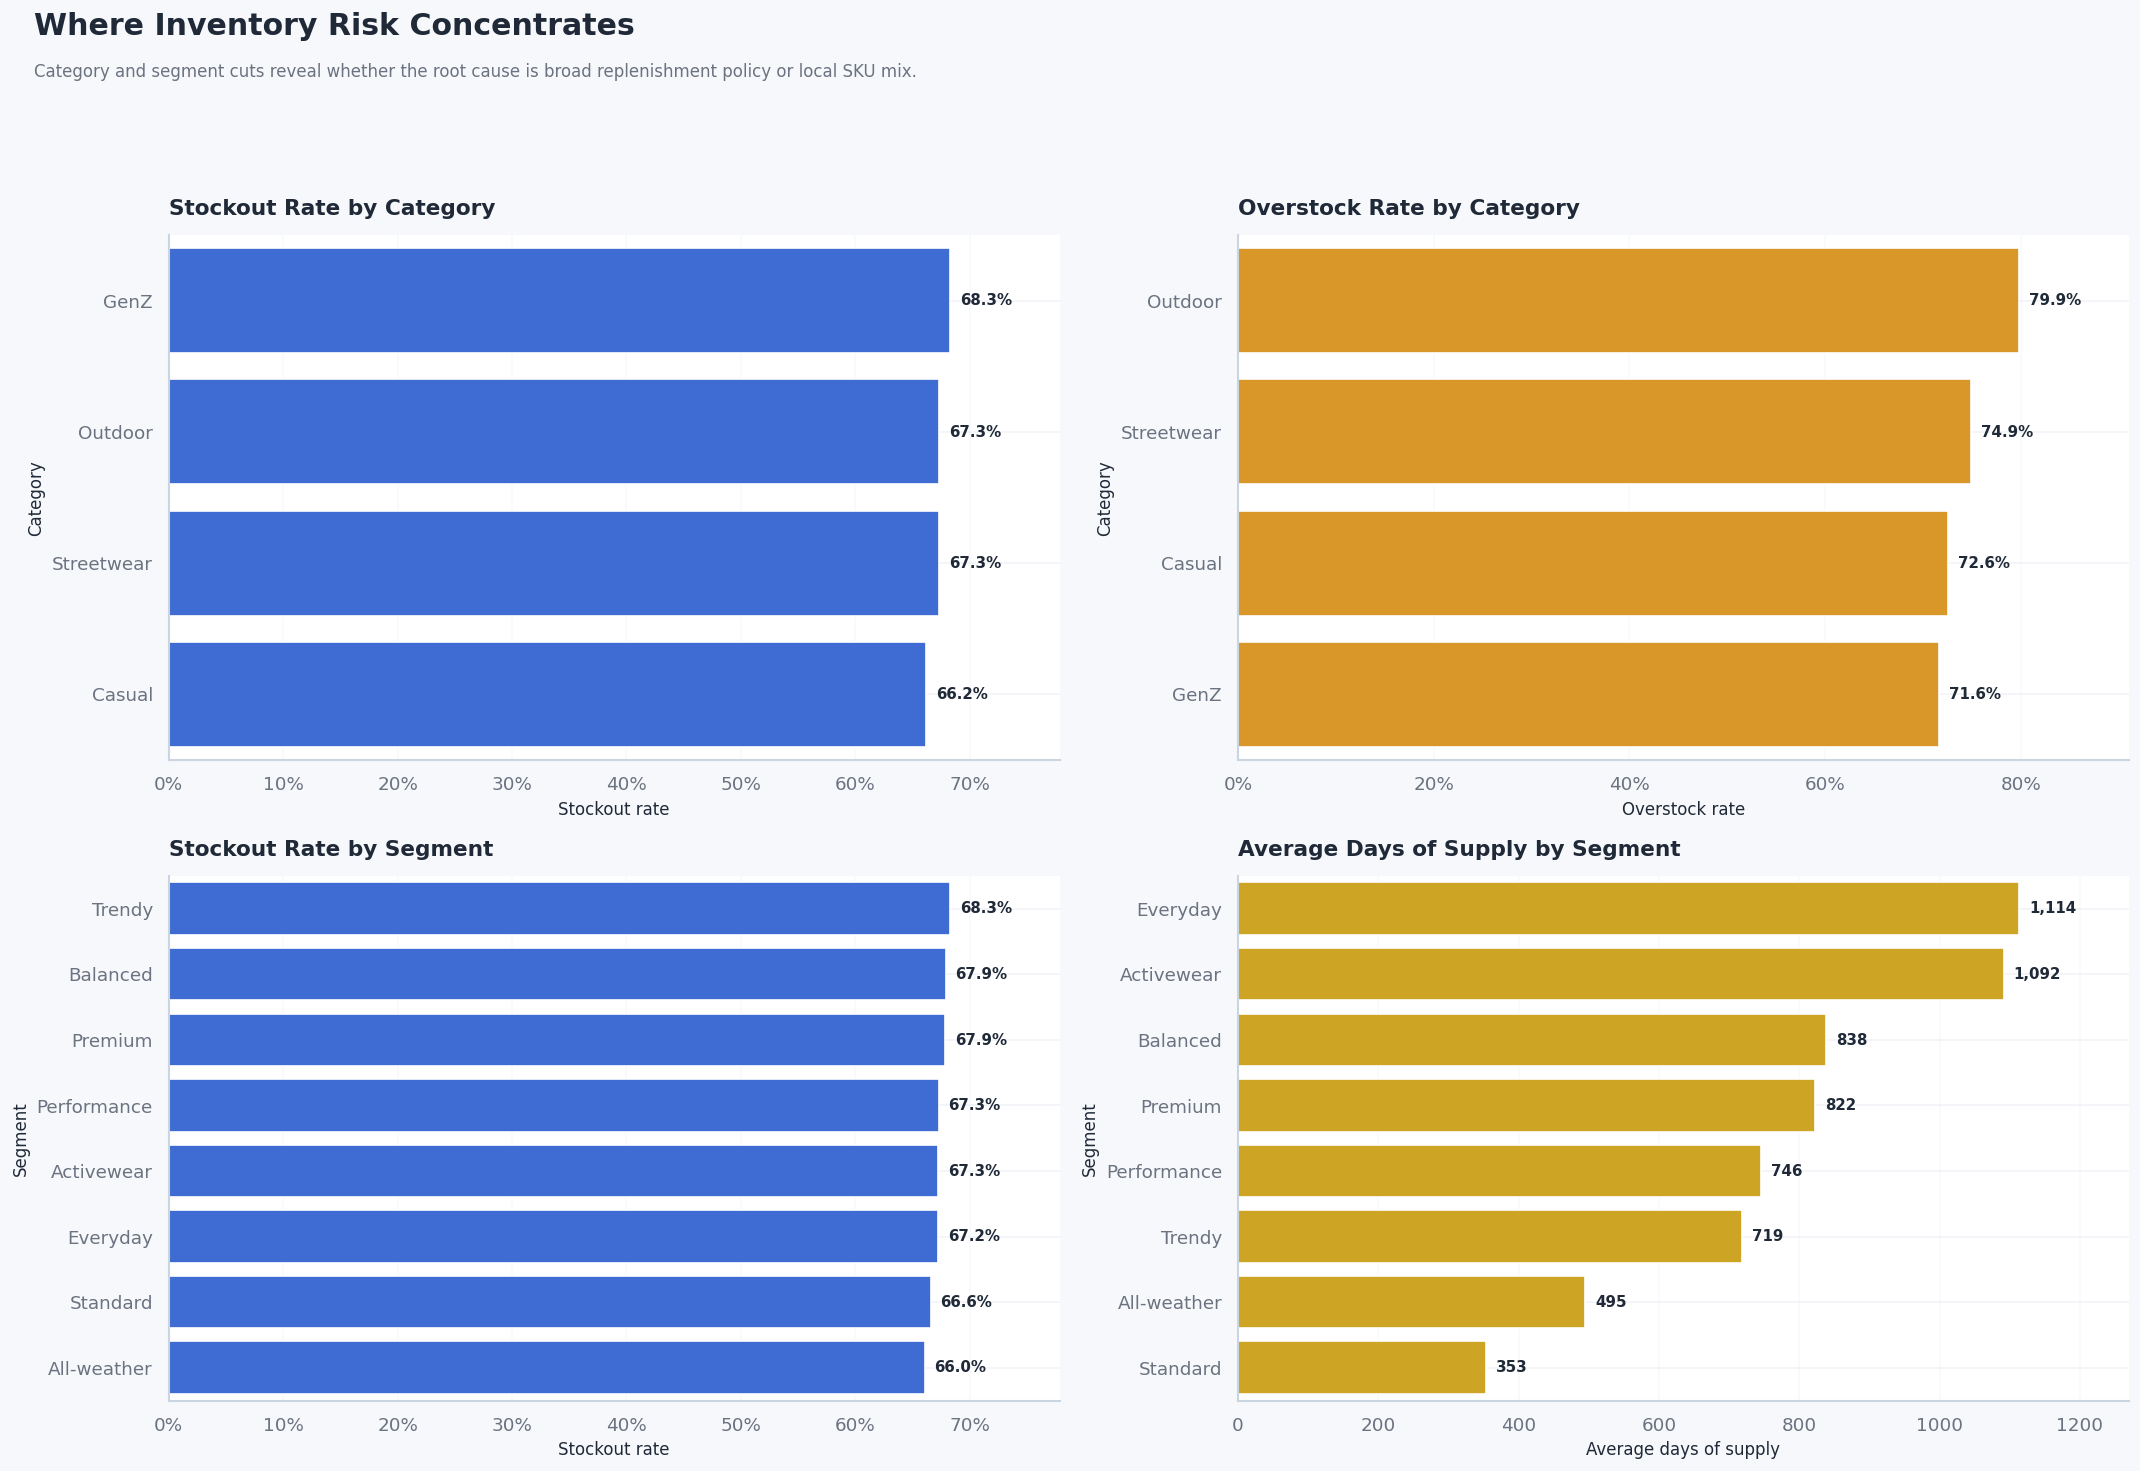

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=BACKGROUND)
fig.suptitle('Where Inventory Risk Concentrates', fontsize=18, fontweight='bold', color=TEXT, x=0.02, ha='left', y=1.02)
fig.text(0.02, 0.975, 'Category and segment cuts reveal whether the root cause is broad replenishment policy or local SKU mix.', fontsize=10, color=MUTED)

sns.barplot(data=category_stockout, x='stockout_rate', y='category', ax=axes[0, 0], color=PALETTE['stockout'], edgecolor='white')
clean_axis(axes[0, 0], 'Stockout Rate by Category', 'Stockout rate', 'Category')
axes[0, 0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
label_hbars(axes[0, 0], fmt=lambda v: fmt_percent(v))

category_overstock = category_stockout.sort_values('overstock_rate', ascending=False)
sns.barplot(data=category_overstock, x='overstock_rate', y='category', ax=axes[0, 1], color=PALETTE['overstock'], edgecolor='white')
clean_axis(axes[0, 1], 'Overstock Rate by Category', 'Overstock rate', 'Category')
axes[0, 1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
label_hbars(axes[0, 1], fmt=lambda v: fmt_percent(v))

segment_plot = segment_stockout.head(12)
sns.barplot(data=segment_plot, x='stockout_rate', y='segment', ax=axes[1, 0], color=PALETTE['stockout'], edgecolor='white')
clean_axis(axes[1, 0], 'Stockout Rate by Segment', 'Stockout rate', 'Segment')
axes[1, 0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
label_hbars(axes[1, 0], fmt=lambda v: fmt_percent(v))

segment_days = segment_stockout.sort_values('avg_days_of_supply', ascending=False).head(12)
sns.barplot(data=segment_days, x='avg_days_of_supply', y='segment', ax=axes[1, 1], color=PALETTE['warning'], edgecolor='white')
clean_axis(axes[1, 1], 'Average Days of Supply by Segment', 'Average days of supply', 'Segment')
label_hbars(axes[1, 1], fmt=lambda v: fmt_number(v, 0))

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


In [10]:
top_stockout_cat = category_stockout.iloc[0]
top_overstock_cat = category_stockout.sort_values('overstock_rate', ascending=False).iloc[0]
top_days_segment = segment_stockout.sort_values('avg_days_of_supply', ascending=False).iloc[0]
spread_stockout = category_stockout['stockout_rate'].max() - category_stockout['stockout_rate'].min()

misallocation_candidates = category_stockout[
    (category_stockout['stockout_rate'] >= category_stockout['stockout_rate'].median()) &
    (category_stockout['overstock_rate'] >= category_stockout['overstock_rate'].median())
]
misallocation_text = ', '.join(misallocation_candidates['category'].head(5).tolist())

diagnostic_category_takeaways = pd.DataFrame({
    'Signal': [
        'Highest stockout category',
        'Highest overstock category',
        'Highest days-of-supply segment',
        'Stockout spread across categories',
        'Potential misallocation category'
    ],
    'Finding': [
        f"{top_stockout_cat['category']} ({fmt_percent(top_stockout_cat['stockout_rate'])})",
        f"{top_overstock_cat['category']} ({fmt_percent(top_overstock_cat['overstock_rate'])})",
        f"{top_days_segment['segment']} ({fmt_number(top_days_segment['avg_days_of_supply'], 1)} days)",
        fmt_percent(spread_stockout),
        misallocation_text if misallocation_text else 'No category above both medians'
    ],
    'Why it matters': [
        'First category to audit for replenishment or allocation gaps',
        'First category to audit for locked capital and slow movement',
        'Segment likely carrying excess inventory duration',
        'Small spread means the issue is broad, not isolated',
        'High stockout and high overstock together suggest wrong SKU/timing mix'
    ]
})

display(diagnostic_category_takeaways)


,Signal,Finding,Why it matters
0,Highest stockout category,GenZ (68.3%),First category to audit for replenishment or allocation gaps
1,Highest overstock category,Outdoor (79.9%),First category to audit for locked capital and slow movement
2,Highest days-of-supply segment,"Everyday (1,113.8 days)",Segment likely carrying excess inventory duration
3,Stockout spread across categories,2.1%,"Small spread means the issue is broad, not isolated"
4,Potential misallocation category,Outdoor,High stockout and high overstock together suggest wrong SKU/timing mix


### **Nhận xét theo category và segment**

Nhìn theo category, **GenZ** có tỷ lệ thiếu hàng cao nhất (**68.3%**), nhưng category thấp nhất cũng đã ở mức **66.2%**. Khoảng cách giữa nhóm cao nhất và thấp nhất chỉ khoảng **2.1 điểm phần trăm**, nghĩa là thiếu hàng không phải vấn đề của riêng một category. Nó xuất hiện khá rộng trên toàn danh mục.

Tuy nhiên, **Outdoor** là nhóm đáng chú ý vì vừa có tỷ lệ dư hàng cao nhất (**79.9%**), vừa nằm trong vùng thiếu hàng cao. Với stakeholder, đây là tín hiệu quan trọng: nhóm này không đơn giản là bán chậm hay thiếu hàng, mà có thể đang sai cơ cấu hàng.

Ở cấp segment, **Everyday** và **Activewear** có số ngày tồn kho trung bình rất cao. Điều này gợi ý rằng một phần hàng đang nằm quá lâu trong kho, làm vốn bị kẹt.

**Việc nên làm:** kiểm tra Outdoor và các segment có ngày tồn kho cao ở cấp mã sản phẩm. Cần phân biệt mã nào cần bổ sung hàng và mã nào cần giảm nhập/xả hàng.

**Kết luận:** Thiếu hàng là vấn đề rộng, nhưng **Outdoor và các segment tồn kho lâu là nơi cần chẩn đoán sâu trước**.

**Executive takeaway:** Stockout xuất hiện rộng trên toàn danh mục, nhưng rủi ro vận hành không đồng đều. Outdoor có overstock cao nhất (**79.9%**), Everyday và Activewear có days of supply rất cao, cho thấy một phần vốn đang nằm ở nhóm quay vòng chậm. Đây là dấu hiệu cần đi sâu xuống cấp SKU thay vì chỉ quản lý ở cấp category.

## **5. [Diagnostic] Ước tính doanh thu bị mất do thiếu hàng**

Tỷ lệ thiếu hàng chỉ cho biết vấn đề có xảy ra, nhưng chưa cho biết vấn đề đó lớn đến mức nào. Ban lãnh đạo thường cần câu trả lời bằng tiền: thiếu hàng làm mất bao nhiêu doanh thu và lợi nhuận?

Vì dữ liệu không có “nhu cầu thật” của khách hàng, notebook dùng một cách ước tính đơn giản: lấy doanh số trung bình 3 tháng trước làm mức nhu cầu kỳ vọng. Nếu tháng hiện tại bị thiếu hàng và bán thấp hơn mức kỳ vọng, phần chênh lệch được xem là số lượng có thể đã bán thêm nếu có đủ hàng.

Cách này không hoàn hảo, nhưng dễ hiểu và đủ tốt cho mục tiêu EDA: xác định quy mô thiệt hại và nhóm sản phẩm cần ưu tiên.

In [11]:
inv_lost = inv.sort_values(['product_id', 'snapshot_date']).copy()

inv_lost['demand_est_3m'] = (
    inv_lost
    .groupby('product_id')['units_sold']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

inv_lost['lost_units_est'] = np.where(
    inv_lost['stockout_flag'] == 1,
    np.maximum(0, inv_lost['demand_est_3m'] - inv_lost['units_sold']),
    0
)

inv_lost['lost_revenue_est'] = inv_lost['lost_units_est'] * inv_lost['price']
inv_lost['lost_margin_est'] = inv_lost['lost_units_est'] * inv_lost['gross_margin_per_unit']

lost_summary = pd.DataFrame({
    'Chỉ số': [
        'Tổng lost units ước tính',
        'Tổng lost revenue ước tính',
        'Tổng lost gross margin ước tính',
        'Số bản ghi có lost revenue > 0'
    ],
    'Giá trị': [
        inv_lost['lost_units_est'].sum(),
        inv_lost['lost_revenue_est'].sum(),
        inv_lost['lost_margin_est'].sum(),
        (inv_lost['lost_revenue_est'] > 0).sum()
    ]
})

display(lost_summary)

lost_by_category = (
    inv_lost.groupby('category')
    .agg(
        lost_units=('lost_units_est', 'sum'),
        lost_revenue=('lost_revenue_est', 'sum'),
        lost_margin=('lost_margin_est', 'sum'),
        stockout_days=('stockout_days', 'sum'),
        units_sold=('units_sold', 'sum')
    )
    .reset_index()
    .sort_values('lost_revenue', ascending=False)
)

top_lost_products = (
    inv_lost.groupby(['product_id', 'product_name', 'category', 'segment'])
    .agg(
        lost_units=('lost_units_est', 'sum'),
        lost_revenue=('lost_revenue_est', 'sum'),
        lost_margin=('lost_margin_est', 'sum'),
        stockout_days=('stockout_days', 'sum'),
        units_sold=('units_sold', 'sum')
    )
    .reset_index()
    .sort_values('lost_revenue', ascending=False)
)

display(lost_by_category)
display(top_lost_products.head(20))
lost_by_category.to_csv(OUTPUT_DIR / 'lost_by_category.csv', index=False)


,Chỉ số,Giá trị
0,Tổng lost units ước tính,"151,803.3333"
1,Tổng lost revenue ước tính,"799,873,483.2385"
2,Tổng lost gross margin ước tính,"161,878,448.6692"
3,Số bản ghi có lost revenue > 0,"21,088.0000"


,category,lost_units,lost_revenue,lost_margin,stockout_days,units_sold
3,Streetwear,"83,967.3333","642,350,431.0850","128,502,771.0139",36993,511467
2,Outdoor,"53,044.6667","114,309,205.5836","25,047,061.7617",23552,337510
0,Casual,"4,965.5000","21,843,241.5394","3,421,062.0418",4012,31202
1,GenZ,"9,825.8333","21,370,605.0306","4,907,553.8517",5368,48695


,product_id,product_name,category,segment,lost_units,lost_revenue,lost_margin,stockout_days,units_sold
315,487,SaigonFlex UM-92,Streetwear,Balanced,"1,463.3333","19,052,306.0484","2,915,002.8254",82,9623
279,438,SaigonFlex UM-43,Streetwear,Balanced,"1,058.3333","12,402,112.1775","5,331,668.0251",174,9124
574,826,HanoiStreet UM-10,Streetwear,Balanced,972.6667,"12,382,441.0134","619,122.0507",110,8315
418,604,SaigonFlex UC-69,Streetwear,Everyday,"1,741.0000","10,681,555.2641","3,470,437.3053",132,10506
319,491,SaigonFlex UM-96,Streetwear,Balanced,954.3333,"10,555,003.5331","527,750.1767",155,7048
1570,2332,VietMotion UE-06,Streetwear,Performance,"1,658.3333","9,617,718.0092","2,064,924.0566",121,9386
1403,2045,UrbanVN UE-05,Streetwear,Performance,"1,675.6667","9,332,562.3487","4,311,643.8051",116,10376
305,475,SaigonFlex UM-80,Streetwear,Balanced,690.0000,"8,698,297.6790","1,770,103.5777",52,6434
610,927,HanoiStreet UE-36,Streetwear,Performance,"1,468.0000","8,603,014.6047","430,150.7302",120,9002
1410,2054,UrbanVN UE-14,Streetwear,Performance,"1,144.5000","8,093,447.9997","404,672.4000",143,7069


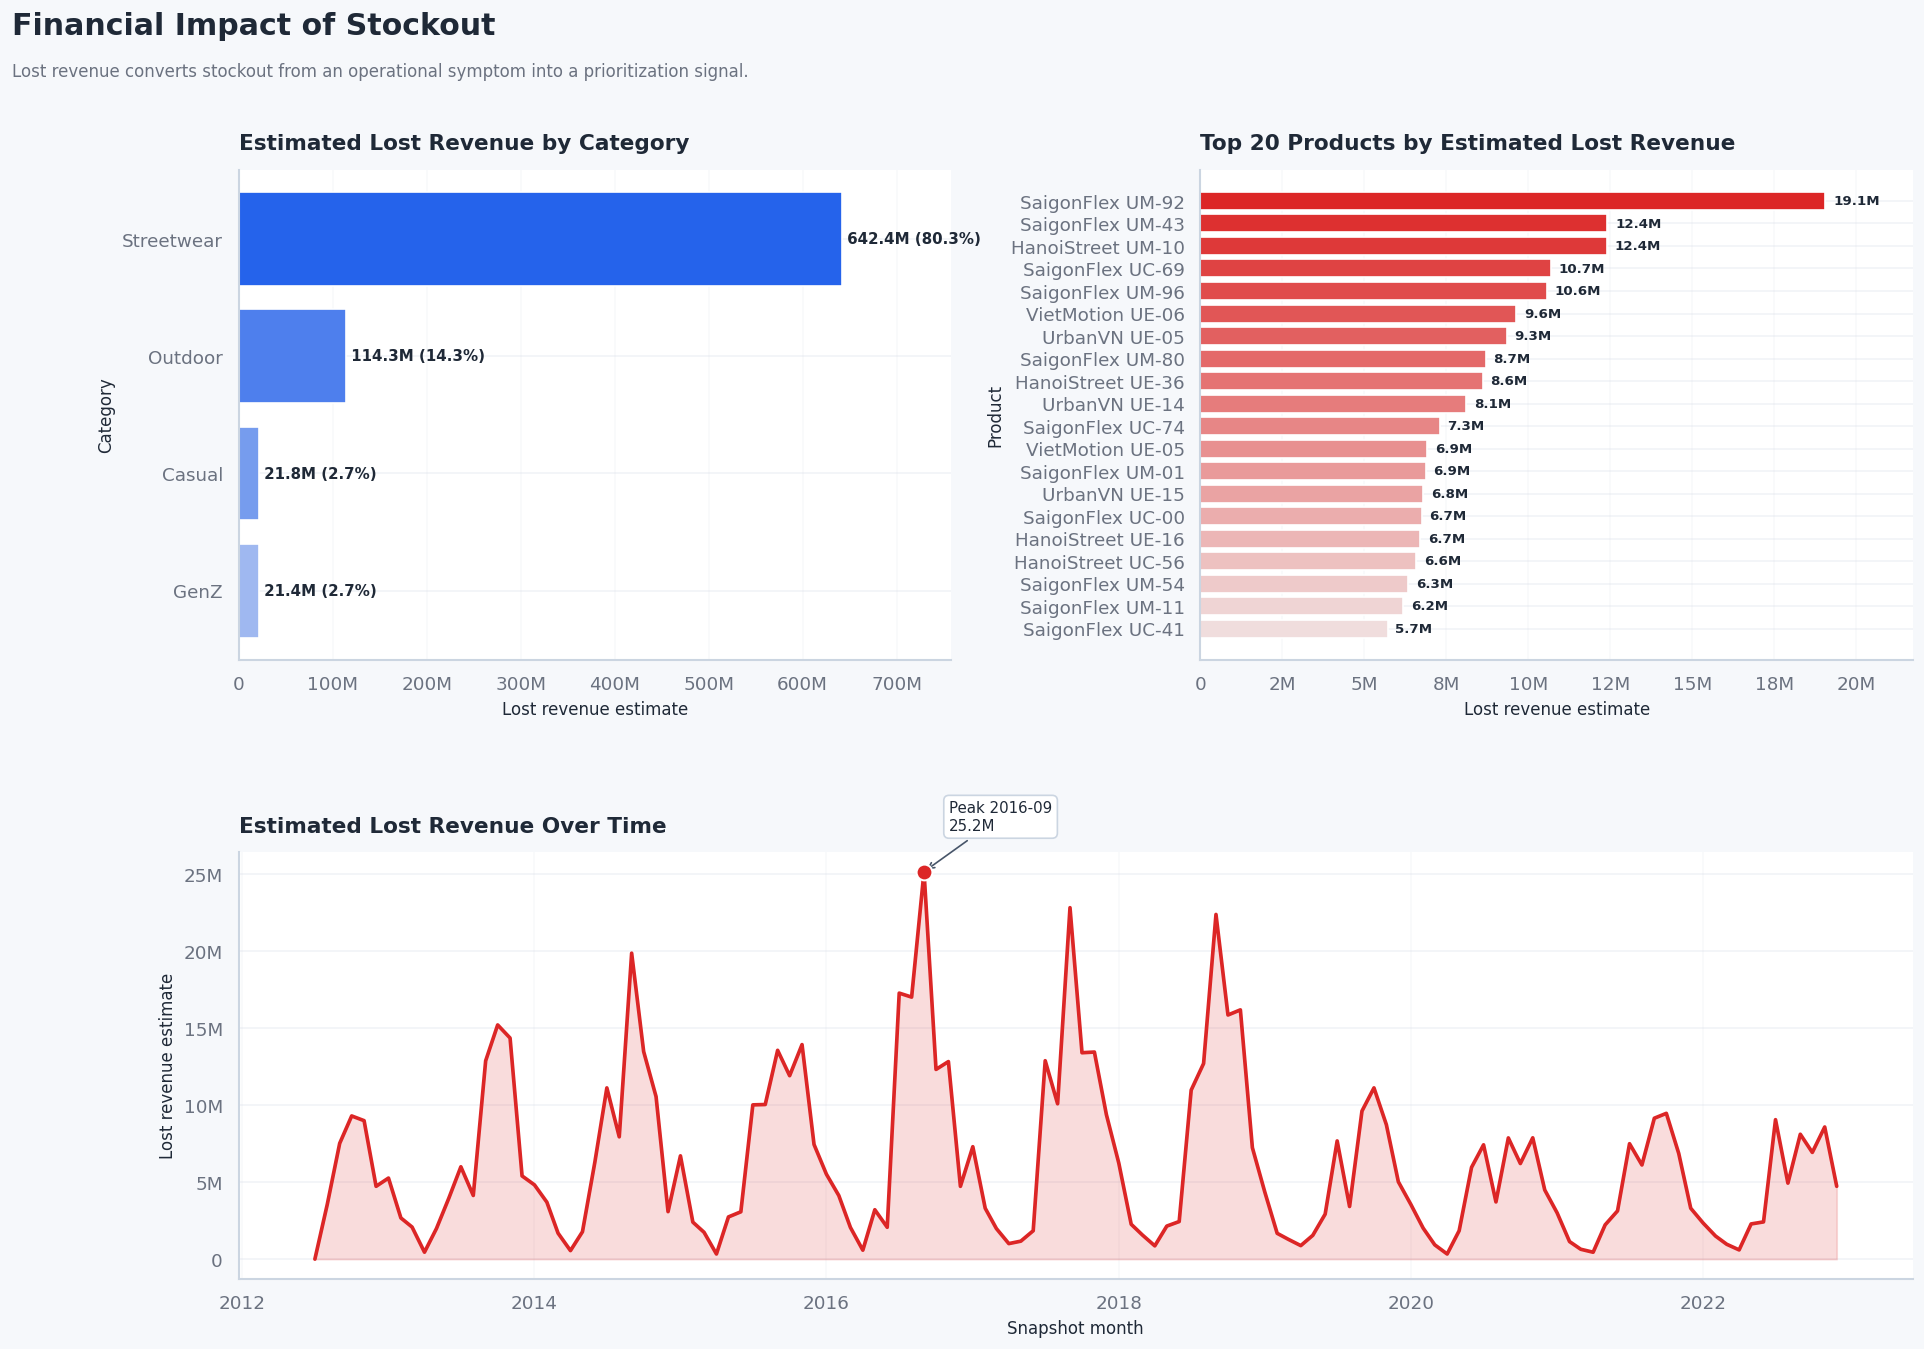

In [12]:
fig = plt.figure(figsize=(18, 12), facecolor=BACKGROUND)
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1.15, 1.0], hspace=0.42, wspace=0.35)
fig.suptitle('Financial Impact of Stockout', fontsize=18, fontweight='bold', color=TEXT, x=0.02, ha='left', y=0.99)
fig.text(0.02, 0.945, 'Lost revenue converts stockout from an operational symptom into a prioritization signal.', fontsize=10, color=MUTED)

ax_cat = fig.add_subplot(gs[0, 0])
lost_cat_plot = lost_by_category.sort_values('lost_revenue', ascending=True).copy()
lost_cat_plot['share'] = lost_cat_plot['lost_revenue'] / lost_cat_plot['lost_revenue'].sum()
cat_colors = sns.light_palette(PALETTE['stockout'], n_colors=len(lost_cat_plot) + 2)[2:]
ax_cat.barh(lost_cat_plot['category'], lost_cat_plot['lost_revenue'], color=cat_colors, edgecolor='white')
clean_axis(ax_cat, 'Estimated Lost Revenue by Category', 'Lost revenue estimate', 'Category')
ax_cat.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))
ax_cat.margins(x=0.18)
for patch, (_, row) in zip(ax_cat.patches, lost_cat_plot.iterrows()):
    ax_cat.text(patch.get_width(), patch.get_y() + patch.get_height() / 2, f" {fmt_currency(row['lost_revenue'])} ({fmt_percent(row['share'])})", va='center', ha='left', fontsize=9, weight='bold')

ax_prod = fig.add_subplot(gs[0, 1])
top20 = top_lost_products.head(20).sort_values('lost_revenue', ascending=True)
prod_colors = sns.light_palette(PALETTE['volatile'], n_colors=len(top20) + 2)[2:]
ax_prod.barh(top20['product_name'], top20['lost_revenue'], color=prod_colors, edgecolor='white')
clean_axis(ax_prod, 'Top 20 Products by Estimated Lost Revenue', 'Lost revenue estimate', 'Product')
ax_prod.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))
label_hbars(ax_prod, fmt=lambda v: fmt_currency(v, 1), fontsize=8)

ax_time = fig.add_subplot(gs[1, :])
lost_time = inv_lost.groupby('year_month', as_index=False)['lost_revenue_est'].sum()
lost_time['date'] = pd.to_datetime(lost_time['year_month'])
ax_time.plot(lost_time['date'], lost_time['lost_revenue_est'], color=PALETTE['volatile'], linewidth=2.2)
ax_time.fill_between(lost_time['date'], lost_time['lost_revenue_est'], color=PALETTE['volatile'], alpha=0.16)
peak = lost_time.loc[lost_time['lost_revenue_est'].idxmax()]
ax_time.scatter([peak['date']], [peak['lost_revenue_est']], s=90, color=PALETTE['volatile'], edgecolor='white', linewidth=1.2, zorder=5)
ax_time.annotate(
    f"Peak {peak['year_month']}\n{fmt_currency(peak['lost_revenue_est'])}",
    xy=(peak['date'], peak['lost_revenue_est']),
    xytext=(15, 25),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color=PALETTE['neutral'], lw=1),
    fontsize=9,
    color=TEXT,
    bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#CBD5E1')
)
clean_axis(ax_time, 'Estimated Lost Revenue Over Time', 'Snapshot month', 'Lost revenue estimate')
ax_time.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [13]:
total_lost_units = inv_lost['lost_units_est'].sum()
total_lost_revenue = inv_lost['lost_revenue_est'].sum()
total_lost_margin = inv_lost['lost_margin_est'].sum()
positive_lost_records = (inv_lost['lost_revenue_est'] > 0).sum()
top_lost_cat = lost_by_category.iloc[0]
top_lost_product = top_lost_products.iloc[0]
margin_loss_rate = total_lost_margin / total_lost_revenue if total_lost_revenue else np.nan

lost_revenue_takeaways = pd.DataFrame({
    'Metric': [
        'Estimated lost units',
        'Estimated lost revenue',
        'Estimated lost margin',
        'Records with positive lost revenue',
        'Top lost-revenue category',
        'Top lost-revenue SKU',
        'Lost margin / lost revenue'
    ],
    'Value': [
        fmt_number(total_lost_units),
        fmt_currency(total_lost_revenue),
        fmt_currency(total_lost_margin),
        fmt_number(positive_lost_records),
        f"{top_lost_cat['category']} ({fmt_currency(top_lost_cat['lost_revenue'])})",
        f"{top_lost_product['product_name']} ({fmt_currency(top_lost_product['lost_revenue'])})",
        fmt_percent(margin_loss_rate)
    ]
})

display(lost_revenue_takeaways)


,Metric,Value
0,Estimated lost units,"151,803"
1,Estimated lost revenue,799.9M
2,Estimated lost margin,161.9M
3,Records with positive lost revenue,"21,088"
4,Top lost-revenue category,Streetwear (642.4M)
5,Top lost-revenue SKU,SaigonFlex UM-92 (19.1M)
6,Lost margin / lost revenue,20.2%


### **Nhận xét về doanh thu bị mất**

Ước tính cho thấy thiếu hàng làm mất khoảng **151,803 sản phẩm bán ra**, tương đương **799.9M doanh thu** và **161.9M lợi nhuận gộp**. Đây là con số đủ lớn để xem thiếu hàng là vấn đề kinh doanh, không chỉ là vấn đề vận hành kho.

Điểm đáng chú ý nhất là **Streetwear** chiếm tới **80.3%** tổng doanh thu bị mất. Nghĩa là nếu muốn thu hồi doanh thu nhanh, doanh nghiệp nên bắt đầu từ Streetwear thay vì chia đều nỗ lực cho tất cả category.

Tuy nhiên, mã sản phẩm mất doanh thu cao nhất chỉ chiếm **2.4%** tổng lost revenue. Điều này nghĩa là không có một “siêu mã” duy nhất gây toàn bộ vấn đề. Doanh nghiệp cần xử lý theo danh sách nhiều mã ưu tiên.

**Việc nên làm:** ưu tiên kiểm tra Streetwear, sau đó xếp hạng các mã trong nhóm này theo doanh thu bị mất, lợi nhuận và tần suất thiếu hàng.

**Kết luận:** Thiếu hàng đang gây thiệt hại tài chính rõ ràng, và **Streetwear là trọng tâm đầu tiên cần xử lý**.

**Executive takeaway:** Nếu chỉ có nguồn lực hạn chế, ưu tiên đầu tiên nên là Streetwear và các SKU Streetwear có lost revenue cao. Đây là nơi có khả năng tạo ROI lớn nhất.

## **6. [Diagnostic] Dư hàng và vốn bị khóa**

Nếu chỉ nhìn phần doanh thu bị mất, ta có thể vội kết luận rằng cần nhập thêm hàng. Nhưng điều đó nguy hiểm, vì doanh nghiệp cũng đang có tình trạng dư hàng.

Phần này trả lời câu hỏi: **bao nhiêu tiền vốn đang bị nằm trong hàng dư?**

Vốn bị khóa là vấn đề quan trọng vì tiền nằm trong kho không thể dùng cho sản phẩm bán tốt hơn, marketing, vận hành hoặc các cơ hội kinh doanh khác. Với ngành thời trang, hàng để quá lâu còn có nguy cơ lỗi mùa, lỗi xu hướng và phải giảm giá.

In [14]:
inv_lost['inventory_value'] = inv_lost['stock_on_hand'] * inv_lost['cogs']

overstock_summary = (
    inv_lost[inv_lost['overstock_flag'] == 1]
    .groupby('category')
    .agg(
        overstock_records=('overstock_flag', 'size'),
        overstock_inventory_value=('inventory_value', 'sum'),
        avg_days_of_supply=('days_of_supply', 'mean'),
        stock_on_hand=('stock_on_hand', 'sum')
    )
    .reset_index()
    .sort_values('overstock_inventory_value', ascending=False)
)

display(overstock_summary)


,category,overstock_records,overstock_inventory_value,avg_days_of_supply,stock_on_hand
3,Streetwear,23242,"32,552,242,382.0529","1,163.7038",5506989
2,Outdoor,16809,"7,879,570,874.2109","1,322.4768",4597053
0,Casual,2543,"1,086,289,860.5583",608.6748,296205
1,GenZ,3348,"821,293,778.0782",979.4861,560759


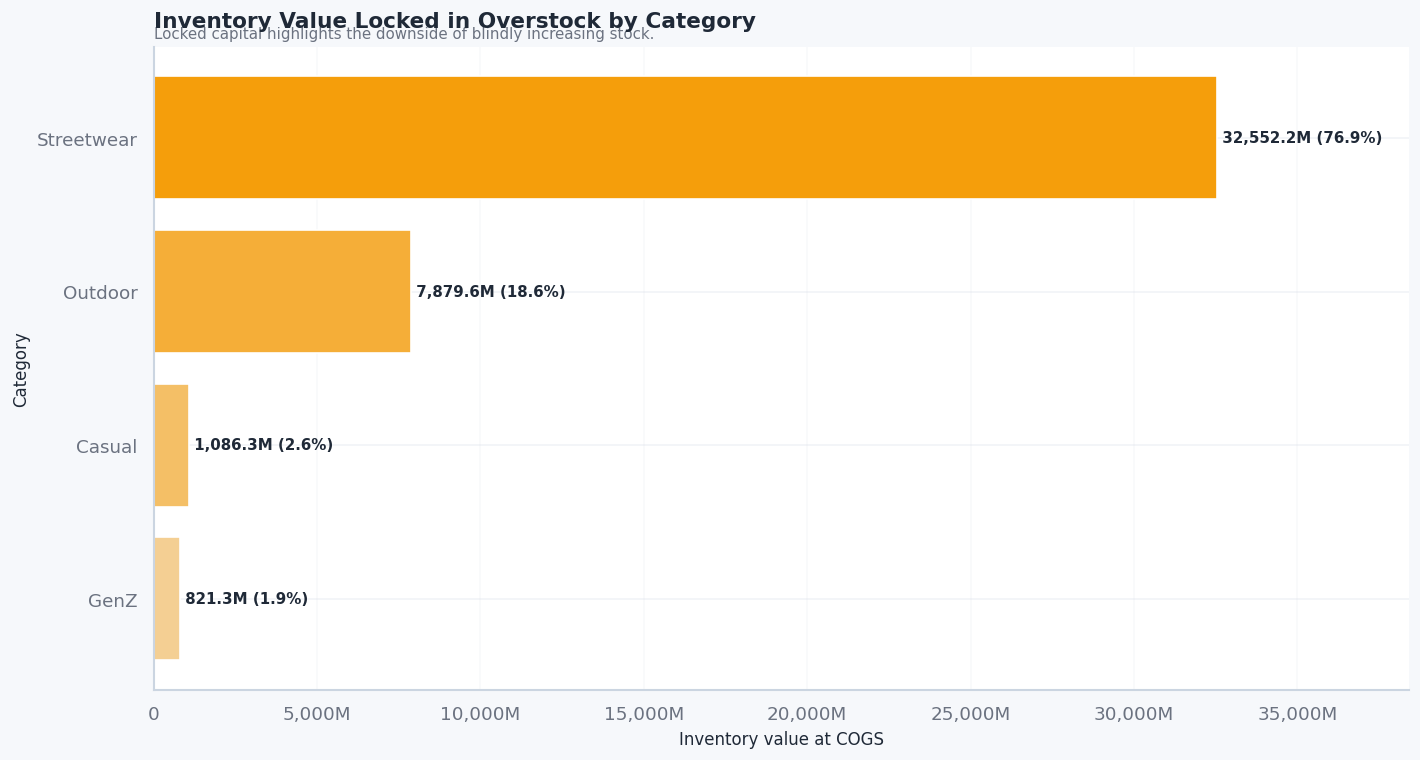

In [15]:
fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BACKGROUND)
plot_df = overstock_summary.sort_values('overstock_inventory_value', ascending=True).copy()
plot_df['share'] = plot_df['overstock_inventory_value'] / plot_df['overstock_inventory_value'].sum()
colors = sns.light_palette(PALETTE['overstock'], n_colors=len(plot_df) + 2)[2:]
ax.barh(plot_df['category'], plot_df['overstock_inventory_value'], color=colors, edgecolor='white')
clean_axis(
    ax,
    'Inventory Value Locked in Overstock by Category',
    'Inventory value at COGS',
    'Category',
    subtitle='Locked capital highlights the downside of blindly increasing stock.'
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))
ax.margins(x=0.18)
for patch, (_, row) in zip(ax.patches, plot_df.iterrows()):
    ax.text(
        patch.get_width(),
        patch.get_y() + patch.get_height() / 2,
        f" {fmt_currency(row['overstock_inventory_value'])} ({fmt_percent(row['share'])})",
        va='center',
        ha='left',
        fontsize=9,
        weight='bold',
        color=TEXT
    )
plt.tight_layout()
plt.show()


In [16]:
total_locked_capital = overstock_summary['overstock_inventory_value'].sum()
top_overstock_value = overstock_summary.iloc[0]
overstock_records = inv_lost['overstock_flag'].sum()

overstock_takeaways = pd.DataFrame({
    'Metric': [
        'Total locked capital in overstock records',
        'Overstock records',
        'Top locked-capital category',
        'Top category stock on hand',
        'Top category avg days of supply'
    ],
    'Value': [
        fmt_currency(total_locked_capital),
        fmt_number(overstock_records),
        f"{top_overstock_value['category']} ({fmt_currency(top_overstock_value['overstock_inventory_value'])})",
        fmt_number(top_overstock_value['stock_on_hand']),
        fmt_number(top_overstock_value['avg_days_of_supply'], 1)
    ]
})

display(overstock_takeaways)


,Metric,Value
0,Total locked capital in overstock records,"42,339.4M"
1,Overstock records,"45,942"
2,Top locked-capital category,"Streetwear (32,552.2M)"
3,Top category stock on hand,"5,506,989"
4,Top category avg days of supply,"1,163.7"


### **Nhận xét về dư hàng và vốn bị khóa**

Các bản ghi dư hàng đang khóa khoảng **42,339.4M** theo giá vốn. Riêng **Streetwear** chiếm **32,552.2M**, tương đương **76.9%** tổng vốn bị khóa trong hàng dư.

Điều này tạo ra một phát hiện rất quan trọng: **Streetwear vừa là nhóm mất doanh thu nhiều nhất do thiếu hàng, vừa là nhóm khóa vốn nhiều nhất do dư hàng**. Nếu chỉ nhìn bề mặt, điều này có vẻ mâu thuẫn. Nhưng về kinh doanh, nó thường có nghĩa là Streetwear đang sai cơ cấu tồn kho: có mã dư nhiều, nhưng mã có nhu cầu lại không đủ hàng.

**Việc nên làm:** không nhập thêm Streetwear một cách đại trà. Cần tách từng mã: mã bán tốt và hay thiếu thì tăng hàng; mã dư lâu thì giảm nhập, bundle hoặc markdown.

**Kết luận:** Vấn đề của Streetwear không phải là “cần nhiều hàng hơn”, mà là **cần đúng hàng hơn**.

## **7. [Diagnostic] Ma trận thiếu hàng - dư hàng**

Phần này giúp biến dữ liệu thành nhóm hành động dễ hiểu. Thay vì nhìn từng mã sản phẩm riêng lẻ, notebook chia sản phẩm thành 4 nhóm:

- **Thiếu hàng thường xuyên:** cần xem xét tăng tồn an toàn hoặc bổ sung hàng nhanh hơn.
- **Dư hàng:** cần giảm nhập, xả hàng hoặc bundle.
- **Tồn kho biến động:** vừa thiếu vừa dư, cần xem lại dự báo và thời điểm nhập hàng.
- **Ổn định:** chưa cần can thiệp mạnh, chỉ cần theo dõi.

Mục tiêu là tránh một sai lầm phổ biến: dùng cùng một giải pháp cho tất cả sản phẩm.

In [17]:
matrix_df = (
    inv_lost
    .groupby(['product_id', 'product_name', 'category', 'segment'])
    .agg(
        stockout_rate=('stockout_flag', 'mean'),
        overstock_rate=('overstock_flag', 'mean'),
        lost_revenue=('lost_revenue_est', 'sum'),
        inventory_value=('inventory_value', 'mean'),
        total_units_sold=('units_sold', 'sum')
    )
    .reset_index()
)

stockout_median = matrix_df['stockout_rate'].median()
overstock_median = matrix_df['overstock_rate'].median()


def classify_inventory(row):
    if row['stockout_rate'] > stockout_median and row['overstock_rate'] <= overstock_median:
        return 'Thiếu hàng thường xuyên'
    if row['stockout_rate'] <= stockout_median and row['overstock_rate'] > overstock_median:
        return 'Dư hàng'
    if row['stockout_rate'] > stockout_median and row['overstock_rate'] > overstock_median:
        return 'Tồn kho biến động'
    return 'Ổn định'

matrix_df['inventory_group'] = matrix_df.apply(classify_inventory, axis=1)

group_counts = matrix_df['inventory_group'].value_counts().rename_axis('inventory_group').reset_index(name='products')
display(group_counts)
display(matrix_df.sort_values('lost_revenue', ascending=False).head(20))


,inventory_group,products
0,Dư hàng,452
1,Thiếu hàng thường xuyên,449
2,Ổn định,363
3,Tồn kho biến động,360


,product_id,product_name,category,segment,stockout_rate,overstock_rate,lost_revenue,inventory_value,total_units_sold,inventory_group
315,487,SaigonFlex UM-92,Streetwear,Balanced,0.6667,0.8333,"19,052,306.0484","15,073,582.9223",9623,Dư hàng
279,438,SaigonFlex UM-43,Streetwear,Balanced,0.7073,0.6829,"12,402,112.1775","6,246,405.4087",9124,Tồn kho biến động
574,826,HanoiStreet UM-10,Streetwear,Balanced,0.5794,0.9921,"12,382,441.0134","16,390,957.7332",8315,Dư hàng
418,604,SaigonFlex UC-69,Streetwear,Everyday,0.7143,0.9762,"10,681,555.2641","6,868,125.8598",10506,Tồn kho biến động
319,491,SaigonFlex UM-96,Streetwear,Balanced,0.6777,0.7934,"10,555,003.5331","6,671,559.4119",7048,Dư hàng
1570,2332,VietMotion UE-06,Streetwear,Performance,0.6349,0.9524,"9,617,718.0092","5,433,240.3188",9386,Dư hàng
1403,2045,UrbanVN UE-05,Streetwear,Performance,0.6240,0.9280,"9,332,562.3487","4,503,497.2566",10376,Dư hàng
305,475,SaigonFlex UM-80,Streetwear,Balanced,0.5714,1.0000,"8,698,297.6790","8,890,943.3620",6434,Dư hàng
610,927,HanoiStreet UE-36,Streetwear,Performance,0.6752,0.9487,"8,603,014.6047","7,196,865.3013",9002,Dư hàng
1410,2054,UrbanVN UE-14,Streetwear,Performance,0.7222,0.9603,"8,093,447.9997","7,175,593.4023",7069,Tồn kho biến động


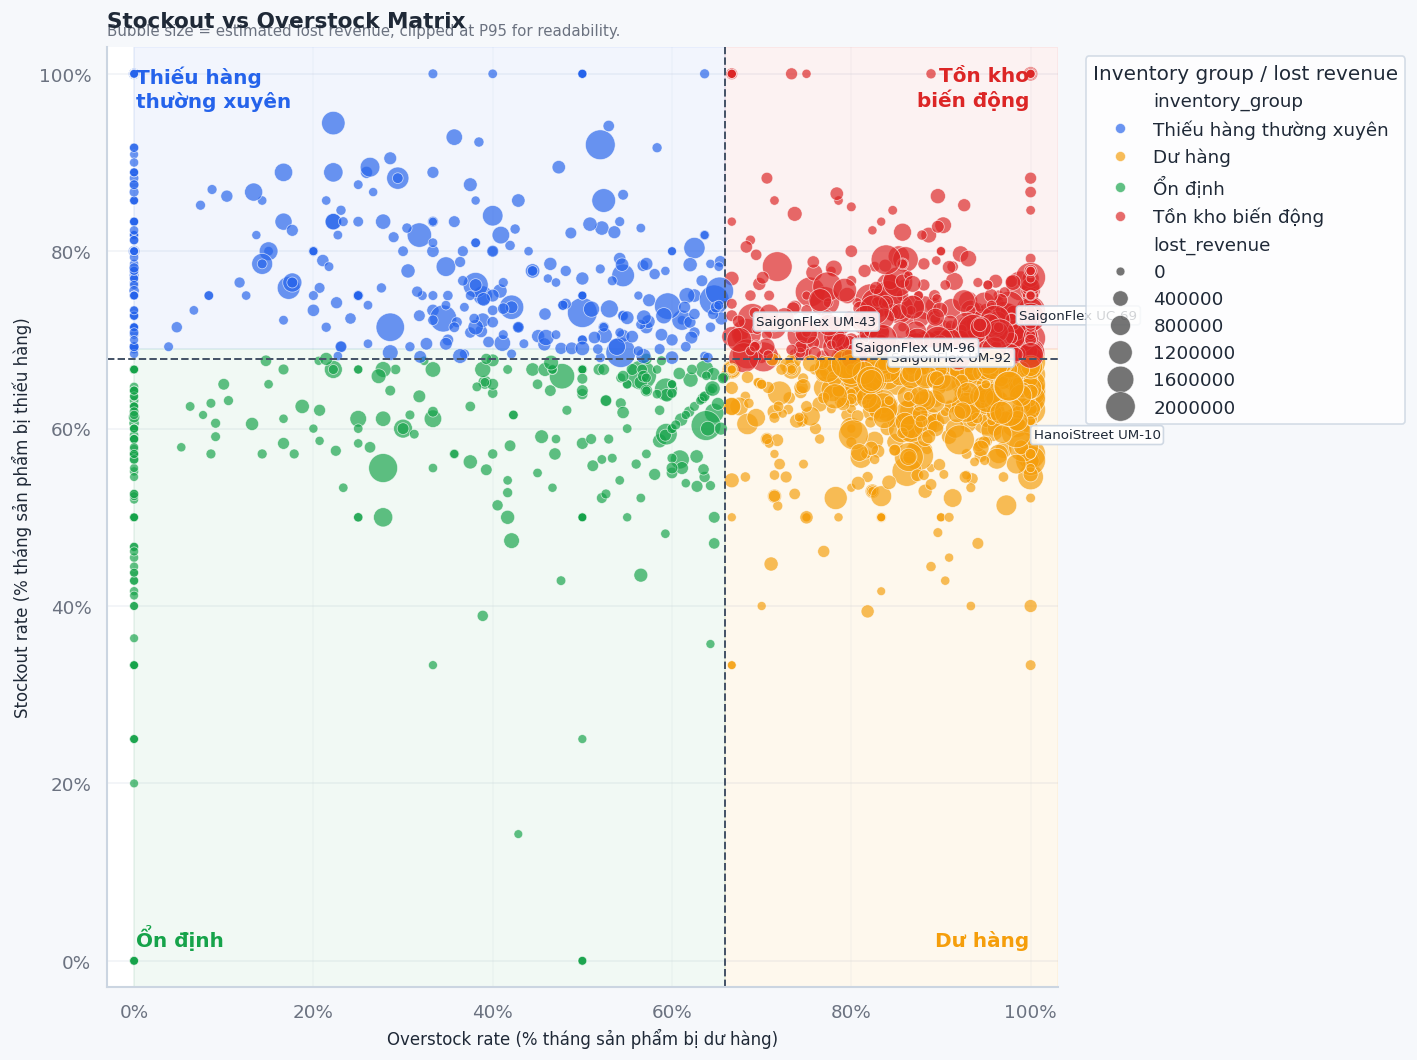

In [18]:
fig, ax = plt.subplots(figsize=(12, 9), facecolor=BACKGROUND)

# Light quadrant backgrounds make the operational interpretation visible before reading the legend.
ax.axvspan(0, overstock_median, ymin=stockout_median, ymax=1, color=PALETTE['stockout'], alpha=0.06)
ax.axvspan(overstock_median, 1.03, ymin=0, ymax=stockout_median, color=PALETTE['overstock'], alpha=0.07)
ax.axvspan(overstock_median, 1.03, ymin=stockout_median, ymax=1, color=PALETTE['volatile'], alpha=0.06)
ax.axvspan(0, overstock_median, ymin=0, ymax=stockout_median, color=PALETTE['stable'], alpha=0.06)

size_max = max(matrix_df['lost_revenue'].quantile(0.95), 1)
sns.scatterplot(
    data=matrix_df,
    x='overstock_rate',
    y='stockout_rate',
    hue='inventory_group',
    size=matrix_df['lost_revenue'].clip(upper=size_max),
    sizes=(28, 320),
    alpha=0.68,
    linewidth=0.45,
    edgecolor='white',
    palette=GROUP_COLORS,
    ax=ax
)
ax.axhline(stockout_median, color=PALETTE['neutral'], linestyle='--', linewidth=1.2)
ax.axvline(overstock_median, color=PALETTE['neutral'], linestyle='--', linewidth=1.2)
ax.text(0.03, 0.98, 'Thiếu hàng\nthường xuyên', transform=ax.transAxes, ha='left', va='top', fontsize=12, weight='bold', color=PALETTE['stockout'])
ax.text(0.97, 0.98, 'Tồn kho\nbiến động', transform=ax.transAxes, ha='right', va='top', fontsize=12, weight='bold', color=PALETTE['volatile'])
ax.text(0.97, 0.04, 'Dư hàng', transform=ax.transAxes, ha='right', va='bottom', fontsize=12, weight='bold', color=PALETTE['overstock'])
ax.text(0.03, 0.04, 'Ổn định', transform=ax.transAxes, ha='left', va='bottom', fontsize=12, weight='bold', color=PALETTE['stable'])

for _, row in matrix_df.nlargest(5, 'lost_revenue').iterrows():
    ax.annotate(
        row['product_name'],
        (row['overstock_rate'], row['stockout_rate']),
        xytext=(6, 5),
        textcoords='offset points',
        fontsize=8,
        color=TEXT,
        bbox=dict(boxstyle='round,pad=0.22', fc='white', ec='#CBD5E1', alpha=0.9)
    )

clean_axis(
    ax,
    'Stockout vs Overstock Matrix',
    'Overstock rate (% tháng sản phẩm bị dư hàng)',
    'Stockout rate (% tháng sản phẩm bị thiếu hàng)',
    subtitle='Bubble size = estimated lost revenue, clipped at P95 for readability.'
)
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title='Inventory group / lost revenue', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, edgecolor='#CBD5E1')
plt.tight_layout()
plt.show()


In [19]:
group_count_map = matrix_df['inventory_group'].value_counts().to_dict()
volatile_count = group_count_map.get('Tồn kho biến động', 0)
shortage_count = group_count_map.get('Thiếu hàng thường xuyên', 0)
overstock_count = group_count_map.get('Dư hàng', 0)
stable_count = group_count_map.get('Ổn định', 0)

matrix_group_summary = (
    matrix_df.groupby('inventory_group')
    .agg(
        products=('product_id', 'nunique'),
        avg_stockout_rate=('stockout_rate', 'mean'),
        avg_overstock_rate=('overstock_rate', 'mean'),
        lost_revenue=('lost_revenue', 'sum'),
        avg_inventory_value=('inventory_value', 'mean')
    )
    .reset_index()
    .sort_values('lost_revenue', ascending=False)
)

matrix_group_summary_display = matrix_group_summary.copy()
matrix_group_summary_display['avg_stockout_rate'] = matrix_group_summary_display['avg_stockout_rate'].map(fmt_percent)
matrix_group_summary_display['avg_overstock_rate'] = matrix_group_summary_display['avg_overstock_rate'].map(fmt_percent)
matrix_group_summary_display['lost_revenue'] = matrix_group_summary_display['lost_revenue'].map(fmt_currency)
matrix_group_summary_display['avg_inventory_value'] = matrix_group_summary_display['avg_inventory_value'].map(fmt_currency)

display(matrix_group_summary_display)


,inventory_group,products,avg_stockout_rate,avg_overstock_rate,lost_revenue,avg_inventory_value
0,Dư hàng,452,61.6%,87.2%,397.9M,735.9K
2,Tồn kho biến động,360,74.2%,86.7%,290.2M,579.9K
1,Thiếu hàng thường xuyên,449,83.4%,23.1%,71.0M,89.3K
3,Ổn định,363,51.1%,25.6%,40.7M,89.4K


### **Nhận xét từ ma trận thiếu hàng - dư hàng**

Ma trận chia danh mục thành 4 nhóm hành động: thiếu hàng thường xuyên, dư hàng, tồn kho biến động và ổn định.

Điểm quan trọng là nhóm **“Dư hàng” vẫn tạo lost revenue lớn nhất: 397.9M trên 452 SKU**. Đây không phải mâu thuẫn. Một SKU có thể dư hàng trong nhiều tháng nhưng vẫn thiếu vào đúng tháng cao điểm hoặc thiếu ở biến thể/kênh có nhu cầu cao.

Nói cách khác, vấn đề không chỉ là tổng lượng tồn kho, mà là **timing và mix của inventory**.

**Executive takeaway:** Không nên áp dụng một chính sách tồn kho chung. Mỗi nhóm cần một playbook riêng: tăng safety stock cho nhóm thiếu hàng, markdown/bundle cho nhóm dư, và kiểm tra forecast/allocation cho nhóm biến động.

### **7.1 [Diagnostic] Streetwear SKU Mix: Vì sao vừa mất doanh thu vừa khóa vốn?**

Các phần trước cho thấy Streetwear vừa tạo phần lớn doanh thu bị mất, vừa khóa nhiều vốn trong hàng dư. Nếu dừng ở category level, nhận xét này vẫn còn quá chung.

Phần này đi xuống cấp mã sản phẩm để trả lời: trong Streetwear, mã nào thật sự cần bổ sung hàng, mã nào đang dư hàng, và hai nhóm này có trùng nhau không.


In [20]:
streetwear_mix = matrix_df[matrix_df['category'] == 'Streetwear'].copy()
streetwear_total_skus = streetwear_mix['product_id'].nunique()

streetwear_group_summary = (
    streetwear_mix
    .groupby('inventory_group')
    .agg(
        skus=('product_id', 'nunique'),
        lost_revenue=('lost_revenue', 'sum'),
        avg_inventory_value=('inventory_value', 'mean'),
        avg_stockout_rate=('stockout_rate', 'mean'),
        avg_overstock_rate=('overstock_rate', 'mean')
    )
    .reset_index()
    .sort_values('lost_revenue', ascending=False)
)

streetwear_product_impact = (
    inv_lost[inv_lost['category'] == 'Streetwear']
    .groupby(['product_id', 'product_name', 'segment'])
    .agg(
        lost_revenue=('lost_revenue_est', 'sum'),
        lost_margin=('lost_margin_est', 'sum'),
        stockout_rate=('stockout_flag', 'mean'),
        overstock_rate=('overstock_flag', 'mean'),
        total_units_sold=('units_sold', 'sum'),
        avg_inventory_value=('inventory_value', 'mean'),
        avg_days_of_supply=('days_of_supply', 'mean')
    )
    .reset_index()
)

streetwear_shortage_top = (
    streetwear_product_impact
    .sort_values('lost_revenue', ascending=False)
    .head(10)[['product_id', 'product_name', 'segment', 'lost_revenue', 'lost_margin', 'stockout_rate', 'total_units_sold']]
)

streetwear_surplus_top = (
    streetwear_product_impact
    .sort_values('avg_inventory_value', ascending=False)
    .head(10)[['product_id', 'product_name', 'segment', 'avg_inventory_value', 'avg_days_of_supply', 'overstock_rate', 'stockout_rate', 'total_units_sold']]
)

# Use top lost-revenue and top locked-capital SKUs to check whether shortage and surplus are the same SKUs.
top_lost_ids = set(streetwear_shortage_top['product_id'])
top_surplus_ids = set(streetwear_surplus_top['product_id'])
streetwear_overlap_ids = top_lost_ids.intersection(top_surplus_ids)
streetwear_overlap = streetwear_product_impact[streetwear_product_impact['product_id'].isin(streetwear_overlap_ids)].copy()

streetwear_mix_display = streetwear_group_summary.copy()
for col in ['lost_revenue', 'avg_inventory_value']:
    streetwear_mix_display[col] = streetwear_mix_display[col].map(fmt_currency)
for col in ['avg_stockout_rate', 'avg_overstock_rate']:
    streetwear_mix_display[col] = streetwear_mix_display[col].map(fmt_percent)

display(pd.DataFrame({'Metric': ['Streetwear total SKUs', 'Overlap giữa top lost revenue và top locked capital'], 'Value': [streetwear_total_skus, len(streetwear_overlap_ids)]}))
display(streetwear_mix_display)
display(streetwear_shortage_top)
display(streetwear_surplus_top)

streetwear_group_summary.to_csv(OUTPUT_DIR / 'streetwear_sku_mix.csv', index=False)


,Metric,Value
0,Streetwear total SKUs,890
1,Overlap giữa top lost revenue và top locked capital,6


,inventory_group,skus,lost_revenue,avg_inventory_value,avg_stockout_rate,avg_overstock_rate
0,Dư hàng,253,319.2M,1.1M,61.1%,86.5%
2,Tồn kho biến động,195,225.9M,830.6K,74.7%,85.8%
1,Thiếu hàng thường xuyên,249,61.7M,141.6K,83.4%,25.0%
3,Ổn định,193,35.5M,148.7K,51.4%,27.6%


,product_id,product_name,segment,lost_revenue,lost_margin,stockout_rate,total_units_sold
254,487,SaigonFlex UM-92,Balanced,"19,052,306.0484","2,915,002.8254",0.6667,9623
218,438,SaigonFlex UM-43,Balanced,"12,402,112.1775","5,331,668.0251",0.7073,9124
436,826,HanoiStreet UM-10,Balanced,"12,382,441.0134","619,122.0507",0.5794,8315
357,604,SaigonFlex UC-69,Everyday,"10,681,555.2641","3,470,437.3053",0.7143,10506
258,491,SaigonFlex UM-96,Balanced,"10,555,003.5331","527,750.1767",0.6777,7048
850,2332,VietMotion UE-06,Performance,"9,617,718.0092","2,064,924.0566",0.6349,9386
741,2045,UrbanVN UE-05,Performance,"9,332,562.3487","4,311,643.8051",0.6240,10376
244,475,SaigonFlex UM-80,Balanced,"8,698,297.6790","1,770,103.5777",0.5714,6434
472,927,HanoiStreet UE-36,Performance,"8,603,014.6047","430,150.7302",0.6752,9002
748,2054,UrbanVN UE-14,Performance,"8,093,447.9997","404,672.4000",0.7222,7069


,product_id,product_name,segment,avg_inventory_value,avg_days_of_supply,overstock_rate,stockout_rate,total_units_sold
436,826,HanoiStreet UM-10,Balanced,"16,390,957.7332","1,008.6000",0.9921,0.5794,8315
254,487,SaigonFlex UM-92,Balanced,"15,073,582.9223","4,083.8167",0.8333,0.6667,9623
273,506,SaigonFlex UM-11,Balanced,"9,615,445.9551",232.0366,0.9512,0.6341,4132
244,475,SaigonFlex UM-80,Balanced,"8,890,943.3620","6,547.9270",1.0000,0.5714,6434
180,396,SaigonFlex UM-01,Balanced,"8,543,781.7041","3,006.8879",1.0000,0.6379,5041
383,635,SaigonFlex UC-00,Everyday,"7,522,091.9865","4,510.4076",1.0000,0.6212,4284
472,927,HanoiStreet UE-36,Performance,"7,196,865.3013","1,613.3128",0.9487,0.6752,9002
748,2054,UrbanVN UE-14,Performance,"7,175,593.4023","1,979.0984",0.9603,0.7222,7069
225,449,SaigonFlex UM-54,Balanced,"6,973,169.3687",134.9517,0.6897,0.7241,4684
357,604,SaigonFlex UC-69,Everyday,"6,868,125.8598","2,493.0508",0.9762,0.7143,10506


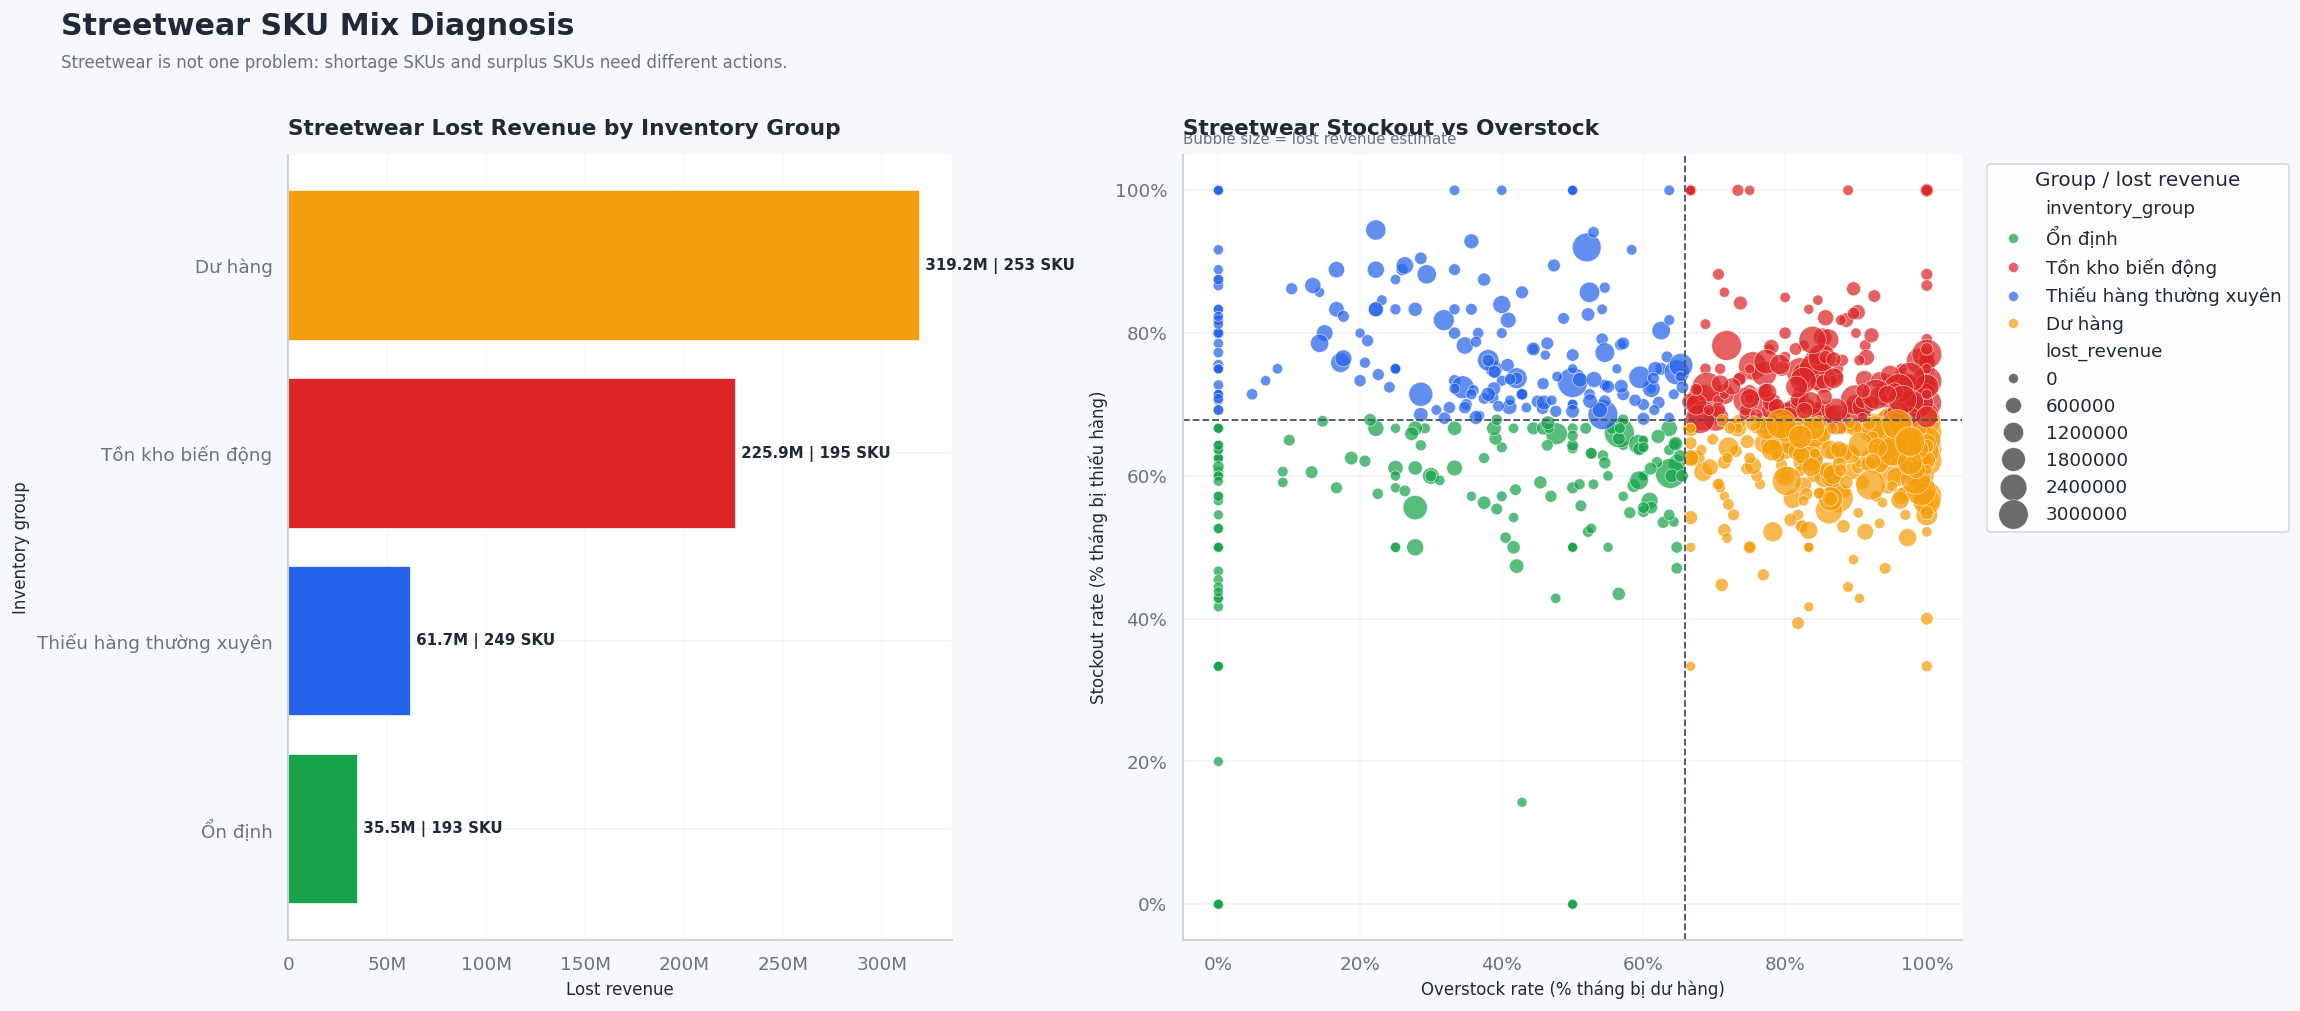

In [21]:
fig = plt.figure(figsize=(18, 8.5), facecolor=BACKGROUND)
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.15, 1.35], wspace=0.32)
fig.suptitle('Streetwear SKU Mix Diagnosis', fontsize=18, fontweight='bold', color=TEXT, x=0.02, ha='left', y=1.02)
fig.text(0.02, 0.965, 'Streetwear is not one problem: shortage SKUs and surplus SKUs need different actions.', fontsize=10, color=MUTED)

ax1 = fig.add_subplot(gs[0, 0])
plot_group = streetwear_group_summary.sort_values('lost_revenue', ascending=True)
colors = plot_group['inventory_group'].map(GROUP_COLORS)
ax1.barh(plot_group['inventory_group'], plot_group['lost_revenue'], color=colors, edgecolor='white')
clean_axis(ax1, 'Streetwear Lost Revenue by Inventory Group', 'Lost revenue', 'Inventory group')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))
for patch, (_, row) in zip(ax1.patches, plot_group.iterrows()):
    ax1.text(patch.get_width(), patch.get_y() + patch.get_height()/2, f" {fmt_currency(row['lost_revenue'])} | {int(row['skus'])} SKU", va='center', fontsize=9, weight='bold')

ax2 = fig.add_subplot(gs[0, 1])
size_max = max(streetwear_mix['lost_revenue'].quantile(0.95), 1)
sns.scatterplot(
    data=streetwear_mix,
    x='overstock_rate',
    y='stockout_rate',
    hue='inventory_group',
    size=streetwear_mix['lost_revenue'].clip(upper=size_max),
    sizes=(35, 320),
    alpha=0.72,
    linewidth=0.4,
    edgecolor='white',
    palette=GROUP_COLORS,
    ax=ax2
)
ax2.axhline(stockout_median, color=PALETTE['neutral'], linestyle='--', linewidth=1.1)
ax2.axvline(overstock_median, color=PALETTE['neutral'], linestyle='--', linewidth=1.1)
clean_axis(ax2, 'Streetwear Stockout vs Overstock', 'Overstock rate (% tháng bị dư hàng)', 'Stockout rate (% tháng bị thiếu hàng)', subtitle='Bubble size = lost revenue estimate')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.legend(title='Group / lost revenue', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, edgecolor='#CBD5E1')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


#### **Nhận xét : Streetwear SKU Mix Diagnosis**

Biểu đồ cho thấy vấn đề của **Streetwear không phải là thiếu hàng hay dư hàng đơn thuần**, mà là **sai cơ cấu tồn kho ở cấp SKU**. Nhóm **Dư hàng** tạo lost revenue lớn nhất, khoảng **319.2M** trên **253 SKU**, trong khi nhóm **Tồn kho biến động** cũng đóng góp thêm **225.9M** trên **195 SKU**. Điều này cho thấy phần lớn thất thoát của Streetwear không đến từ các SKU “thiếu hàng thuần túy”, mà đến từ những SKU có tồn kho không ổn định hoặc bị đặt sai thời điểm.

Điểm đáng chú ý là nhóm **Thiếu hàng thường xuyên** chỉ tạo khoảng **61.7M lost revenue** trên **249 SKU**, thấp hơn nhiều so với nhóm Dư hàng. Nếu chỉ nhìn stockout và quyết định “nhập thêm Streetwear”, doanh nghiệp có nguy cơ làm tình trạng dư hàng nặng hơn, vì nhóm đang gây mất doanh thu lớn nhất lại là nhóm đã có overstock rate cao.

Ma trận bên phải củng cố insight này: nhiều SKU Streetwear nằm ở vùng **overstock rate cao 70-100%**, nhưng vẫn có stockout rate quanh **55-75%**. Nói cách khác, các SKU này không thiếu hàng trên tổng thể, nhưng vẫn thiếu ở một số thời điểm hoặc một số biến thể. Đây là dấu hiệu của vấn đề **timing, SKU mix hoặc phân bổ hàng**, hơn là thiếu tổng lượng tồn kho.

Về hành động, Streetwear cần được tách thành 3 nhóm xử lý khác nhau:

- **SKU dư hàng nhưng vẫn tạo lost revenue cao:** không nhập thêm đại trà; kiểm tra timing, size/color mix và phân bổ hàng theo tháng.
- **SKU tồn kho biến động:** rà soát forecast và lịch replenishment vì đây là nhóm vừa thiếu vừa dư, rủi ro vận hành cao nhất.
- **SKU thiếu hàng thường xuyên:** chỉ nhóm này mới phù hợp để tăng safety stock hoặc reorder point.

**Kết luận cho Stakeholder:** Streetwear không cần “nhiều hàng hơn”; Streetwear cần **đúng hàng hơn**. Ưu tiên nên là tái phân bổ và tối ưu SKU mix trước khi tăng ngân sách nhập hàng.


## **8. [Predictive] Điểm đặt hàng lại động (Dynamic ROP)**

Sau khi hiểu hiện trạng và nguyên nhân, bước tiếp theo là thử xây dựng tín hiệu cảnh báo sớm.

Điểm đặt hàng lại có thể hiểu đơn giản là: **khi tồn kho giảm xuống dưới mức này, doanh nghiệp nên cân nhắc đặt thêm hàng**. Notebook tính mức này dựa trên lượng bán gần đây, thời gian chờ hàng và một phần tồn kho an toàn.

Tuy nhiên, cần nhớ rằng dữ liệu hiện tại là ảnh chụp tồn kho theo tháng. Nếu một sản phẩm thiếu hàng giữa tháng nhưng được nhập lại trước cuối tháng, snapshot cuối tháng có thể không còn thể hiện tình trạng thiếu. Vì vậy, tín hiệu này cần được kiểm tra kỹ trước khi dùng để ra quyết định.

In [22]:
LEAD_TIME_DAYS = 14
Z_SCORE = 1.28

rop_df = inv_lost.sort_values(['product_id', 'snapshot_date']).copy()
rop_df['daily_demand'] = rop_df['units_sold'] / 30

rop_df['avg_daily_demand_3m'] = (
    rop_df
    .groupby('product_id')['daily_demand']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

rop_df['std_daily_demand_3m'] = (
    rop_df
    .groupby('product_id')['daily_demand']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).std())
)

rop_df['std_daily_demand_3m'] = rop_df['std_daily_demand_3m'].fillna(0)
rop_df['lead_time_demand'] = rop_df['avg_daily_demand_3m'] * LEAD_TIME_DAYS
rop_df['safety_stock'] = Z_SCORE * rop_df['std_daily_demand_3m'] * np.sqrt(LEAD_TIME_DAYS)
rop_df['dynamic_rop'] = rop_df['lead_time_demand'] + rop_df['safety_stock']
rop_df['below_dynamic_rop'] = np.where(
    rop_df['dynamic_rop'].notna(),
    (rop_df['stock_on_hand'] < rop_df['dynamic_rop']).astype(int),
    np.nan
)

rop_sample_cols = [
    'snapshot_date', 'product_id', 'product_name', 'stock_on_hand', 'units_sold',
    'avg_daily_demand_3m', 'safety_stock', 'dynamic_rop', 'below_dynamic_rop', 'stockout_flag'
]

display(rop_df[rop_sample_cols].head(15))


,snapshot_date,product_id,product_name,stock_on_hand,units_sold,avg_daily_demand_3m,safety_stock,dynamic_rop,below_dynamic_rop,stockout_flag
0,2022-10-31,1,DragonWear MA-01,3,1,NaN,0.0000,NaN,NaN,1
1,2022-11-30,1,DragonWear MA-01,3,1,0.0333,0.0000,0.4667,0.0000,1
2,2022-12-31,1,DragonWear MA-01,3,1,0.0333,0.0000,0.4667,0.0000,1
3,2016-04-30,3,DragonWear MA-03,35,11,NaN,0.0000,NaN,NaN,1
4,2016-05-31,3,DragonWear MA-03,36,10,0.3667,0.0000,5.1333,0.0000,1
5,2016-06-30,3,DragonWear MA-03,37,7,0.3500,0.1129,5.0129,0.0000,1
6,2016-07-31,3,DragonWear MA-03,39,9,0.3111,0.3323,4.6879,0.0000,1
7,2016-08-31,3,DragonWear MA-03,39,4,0.2889,0.2439,4.2883,0.0000,0
8,2016-09-30,3,DragonWear MA-03,40,6,0.2222,0.4018,3.5129,0.0000,0
9,2016-10-31,3,DragonWear MA-03,41,6,0.2111,0.4018,3.3573,0.0000,1


In [23]:
below_rop_rate = rop_df['below_dynamic_rop'].mean()
avg_rop = rop_df['dynamic_rop'].mean()
avg_safety_stock = rop_df['safety_stock'].mean()
valid_rop_records = rop_df['below_dynamic_rop'].notna().sum()
below_rop_records = int((rop_df['below_dynamic_rop'] == 1).sum())

rop_setup_summary = pd.DataFrame({
    'Metric': [
        'Lead time assumption',
        'Service level z-score',
        'Average dynamic ROP',
        'Average safety stock',
        'Valid ROP records',
        'Records below dynamic ROP',
        'Below dynamic ROP rate'
    ],
    'Value': [
        f'{LEAD_TIME_DAYS} days',
        fmt_number(Z_SCORE, 2),
        fmt_number(avg_rop, 1),
        fmt_number(avg_safety_stock, 1),
        fmt_number(valid_rop_records),
        fmt_number(below_rop_records),
        fmt_percent(below_rop_rate, 2)
    ]
})

display(rop_setup_summary)


,Metric,Value
0,Lead time assumption,14 days
1,Service level z-score,1.28
2,Average dynamic ROP,8.3
3,Average safety stock,0.9
4,Valid ROP records,"58,623"
5,Records below dynamic ROP,5
6,Below dynamic ROP rate,0.01%


### **Nhận xét về điểm đặt hàng lại động**

Kết quả cho thấy chỉ **5 / 58,623 bản ghi** nằm dưới điểm đặt hàng lại, tương đương **0.01%**. Con số này quá nhỏ so với tỷ lệ thiếu hàng thực tế.

Điều đó không có nghĩa công thức hoàn toàn vô ích. Nó có thể bắt được các trường hợp rất nghiêm trọng, khi tồn kho cuối kỳ thật sự thấp. Nhưng nó không đủ để phát hiện phần lớn tình huống thiếu hàng trong tháng.

Với stakeholder, cách hiểu đúng là: đây là **chuông báo đỏ**, không phải toàn bộ hệ thống cảnh báo.

**Việc nên làm:** giữ chỉ số này trong dashboard như một tín hiệu phụ, nhưng cần thêm các chỉ số khác để lập danh sách sản phẩm có nguy cơ thiếu hàng.

**Kết luận:** Điểm đặt hàng lại động hữu ích cho ca nghiêm trọng, nhưng chưa đủ mạnh để dùng một mình.

## **9. [Predictive] Kiểm tra tín hiệu ROP có hiệu quả không?**

Phần này kiểm tra xem chuông báo ở phần trước có thật sự đáng tin không.

Cách kiểm tra rất đơn giản: so sánh nhóm bị cảnh báo với nhóm không bị cảnh báo. Nếu nhóm bị cảnh báo có tỷ lệ thiếu hàng cao hơn, tín hiệu có ý nghĩa. Nếu số lượng bị cảnh báo quá ít, tín hiệu có thể đúng nhưng không đủ bao phủ.

Nói theo ngôn ngữ kinh doanh: một chuông báo chỉ hữu ích khi nó vừa **báo đúng**, vừa **không bỏ sót quá nhiều trường hợp quan trọng**.

In [24]:
rop_validation = (
    rop_df
    .dropna(subset=['dynamic_rop', 'below_dynamic_rop'])
    .groupby('below_dynamic_rop')
    .agg(
        records=('product_id', 'size'),
        stockout_rate=('stockout_flag', 'mean'),
        avg_stockout_days=('stockout_days', 'mean'),
        lost_revenue=('lost_revenue_est', 'sum'),
        avg_fill_rate=('fill_rate', 'mean')
    )
    .reset_index()
)

rop_validation['group'] = rop_validation['below_dynamic_rop'].map({0.0: 'Tồn kho trên ROP', 1.0: 'Tồn kho dưới ROP'})
rop_validation = rop_validation[['group', 'below_dynamic_rop', 'records', 'stockout_rate', 'avg_stockout_days', 'lost_revenue', 'avg_fill_rate']]
display(rop_validation)
rop_validation.to_csv(OUTPUT_DIR / 'rop_validation.csv', index=False)


,group,below_dynamic_rop,records,stockout_rate,avg_stockout_days,lost_revenue,avg_fill_rate
0,Tồn kho trên ROP,0.0000,58618,0.6738,1.1648,"799,699,879.6746",0.9612
1,Tồn kho dưới ROP,1.0000,5,1.0000,8.2000,"173,603.5638",0.7267


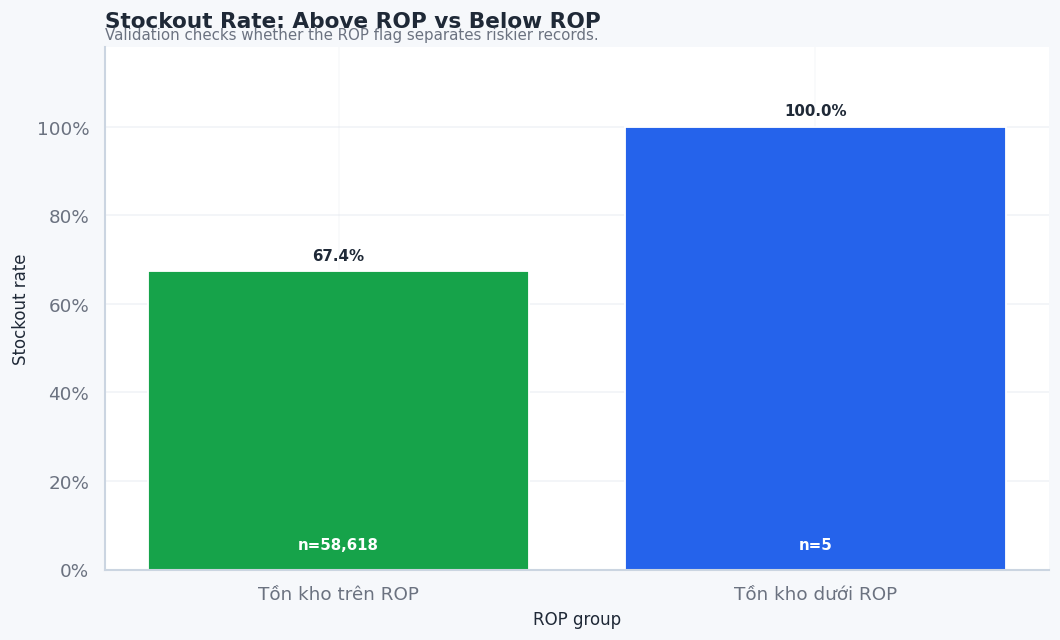

In [25]:
fig, ax = plt.subplots(figsize=(9, 5.5), facecolor=BACKGROUND)
plot_df = rop_validation.copy()
colors = plot_df['group'].map({'Tồn kho trên ROP': PALETTE['stable'], 'Tồn kho dưới ROP': PALETTE['stockout']})
ax.bar(plot_df['group'], plot_df['stockout_rate'], color=colors, edgecolor='white', linewidth=1.1)
clean_axis(
    ax,
    'Stockout Rate: Above ROP vs Below ROP',
    'ROP group',
    'Stockout rate',
    subtitle='Validation checks whether the ROP flag separates riskier records.'
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
label_vbars(ax, fmt=lambda v: fmt_percent(v))
for idx, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(idx, 0.04, f"n={fmt_number(row['records'])}", ha='center', va='bottom', fontsize=9, color='white', weight='bold')
plt.tight_layout()
plt.show()


In [26]:
rop_lookup = rop_validation.set_index('group')
above_rate = rop_lookup.loc['Tồn kho trên ROP', 'stockout_rate'] if 'Tồn kho trên ROP' in rop_lookup.index else np.nan
below_rate = rop_lookup.loc['Tồn kho dưới ROP', 'stockout_rate'] if 'Tồn kho dưới ROP' in rop_lookup.index else np.nan
below_lost = rop_lookup.loc['Tồn kho dưới ROP', 'lost_revenue'] if 'Tồn kho dưới ROP' in rop_lookup.index else np.nan
signal_gap = below_rate - above_rate

rop_signal_summary = pd.DataFrame({
    'Metric': [
        'Stockout rate above ROP',
        'Stockout rate below ROP',
        'Signal gap',
        'Lost revenue below ROP',
        'Validation read'
    ],
    'Value': [
        fmt_percent(above_rate),
        fmt_percent(below_rate),
        fmt_percent(signal_gap),
        fmt_currency(below_lost),
        'High precision but low coverage' if below_rate > above_rate else 'Weak separation'
    ]
})

display(rop_signal_summary)


,Metric,Value
0,Stockout rate above ROP,67.4%
1,Stockout rate below ROP,100.0%
2,Signal gap,32.6%
3,Lost revenue below ROP,173.6K
4,Validation read,High precision but low coverage


### **Nhận xét kiểm định ROP**

Nhóm nằm dưới điểm đặt hàng lại có tỷ lệ thiếu hàng **100.0%**, cao hơn nhóm còn lại (**67.4%**). Điều này cho thấy khi tín hiệu này báo động, rủi ro thiếu hàng thật sự cao.

Nhưng vấn đề là tín hiệu chỉ báo **5 bản ghi**. Trong khi tổng doanh thu bị mất do thiếu hàng là **799.9M**, nhóm bị ROP cảnh báo chỉ gắn với khoảng **173.6K** doanh thu bị mất. Như vậy, nếu chỉ dựa vào ROP, doanh nghiệp sẽ bỏ sót phần lớn vấn đề.

**Việc nên làm:** dùng ROP như cảnh báo đỏ cho trường hợp rất nặng, đồng thời bổ sung một bảng xếp hạng rủi ro rộng hơn cho toàn bộ mã sản phẩm.

**Kết luận:** ROP báo đúng khi nó báo, nhưng báo quá ít nên không thể là công cụ cảnh báo duy nhất.

## **9.1 [Predictive] ROP Sensitivity & Failure Diagnosis**

ROP hiện tại chỉ flag rất ít bản ghi. Phần này không chỉ nói “ROP yếu”, mà kiểm tra vì sao yếu và thử nhiều cấu hình khác nhau.

Mục tiêu là tìm xem ROP thấp do giả định service level, lead time, cách ước tính nhu cầu, hay do bản chất dữ liệu monthly snapshot.


In [27]:
avg_stock_on_hand = rop_df['stock_on_hand'].mean()
median_stock_on_hand = rop_df['stock_on_hand'].median()
avg_dynamic_rop = rop_df['dynamic_rop'].mean()
median_dynamic_rop = rop_df['dynamic_rop'].median()

rop_failure_summary = pd.DataFrame({
    'Metric': ['Average stock_on_hand', 'Median stock_on_hand', 'Average current ROP', 'Median current ROP', 'Records below current ROP'],
    'Value': [fmt_number(avg_stock_on_hand, 1), fmt_number(median_stock_on_hand, 1), fmt_number(avg_dynamic_rop, 1), fmt_number(median_dynamic_rop, 1), fmt_number(below_rop_records)]
})

def compute_rop_scenario(df, lead_time_days, z_score, demand_method, use_seasonality=False):
    tmp = df.sort_values(['product_id', 'snapshot_date']).copy()
    tmp['daily_demand'] = tmp['units_sold'] / 30
    if demand_method == 'mean_3m':
        tmp['base_daily_demand'] = tmp.groupby('product_id')['daily_demand'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    elif demand_method == 'p85_6m':
        tmp['base_daily_demand'] = tmp.groupby('product_id')['daily_demand'].transform(lambda x: x.shift(1).rolling(6, min_periods=3).quantile(0.85))
    elif demand_method == 'p90_6m':
        tmp['base_daily_demand'] = tmp.groupby('product_id')['daily_demand'].transform(lambda x: x.shift(1).rolling(6, min_periods=3).quantile(0.90))
    else:
        raise ValueError(demand_method)
    tmp['std_daily_demand'] = tmp.groupby('product_id')['daily_demand'].transform(lambda x: x.shift(1).rolling(6, min_periods=3).std()).fillna(0)
    if use_seasonality:
        tmp['month'] = tmp['snapshot_date'].dt.month
        month_index = (tmp.groupby('month')['units_sold'].mean() / tmp['units_sold'].mean()).clip(0.8, 1.3)
        tmp['seasonality_multiplier'] = tmp['month'].map(month_index).fillna(1)
    else:
        tmp['seasonality_multiplier'] = 1
    tmp['candidate_rop'] = (tmp['base_daily_demand'] * tmp['seasonality_multiplier'] * lead_time_days) + (z_score * tmp['std_daily_demand'] * np.sqrt(lead_time_days))
    tmp['below_candidate_rop'] = tmp['stock_on_hand'] < tmp['candidate_rop']
    below = tmp[tmp['below_candidate_rop']]
    return {
        'lead_time_days': lead_time_days,
        'z_score': z_score,
        'demand_method': demand_method,
        'seasonality': use_seasonality,
        'avg_rop': tmp['candidate_rop'].mean(),
        'median_rop': tmp['candidate_rop'].median(),
        'records_below_rop': int(tmp['below_candidate_rop'].sum()),
        'below_rop_rate': tmp['below_candidate_rop'].mean(),
        'stockout_rate_below_rop': below['stockout_flag'].mean() if len(below) else np.nan,
        'lost_revenue_captured': below['lost_revenue_est'].sum() if len(below) else 0,
        'lost_revenue_capture_rate': below['lost_revenue_est'].sum() / total_lost_revenue if total_lost_revenue else np.nan
    }

rop_sensitivity = pd.DataFrame([
    compute_rop_scenario(inv_lost, lead, z, method, season)
    for lead in [14, 21, 30]
    for z in [1.28, 1.65, 1.96]
    for method in ['mean_3m', 'p85_6m', 'p90_6m']
    for season in [False, True]
])

recommended_rop_candidate = rop_sensitivity[
    (rop_sensitivity['lead_time_days'] == 21) &
    (rop_sensitivity['z_score'] == 1.65) &
    (rop_sensitivity['demand_method'] == 'p85_6m') &
    (rop_sensitivity['seasonality'] == True)
].iloc[0]

rop_sensitivity_display = rop_sensitivity.sort_values('lost_revenue_capture_rate', ascending=False).head(12).copy()
for c in ['avg_rop', 'median_rop', 'lost_revenue_captured']:
    rop_sensitivity_display[c] = rop_sensitivity_display[c].map(lambda v: fmt_currency(v) if c == 'lost_revenue_captured' else fmt_number(v, 1))
for c in ['below_rop_rate', 'stockout_rate_below_rop', 'lost_revenue_capture_rate']:
    rop_sensitivity_display[c] = rop_sensitivity_display[c].map(fmt_percent)

display(rop_failure_summary)
display(rop_sensitivity_display)
display(pd.DataFrame([recommended_rop_candidate]))
rop_sensitivity.to_csv(OUTPUT_DIR / 'rop_sensitivity.csv', index=False)


,Metric,Value
0,Average stock_on_hand,189.3
1,Median stock_on_hand,62.0
2,Average current ROP,8.3
3,Median current ROP,3.4
4,Records below current ROP,5


,lead_time_days,z_score,demand_method,seasonality,avg_rop,median_rop,records_below_rop,below_rop_rate,stockout_rate_below_rop,lost_revenue_captured,lost_revenue_capture_rate
52,30,1.9600,p90_6m,False,27.6,12.5,3391,5.6%,73.2%,35.9M,4.5%
53,30,1.9600,p90_6m,True,27.8,12.5,3678,6.1%,74.0%,35.6M,4.4%
46,30,1.6500,p90_6m,False,27.1,12.3,3195,5.3%,73.3%,34.7M,4.3%
47,30,1.6500,p90_6m,True,27.4,12.3,3526,5.9%,73.9%,33.7M,4.2%
40,30,1.2800,p90_6m,False,26.6,12.0,3036,5.0%,73.3%,33.4M,4.2%
41,30,1.2800,p90_6m,True,26.9,12.0,3362,5.6%,74.5%,32.5M,4.1%
50,30,1.9600,p85_6m,False,25.7,11.7,2792,4.6%,73.2%,30.8M,3.8%
51,30,1.9600,p85_6m,True,25.9,11.7,3050,5.1%,75.2%,30.2M,3.8%
44,30,1.6500,p85_6m,False,25.3,11.5,2660,4.4%,73.1%,29.5M,3.7%
45,30,1.6500,p85_6m,True,25.5,11.5,2886,4.8%,75.0%,28.9M,3.6%


,lead_time_days,z_score,demand_method,seasonality,avg_rop,median_rop,records_below_rop,below_rop_rate,stockout_rate_below_rop,lost_revenue_captured,lost_revenue_capture_rate
27,21,1.6500,p85_6m,True,18.1624,8.1716,835,0.0139,0.7665,"9,166,632.4050",0.0115


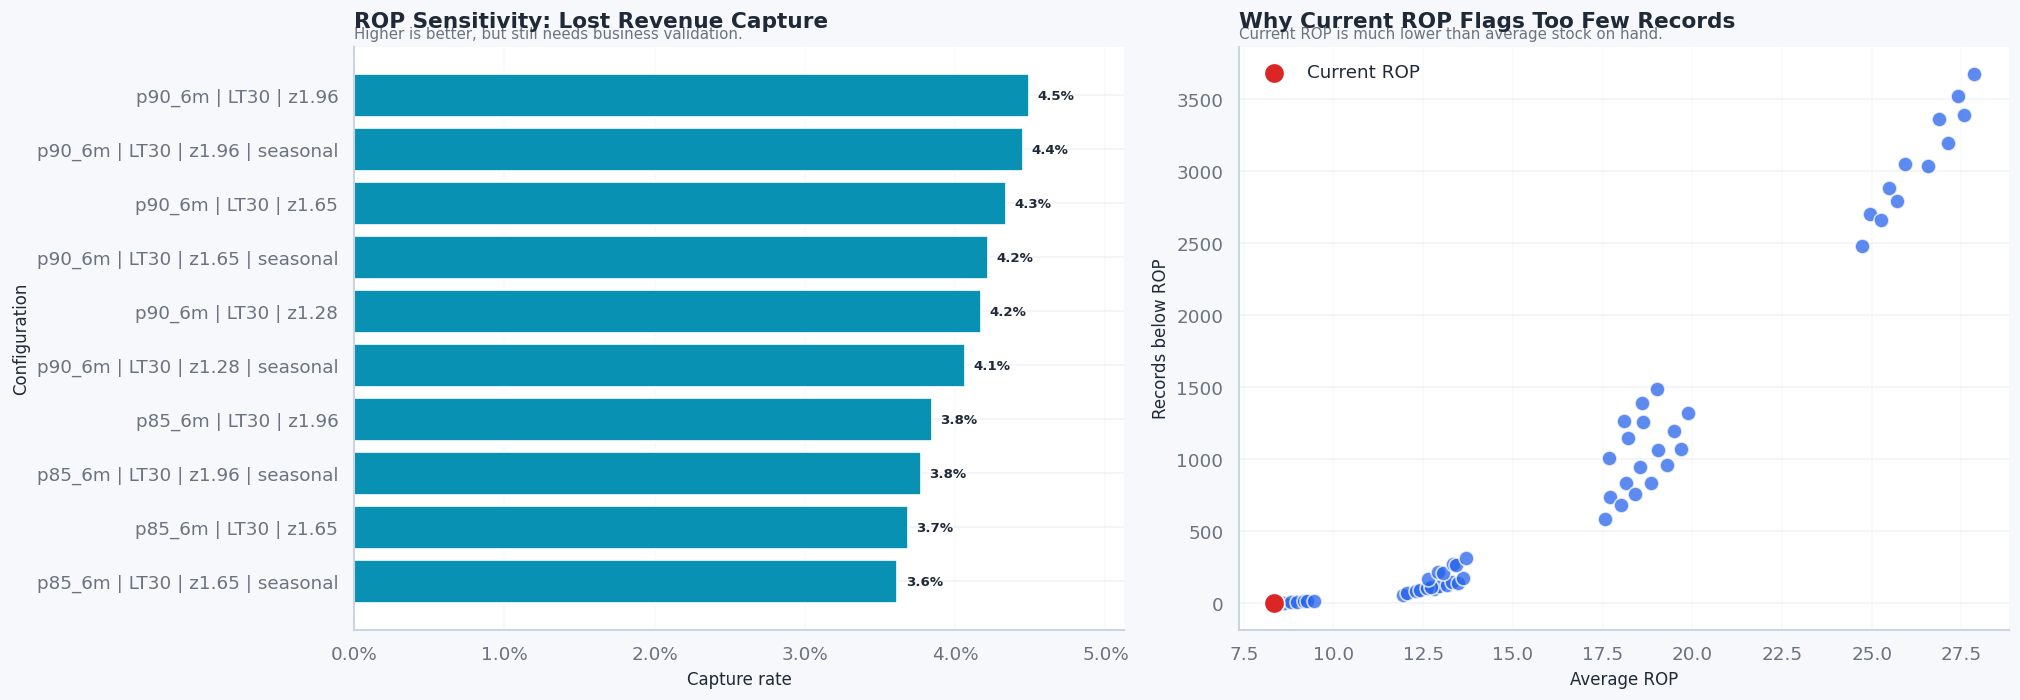

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6), facecolor=BACKGROUND)

plot_sens = rop_sensitivity.copy()
plot_sens['config'] = plot_sens['demand_method'] + ' | LT' + plot_sens['lead_time_days'].astype(str) + ' | z' + plot_sens['z_score'].astype(str) + np.where(plot_sens['seasonality'], ' | seasonal', '')
top_capture = plot_sens.sort_values('lost_revenue_capture_rate', ascending=False).head(10).sort_values('lost_revenue_capture_rate')
axes[0].barh(top_capture['config'], top_capture['lost_revenue_capture_rate'], color=PALETTE['accent'], edgecolor='white')
clean_axis(axes[0], 'ROP Sensitivity: Lost Revenue Capture', 'Capture rate', 'Configuration', subtitle='Higher is better, but still needs business validation.')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
label_hbars(axes[0], fmt=lambda v: fmt_percent(v), fontsize=8)

axes[1].scatter(rop_sensitivity['avg_rop'], rop_sensitivity['records_below_rop'], s=80, color=PALETTE['stockout'], alpha=0.75, edgecolor='white')
axes[1].scatter([avg_dynamic_rop], [below_rop_records], s=150, color=PALETTE['volatile'], edgecolor='white', label='Current ROP')
clean_axis(axes[1], 'Why Current ROP Flags Too Few Records', 'Average ROP', 'Records below ROP', subtitle='Current ROP is much lower than average stock on hand.')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()


### **Nhận xét: ROP Sensitivity & Failure Diagnosis**

Bảng đầu tiên cho thấy nguyên nhân cốt lõi vì sao **ROP hiện tại gần như không cảnh báo được rủi ro thiếu hàng**. Tồn kho trung bình hiện tại là **189.3 units**, median là **62 units**, trong khi ROP hiện tại trung bình chỉ **8.3 units** và median chỉ **3.4 units**. Nói đơn giản, ngưỡng cảnh báo đang đặt quá thấp so với lượng hàng thực tế đang có trong kho. Vì vậy, chỉ có **5 records** nằm dưới ROP hiện tại.

Điều này không có nghĩa là tồn kho đang an toàn. Ngược lại, thực tế stockout rate vẫn rất cao. Vấn đề là **ROP hiện tại không đủ nhạy để bắt rủi ro stockout**, vì nó được tính từ nhu cầu trung bình ngắn hạn và giả định lead time/service level còn khá thấp. Nếu sản phẩm thường có tồn kho cuối tháng cao nhưng vẫn thiếu hàng trong một vài ngày giữa tháng, ROP dùng snapshot cuối tháng sẽ rất dễ bỏ sót rủi ro đó.

Khi thử nhiều cấu hình khác nhau, các cấu hình mạnh hơn như **P90 demand, lead time 30 ngày, z-score 1.96** bắt được nhiều rủi ro hơn: khoảng **3,391 - 3,678 records dưới ROP**, tương đương **5.6% - 6.1%** records, và capture được khoảng **4.4% - 4.5% lost revenue**. Đây là cải thiện rõ so với ROP hiện tại, nhưng vẫn còn thấp so với tổng lost revenue. Điều này cho thấy chỉ điều chỉnh ROP vẫn chưa đủ để bao phủ toàn bộ vấn đề thiếu hàng.

Biểu đồ bên phải cho thấy rất rõ: điểm đỏ “Current ROP” nằm rất thấp, gần như sát đáy, trong khi các cấu hình ROP mới đẩy ngưỡng cảnh báo lên cao hơn và bắt được nhiều records hơn. Tuy vậy, ngay cả cấu hình tốt nhất cũng mới capture được dưới **5% lost revenue**, nên ROP nên được xem là **một lớp cảnh báo vận hành**, không phải hệ thống dự báo hoàn chỉnh.

Về mặt kinh doanh, khuyến nghị không nên dùng ROP hiện tại để ra quyết định đặt hàng. Thay vào đó, nên dùng cấu hình thử nghiệm thận trọng hơn như **lead time 21-30 ngày**, demand percentile **P85/P90**, và service level cao hơn. Đồng thời, ROP cần được kết hợp với các tín hiệu khác như lịch sử stockout, demand pressure, fill rate và danh sách SKU priority.

**Kết luận cho Stakeholder:** ROP hiện tại đang đặt ngưỡng quá thấp nên bỏ sót phần lớn rủi ro thiếu hàng. Doanh nghiệp nên hiệu chỉnh ROP trước khi dùng làm chính sách đặt hàng, và chỉ xem ROP là một lớp cảnh báo bổ sung trong hệ thống quản trị tồn kho.


## **10. [Predictive] Xếp hạng rủi ro thiếu hàng kỳ tới**

Vì ROP chỉ bắt được rất ít trường hợp, phần này tạo thêm một danh sách dễ dùng hơn cho đội inventory: mã nào có nguy cơ thiếu hàng trong kỳ tới.

Điểm rủi ro được tính bằng cách kết hợp nhiều dấu hiệu dễ hiểu:

- Sản phẩm có hay thiếu hàng trong các tháng trước không?
- Nhu cầu gần đây có tăng so với bình thường không?
- Tỷ lệ đáp ứng đơn hàng gần đây có giảm không?
- Tồn kho hiện tại có đủ so với lượng bán gần nhất không?

Sau đó, sản phẩm được chia thành 4 nhóm: **Low, Medium, High, Critical**. Có thể hiểu `Critical` là nhóm cần kiểm tra ngay, còn `High` là nhóm cần đưa vào danh sách theo dõi sát.

In [29]:
risk_df = rop_df.sort_values(['product_id', 'snapshot_date']).copy()

risk_df['hist_stockout_rate_6m'] = (
    risk_df
    .groupby('product_id')['stockout_flag']
    .transform(lambda x: x.shift(1).rolling(6, min_periods=3).mean())
)

risk_df['avg_units_sold_6m'] = (
    risk_df
    .groupby('product_id')['units_sold']
    .transform(lambda x: x.shift(1).rolling(6, min_periods=3).mean())
)

risk_df['avg_fill_rate_3m'] = (
    risk_df
    .groupby('product_id')['fill_rate']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())
)

risk_df['demand_pressure'] = np.where(
    risk_df['avg_units_sold_6m'] > 0,
    risk_df['units_sold'] / risk_df['avg_units_sold_6m'],
    np.nan
)

risk_df['fill_rate_gap'] = (1 - risk_df['avg_fill_rate_3m']).clip(lower=0)
risk_df['stock_cover_ratio'] = np.where(
    risk_df['units_sold'] > 0,
    risk_df['stock_on_hand'] / risk_df['units_sold'],
    np.nan
)
risk_df['stock_pressure'] = (1 - risk_df['stock_cover_ratio']).clip(lower=0, upper=1).fillna(0)

risk_snapshot_date = risk_df['snapshot_date'].max()
risk_latest = risk_df[risk_df['snapshot_date'] == risk_snapshot_date].copy()

# Scale components to 0-1 so the score is interpretable and robust to outliers.
risk_latest['stockout_component'] = risk_latest['hist_stockout_rate_6m'].fillna(risk_latest['stockout_flag'].mean()).clip(0, 1)
risk_latest['demand_component'] = ((risk_latest['demand_pressure'].fillna(1).clip(0, 2.5) - 1) / 1.5).clip(0, 1)
risk_latest['fill_component'] = (risk_latest['fill_rate_gap'].fillna(0).clip(0, 0.25) / 0.25).clip(0, 1)
risk_latest['stock_component'] = risk_latest['stock_pressure'].clip(0, 1)

risk_latest['stockout_risk_score'] = (
    0.40 * risk_latest['stockout_component'] +
    0.25 * risk_latest['demand_component'] +
    0.20 * risk_latest['fill_component'] +
    0.15 * risk_latest['stock_component']
)

risk_latest['stockout_risk_tier'] = pd.cut(
    risk_latest['stockout_risk_score'],
    bins=[-0.001, 0.25, 0.45, 0.65, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

stockout_risk_tier = (
    risk_latest[[
        'snapshot_date',
        'product_id',
        'product_name',
        'category',
        'segment',
        'stock_on_hand',
        'units_sold',
        'hist_stockout_rate_6m',
        'demand_pressure',
        'avg_fill_rate_3m',
        'stock_cover_ratio',
        'stockout_risk_score',
        'stockout_risk_tier'
    ]]
    .sort_values('stockout_risk_score', ascending=False)
)

risk_tier_summary = (
    stockout_risk_tier
    .groupby('stockout_risk_tier', observed=False)
    .agg(
        products=('product_id', 'nunique'),
        avg_risk_score=('stockout_risk_score', 'mean'),
        avg_hist_stockout_rate=('hist_stockout_rate_6m', 'mean'),
        avg_demand_pressure=('demand_pressure', 'mean'),
        avg_fill_rate_3m=('avg_fill_rate_3m', 'mean'),
        median_stock_cover_ratio=('stock_cover_ratio', 'median')
    )
    .reset_index()
)

risk_tier_summary_display = risk_tier_summary.copy()
risk_tier_summary_display['avg_risk_score'] = risk_tier_summary_display['avg_risk_score'].map(lambda v: fmt_number(v, 2))
risk_tier_summary_display['avg_hist_stockout_rate'] = risk_tier_summary_display['avg_hist_stockout_rate'].map(fmt_percent)
risk_tier_summary_display['avg_demand_pressure'] = risk_tier_summary_display['avg_demand_pressure'].map(lambda v: fmt_number(v, 2))
risk_tier_summary_display['avg_fill_rate_3m'] = risk_tier_summary_display['avg_fill_rate_3m'].map(fmt_percent)
risk_tier_summary_display['median_stock_cover_ratio'] = risk_tier_summary_display['median_stock_cover_ratio'].map(lambda v: fmt_number(v, 2))

display(risk_tier_summary_display)
display(stockout_risk_tier.head(20))


,stockout_risk_tier,products,avg_risk_score,avg_hist_stockout_rate,avg_demand_pressure,avg_fill_rate_3m,median_stock_cover_ratio
0,Low,89,0.19,42.6%,0.58,98.1%,18.50
1,Medium,277,0.34,75.3%,0.71,96.3%,11.00
2,High,53,0.52,79.0%,2.40,93.9%,19.21
3,Critical,5,0.73,93.3%,2.87,85.6%,0.80


,snapshot_date,product_id,product_name,category,segment,stock_on_hand,units_sold,hist_stockout_rate_6m,demand_pressure,avg_fill_rate_3m,stock_cover_ratio,stockout_risk_score,stockout_risk_tier
12359,2022-12-31,668,SaigonFlex UC-33,Streetwear,Everyday,11,18,1.0000,2.2500,0.8222,0.6111,0.8089,Critical
28727,2022-12-31,1177,MekongFit UE-13,Streetwear,Performance,41,67,0.6667,2.3647,0.6222,0.6119,0.7523,Critical
28723,2022-12-31,1176,MekongFit UE-12,Streetwear,Performance,4,5,1.0000,3.0000,0.9556,0.8000,0.7155,Critical
15313,2022-12-31,762,HanoiStreet RP-50,Outdoor,Activewear,1221,13,1.0000,2.6000,0.9333,93.9231,0.7034,Critical
53091,2022-12-31,2207,VietMotion RP-04,Outdoor,Activewear,351,59,1.0000,4.1163,0.9444,5.9492,0.6945,Critical
9556,2022-12-31,570,SaigonFlex UC-35,Streetwear,Everyday,49,9,0.8333,3.6000,0.9333,5.4444,0.6367,High
38430,2022-12-31,1657,VietMode RS-95,Outdoor,Premium,12,6,1.0000,2.1429,0.9444,2.0000,0.6349,High
25145,2022-12-31,1085,MekongFit RP-31,Outdoor,Activewear,1390,62,0.8333,3.6117,0.9444,22.4194,0.6278,High
54638,2022-12-31,2238,VietMotion RP-35,Outdoor,Activewear,444,4,0.8333,3.4286,0.9444,111.0000,0.6278,High
54018,2022-12-31,2224,VietMotion RP-21,Outdoor,Activewear,796,75,0.8333,3.8462,0.9444,10.6133,0.6278,High


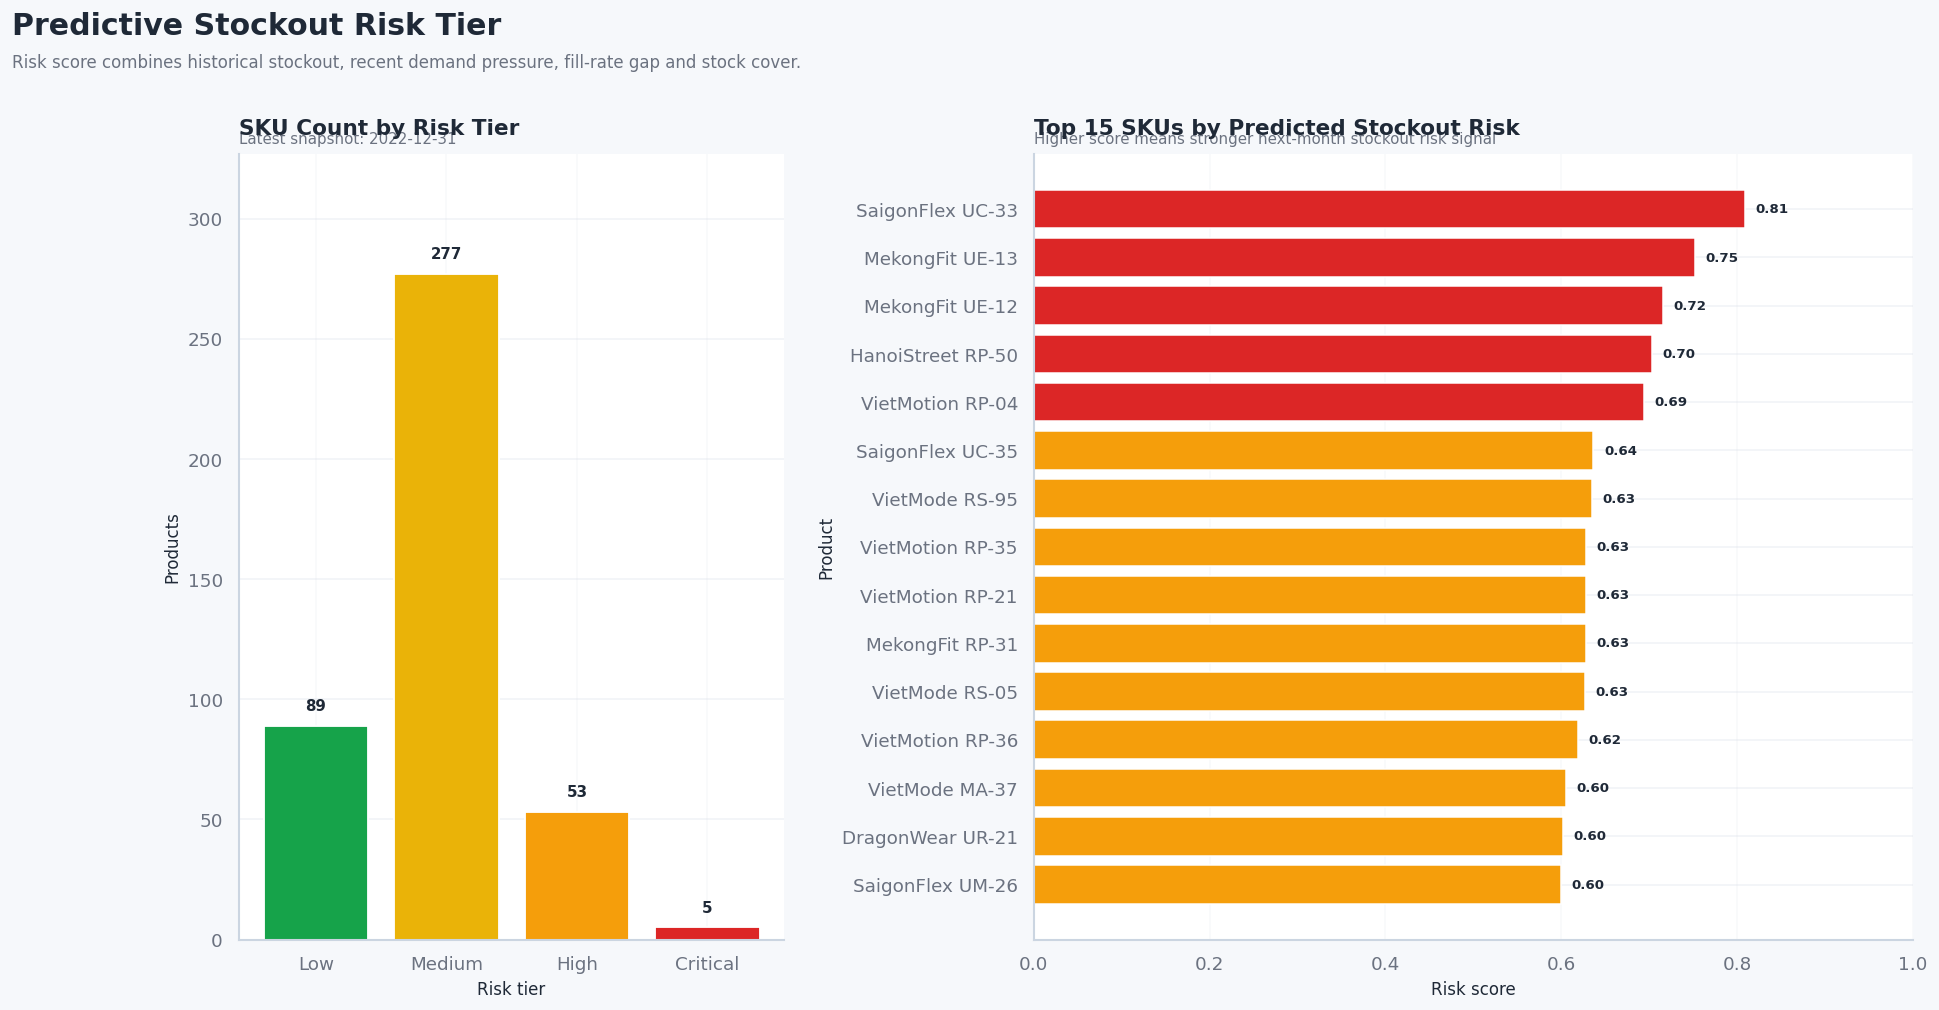

In [30]:
fig = plt.figure(figsize=(18, 8.5), facecolor=BACKGROUND)
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[0.9, 1.45], wspace=0.35)
fig.suptitle('Predictive Stockout Risk Tier', fontsize=18, fontweight='bold', color=TEXT, x=0.02, ha='left', y=1.02)
fig.text(0.02, 0.965, 'Risk score combines historical stockout, recent demand pressure, fill-rate gap and stock cover.', fontsize=10, color=MUTED)

ax_tier = fig.add_subplot(gs[0, 0])
tier_order = ['Low', 'Medium', 'High', 'Critical']
tier_colors = {'Low': PALETTE['stable'], 'Medium': PALETTE['warning'], 'High': PALETTE['overstock'], 'Critical': PALETTE['volatile']}
tier_counts = stockout_risk_tier['stockout_risk_tier'].value_counts().reindex(tier_order).fillna(0)
ax_tier.bar(tier_counts.index.astype(str), tier_counts.values, color=[tier_colors[t] for t in tier_order], edgecolor='white', linewidth=1.1)
clean_axis(ax_tier, 'SKU Count by Risk Tier', 'Risk tier', 'Products', subtitle=f'Latest snapshot: {risk_snapshot_date:%Y-%m-%d}')
label_vbars(ax_tier, fmt=lambda v: fmt_number(v))

ax_top = fig.add_subplot(gs[0, 1])
top_risk = stockout_risk_tier.head(15).sort_values('stockout_risk_score', ascending=True)
colors = top_risk['stockout_risk_tier'].astype(str).map(tier_colors)
ax_top.barh(top_risk['product_name'], top_risk['stockout_risk_score'], color=colors, edgecolor='white', linewidth=0.9)
clean_axis(ax_top, 'Top 15 SKUs by Predicted Stockout Risk', 'Risk score', 'Product', subtitle='Higher score means stronger next-month stockout risk signal')
ax_top.set_xlim(0, 1)
label_hbars(ax_top, fmt=lambda v: fmt_number(v, 2), fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


### **Nhận xét về nhóm rủi ro thiếu hàng**

Ở snapshot mới nhất, có **5 mã sản phẩm** thuộc nhóm `Critical` và **53 mã** thuộc nhóm `High`. Đây là các mã có nhiều dấu hiệu xấu cùng lúc: từng thiếu hàng nhiều, nhu cầu gần đây cao, tỷ lệ đáp ứng đơn hàng không tốt hoặc tồn kho chưa đủ so với lượng bán.

Điểm mạnh của phần này là nó không chờ đến khi sản phẩm đã thiếu hàng mới phản ứng. Nó tạo ra danh sách để đội inventory kiểm tra trước kỳ bán tiếp theo.

**Việc nên làm:** với nhóm `Critical`, kiểm tra ngay tồn kho thực tế, đơn hàng nhập sắp về, kế hoạch khuyến mãi và cách phân bổ hàng. Với nhóm `High`, đưa vào danh sách theo dõi định kỳ.

**Kết luận:** Bảng xếp hạng rủi ro giúp doanh nghiệp chủ động phòng thiếu hàng thay vì chỉ xử lý sau khi đã mất doanh thu.

**Executive takeaway:** Risk ranking là danh sách triage cho inventory team: nhóm `Critical` cần kiểm tra ngay trước kỳ bán tiếp theo, nhóm `High` cần theo dõi sát. Đây là lớp cảnh báo rộng hơn ROP, giúp giảm nguy cơ bỏ sót SKU có rủi ro.

## **11. [Prescriptive] Ưu tiên mã sản phẩm cần xử lý trước**

Sau khi biết mã nào có rủi ro, câu hỏi tiếp theo là: nếu chỉ có thời gian và nguồn lực xử lý một phần danh mục, nên bắt đầu từ đâu?

Phần này tạo **điểm ưu tiên** cho từng mã sản phẩm. Điểm này kết hợp ba yếu tố:

- Doanh thu bị mất do thiếu hàng.
- Biên lợi nhuận của sản phẩm.
- Tần suất thiếu hàng.

Nói đơn giản, sản phẩm có điểm cao là sản phẩm vừa gây mất tiền, vừa có lợi nhuận tốt, vừa thường xuyên thiếu hàng.

In [31]:
product_priority = (
    inv_lost
    .groupby(['product_id', 'product_name', 'category', 'segment'])
    .agg(
        lost_revenue=('lost_revenue_est', 'sum'),
        lost_margin=('lost_margin_est', 'sum'),
        stockout_days=('stockout_days', 'sum'),
        stockout_rate=('stockout_flag', 'mean'),
        avg_margin_rate=('gross_margin_rate', 'mean'),
        avg_fill_rate=('fill_rate', 'mean'),
        avg_days_of_supply=('days_of_supply', 'mean'),
        total_units_sold=('units_sold', 'sum')
    )
    .reset_index()
)

product_priority['priority_score'] = (
    product_priority['lost_revenue'] *
    product_priority['avg_margin_rate'].fillna(0) *
    (1 + product_priority['stockout_rate'])
)

product_priority['priority_score_adjusted'] = (
    product_priority['lost_revenue'] *
    product_priority['avg_margin_rate'].fillna(0) *
    (1 + product_priority['stockout_rate']) /
    (1 + np.log1p(product_priority['avg_days_of_supply'].clip(lower=0)))
)

product_priority = product_priority.sort_values('priority_score', ascending=False)
display(product_priority.head(20))
product_priority.to_csv(OUTPUT_DIR / 'product_priority.csv', index=False)


,product_id,product_name,category,segment,lost_revenue,lost_margin,stockout_days,stockout_rate,avg_margin_rate,avg_fill_rate,avg_days_of_supply,total_units_sold,priority_score,priority_score_adjusted
279,438,SaigonFlex UM-43,Streetwear,Balanced,"12,402,112.1775","5,331,668.0251",174,0.7073,0.4299,0.9293,"4,786.4707",9124,"9,102,847.8478","960,848.7264"
1403,2045,UrbanVN UE-05,Streetwear,Performance,"9,332,562.3487","4,311,643.8051",116,0.6240,0.4620,0.9691,"2,250.2632",10376,"7,002,109.5395","803,063.5825"
418,604,SaigonFlex UC-69,Streetwear,Everyday,"10,681,555.2641","3,470,437.3053",132,0.7143,0.3249,0.9651,"2,493.0508",10506,"5,949,321.0948","674,399.0065"
315,487,SaigonFlex UM-92,Streetwear,Balanced,"19,052,306.0484","2,915,002.8254",82,0.6667,0.1530,0.9620,"4,083.8167",9623,"4,858,338.0423","521,558.9143"
282,443,SaigonFlex UM-48,Streetwear,Balanced,"5,550,075.5740","2,376,542.3608",117,0.6810,0.4282,0.9664,"1,493.9698",3541,"3,995,049.6582","480,760.0888"
275,433,SaigonFlex UM-38,Streetwear,Balanced,"5,034,458.3180","2,159,782.6184",104,0.6789,0.4290,0.9682,"1,348.5706",3163,"3,626,057.0566","441,795.7477"
1570,2332,VietMotion UE-06,Streetwear,Performance,"9,617,718.0092","2,064,924.0566",121,0.6349,0.2147,0.9680,"1,079.3452",9386,"3,375,986.9497","422,789.1994"
305,475,SaigonFlex UM-80,Streetwear,Balanced,"8,698,297.6790","1,770,103.5777",52,0.5714,0.2035,0.9725,"6,547.9270",6434,"2,781,591.3364","284,211.2271"
412,596,SaigonFlex UC-61,Streetwear,Everyday,"4,068,691.2795","1,586,789.5990",116,0.7327,0.3900,0.9617,"3,122.8356",2425,"2,749,387.9190","303,906.6613"
637,966,HanoiStreet UC-29,Streetwear,Everyday,"3,815,664.8024","1,644,551.5298",104,0.6634,0.4310,0.9657,"2,947.6040",3307,"2,735,491.6536","304,312.5094"


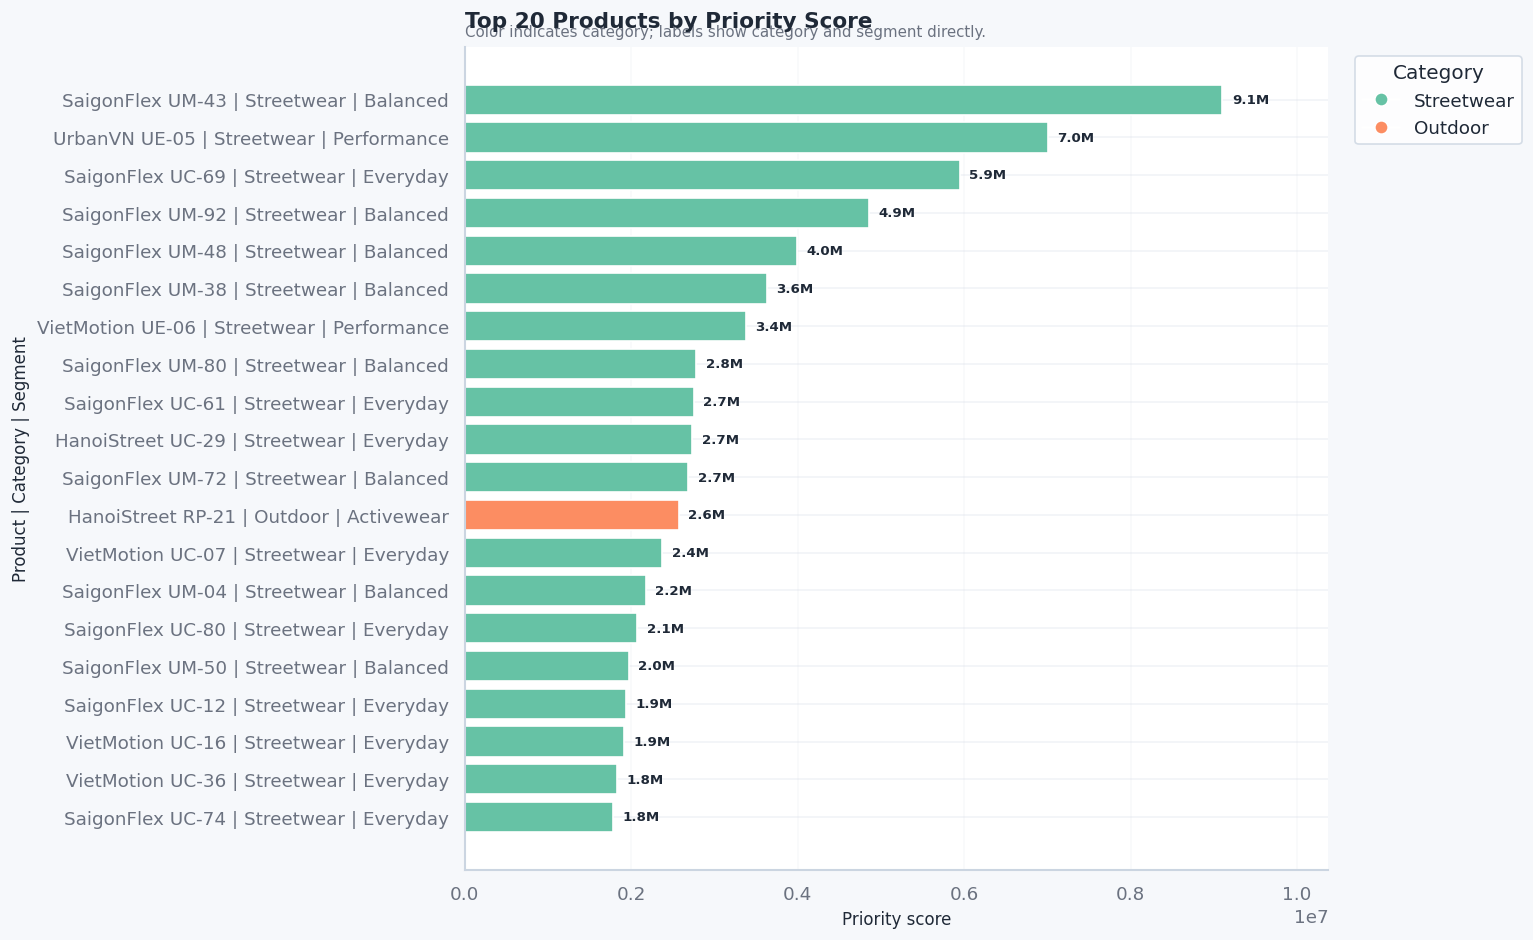

In [32]:
priority_plot = product_priority.head(20).copy()
priority_plot['label'] = priority_plot['product_name'] + ' | ' + priority_plot['category'] + ' | ' + priority_plot['segment']
priority_plot = priority_plot.sort_values('priority_score', ascending=True)
category_colors = dict(zip(priority_plot['category'].unique(), sns.color_palette('Set2', n_colors=priority_plot['category'].nunique())))
colors = priority_plot['category'].map(category_colors)

fig, ax = plt.subplots(figsize=(13, 8), facecolor=BACKGROUND)
ax.barh(priority_plot['label'], priority_plot['priority_score'], color=colors, edgecolor='white')
clean_axis(ax, 'Top 20 Products by Priority Score', 'Priority score', 'Product | Category | Segment', subtitle='Color indicates category; labels show category and segment directly.')
label_hbars(ax, fmt=lambda v: fmt_currency(v, 1), fontsize=8)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, label=cat, markersize=8) for cat, color in category_colors.items()]
ax.legend(handles=handles, title='Category', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, edgecolor='#CBD5E1')
plt.tight_layout()
plt.show()


In [33]:
top_priority = product_priority.iloc[0]
top_priority_10_lost = product_priority.head(10)['lost_revenue'].sum()
share_top10_lost = top_priority_10_lost / total_lost_revenue if total_lost_revenue else np.nan

priority_takeaways = pd.DataFrame({
    'Metric': [
        'Top priority SKU',
        'Top SKU priority score',
        'Top SKU lost revenue',
        'Top SKU stockout rate',
        'Top SKU margin rate',
        'Top 10 lost revenue share'
    ],
    'Value': [
        top_priority['product_name'],
        fmt_currency(top_priority['priority_score']),
        fmt_currency(top_priority['lost_revenue']),
        fmt_percent(top_priority['stockout_rate']),
        fmt_percent(top_priority['avg_margin_rate']),
        fmt_percent(share_top10_lost)
    ]
})

display(priority_takeaways)


,Metric,Value
0,Top priority SKU,SaigonFlex UM-43
1,Top SKU priority score,9.1M
2,Top SKU lost revenue,12.4M
3,Top SKU stockout rate,70.7%
4,Top SKU margin rate,43.0%
5,Top 10 lost revenue share,11.0%


### **Prescriptive Insight: Priority Score**

Bảng này không chỉ xếp hạng theo “mất doanh thu nhiều nhất”, mà ưu tiên SKU theo 3 câu hỏi: mất bao nhiêu doanh thu, biên lợi nhuận có đáng cứu không, và tình trạng thiếu hàng có lặp lại thường xuyên không. Vì vậy **SaigonFlex UM-43** đứng đầu với **12.4M lost revenue**, **70.7% stockout rate**, **43.0% margin rate** và **priority score 9.1M**.

Điểm đáng chú ý là **SaigonFlex UM-92** có lost revenue cao hơn (**19.1M**) nhưng margin chỉ **15.3%**, nên mức ưu tiên thấp hơn UM-43 và UrbanVN UE-05. Điều này giúp business tránh ra quyết định chỉ dựa vào doanh thu bị mất, vì không phải SKU nào mất doanh thu lớn cũng đáng bơm thêm vốn tồn kho.

Biểu đồ cũng cho thấy Top 20 gần như bị chi phối bởi **Streetwear**, chỉ có một SKU Outdoor là **HanoiStreet RP-21**. Nghĩa là vấn đề không nằm rải đều toàn danh mục, mà tập trung vào một nhóm SKU Streetwear cụ thể, đặc biệt các dòng SaigonFlex, UrbanVN và VietMotion.

Tuy nhiên, nhiều SKU ưu tiên cao vẫn có `avg_days_of_supply` rất lớn, ví dụ SaigonFlex UM-43 đạt **4,786.5 ngày**. Đây là tín hiệu quan trọng: vấn đề có thể không phải “thiếu hàng tổng thể”, mà là hàng đang sai thời điểm, sai tháng hoặc sai phân bổ. Vì vậy không nên nhập thêm hàng đại trà, mà cần kiểm tra lịch replenishment, tồn kho theo tháng và các giai đoạn bị stockout.

**Khuyến nghị hành động:** bắt đầu pilot với Top 10-20 SKU có priority score cao nhất, kiểm tra tồn kho thực tế, lead time, lịch nhập hàng và các tháng bị stockout. Với SKU margin cao và stockout lặp lại, tăng safety stock hoặc đặt hàng sớm hơn. Với SKU vừa stockout cao vừa days of supply cao, ưu tiên sửa timing và allocation trước khi tăng mua hàng.

**Kết luận:** Priority Score cho thấy doanh nghiệp nên tối ưu tồn kho theo từng SKU có ROI cao, không nên tăng tồn kho toàn bộ danh mục.


### **11.1 [Prescriptive] Action ROI for Top Priority SKUs**

Phần này biến danh sách ưu tiên thành câu hỏi thực tế hơn: nếu bổ sung hàng cho các mã ưu tiên, cần bao nhiêu vốn và có thể thu hồi bao nhiêu lợi nhuận?

Vì chưa có dữ liệu lead time và purchase order thực tế, phần này dùng COGS làm proxy cho vốn cần bỏ thêm. Đây là ước tính để ra quyết định pilot, không phải ngân sách mua hàng chính thức.


In [34]:
RECOVERY_BASE = 0.70
roi_base = (
    inv_lost.groupby(['product_id', 'product_name', 'category', 'segment'])
    .agg(
        lost_units=('lost_units_est', 'sum'),
        lost_revenue=('lost_revenue_est', 'sum'),
        lost_margin=('lost_margin_est', 'sum'),
        avg_cogs=('cogs', 'mean'),
        avg_price=('price', 'mean'),
        avg_margin_rate=('gross_margin_rate', 'mean'),
        stockout_rate=('stockout_flag', 'mean'),
        avg_days_of_supply=('days_of_supply', 'mean')
    )
    .reset_index()
    .merge(product_priority[['product_id', 'priority_score_adjusted']], on='product_id', how='left')
)

roi_top_skus = roi_base.sort_values('priority_score_adjusted', ascending=False).head(20).copy()
for recovery in [0.50, 0.70, 0.90]:
    roi_top_skus[f'recoverable_units_{int(recovery*100)}'] = roi_top_skus['lost_units'] * recovery
    roi_top_skus[f'working_capital_{int(recovery*100)}'] = roi_top_skus[f'recoverable_units_{int(recovery*100)}'] * roi_top_skus['avg_cogs']
    roi_top_skus[f'recovered_revenue_{int(recovery*100)}'] = roi_top_skus[f'recoverable_units_{int(recovery*100)}'] * roi_top_skus['avg_price']
    roi_top_skus[f'recovered_margin_{int(recovery*100)}'] = roi_top_skus['lost_margin'] * recovery

roi_top_skus['roi_proxy_70'] = np.where(
    roi_top_skus['working_capital_70'] > 0,
    roi_top_skus['recovered_margin_70'] / roi_top_skus['working_capital_70'],
    np.nan
)
roi_top_skus['recommended_decision'] = np.select(
    [roi_top_skus['roi_proxy_70'] >= 0.35, roi_top_skus['roi_proxy_70'] >= 0.20],
    ['Pilot now', 'Monitor / validate stock',],
    default='Avoid auto-replenishment'
)
roi_top_skus['action_type'] = np.where(
    roi_top_skus['avg_days_of_supply'] > roi_top_skus['avg_days_of_supply'].median(),
    'Audit allocation/timing before buying more',
    'Consider controlled safety stock increase'
)

roi_display_cols = [
    'product_name', 'category', 'segment', 'action_type', 'lost_revenue', 'working_capital_70',
    'recovered_revenue_70', 'recovered_margin_70', 'roi_proxy_70', 'recommended_decision'
]
roi_display = roi_top_skus[roi_display_cols].copy()
for c in ['lost_revenue', 'working_capital_70', 'recovered_revenue_70', 'recovered_margin_70']:
    roi_display[c] = roi_display[c].map(fmt_currency)
roi_display['roi_proxy_70'] = roi_display['roi_proxy_70'].map(lambda v: fmt_number(v, 2))

display(roi_display)
roi_top_skus.to_csv(OUTPUT_DIR / 'prescriptive_roi_top_skus.csv', index=False)


,product_name,category,segment,action_type,lost_revenue,working_capital_70,recovered_revenue_70,recovered_margin_70,roi_proxy_70,recommended_decision
279,SaigonFlex UM-43,Streetwear,Balanced,Audit allocation/timing before buying more,12.4M,4.9M,8.7M,3.7M,0.75,Pilot now
1403,UrbanVN UE-05,Streetwear,Performance,Audit allocation/timing before buying more,9.3M,3.5M,6.5M,3.0M,0.86,Pilot now
418,SaigonFlex UC-69,Streetwear,Everyday,Audit allocation/timing before buying more,10.7M,5.0M,7.5M,2.4M,0.48,Pilot now
315,SaigonFlex UM-92,Streetwear,Balanced,Audit allocation/timing before buying more,19.1M,11.3M,13.3M,2.0M,0.18,Avoid auto-replenishment
282,SaigonFlex UM-48,Streetwear,Balanced,Consider controlled safety stock increase,5.6M,2.2M,3.9M,1.7M,0.75,Pilot now
275,SaigonFlex UM-38,Streetwear,Balanced,Consider controlled safety stock increase,5.0M,2.0M,3.5M,1.5M,0.75,Pilot now
1570,VietMotion UE-06,Streetwear,Performance,Consider controlled safety stock increase,9.6M,5.3M,6.7M,1.4M,0.27,Monitor / validate stock
300,SaigonFlex UM-72,Streetwear,Balanced,Consider controlled safety stock increase,3.9M,1.6M,2.7M,1.2M,0.74,Pilot now
512,HanoiStreet RP-21,Outdoor,Activewear,Consider controlled safety stock increase,3.3M,1.2M,2.3M,1.1M,0.91,Pilot now
637,HanoiStreet UC-29,Streetwear,Everyday,Audit allocation/timing before buying more,3.8M,1.5M,2.7M,1.2M,0.76,Pilot now


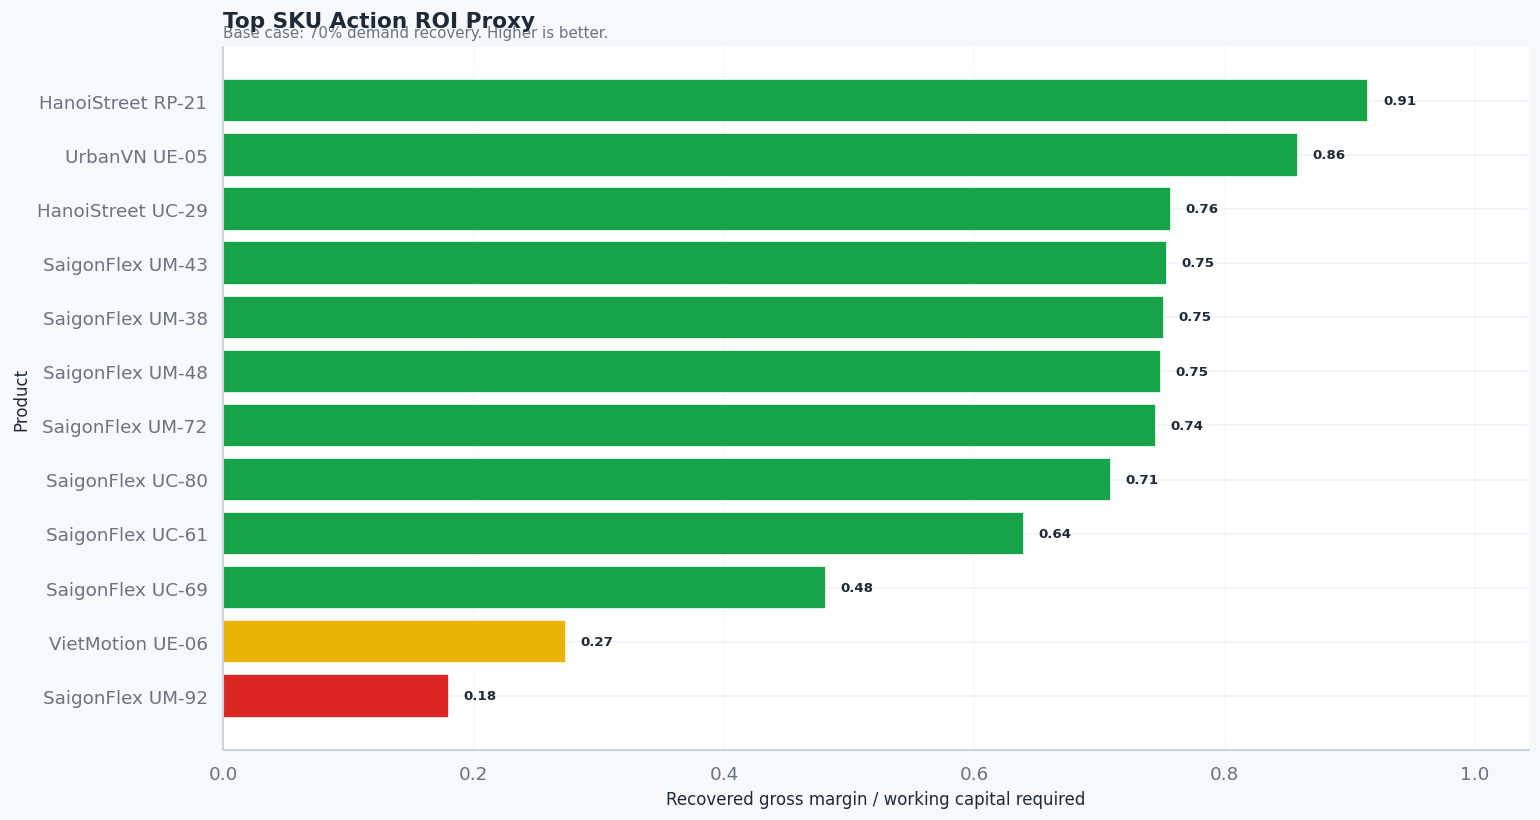

In [35]:
fig, ax = plt.subplots(figsize=(13, 7), facecolor=BACKGROUND)
plot_roi = roi_top_skus.head(12).sort_values('roi_proxy_70')
colors = plot_roi['recommended_decision'].map({'Pilot now': PALETTE['stable'], 'Monitor / validate stock': PALETTE['warning'], 'Avoid auto-replenishment': PALETTE['volatile']})
ax.barh(plot_roi['product_name'], plot_roi['roi_proxy_70'], color=colors, edgecolor='white')
clean_axis(ax, 'Top SKU Action ROI Proxy', 'Recovered gross margin / working capital required', 'Product', subtitle='Base case: 70% demand recovery. Higher is better.')
label_hbars(ax, fmt=lambda v: fmt_number(v, 2), fontsize=8)
plt.tight_layout()
plt.show()


#### **Prescriptive Insight: Action ROI for Top Priority SKUs**

Bảng ROI giúp chuyển câu hỏi từ “SKU nào đang mất doanh thu nhiều?” sang “SKU nào đáng bỏ thêm vốn để xử lý trước?”. Ở đây, ROI proxy được hiểu đơn giản là: nếu doanh nghiệp bỏ thêm vốn tồn kho, thì có thể thu hồi được bao nhiêu gross margin. Chỉ số càng cao thì hành động càng đáng ưu tiên.

Điểm đáng chú ý nhất là **HanoiStreet RP-21** có ROI proxy cao nhất (**0.91**) dù không phải SKU có lost revenue lớn nhất. Điều này nghĩa là mỗi 1 đồng vốn bổ sung cho SKU này có khả năng tạo lại khoảng 0.91 đồng gross margin. Đây là ứng viên rất tốt để pilot vì vốn cần thêm chỉ khoảng **1.2M**, nhưng có thể thu hồi **1.1M gross margin** trong base case 70% demand recovery.

Ngược lại, **SaigonFlex UM-92** có lost revenue rất lớn (**19.1M**) nhưng ROI proxy chỉ **0.18**. SKU này nhìn qua có vẻ hấp dẫn vì mất doanh thu cao, nhưng biên lợi nhuận thấp và vốn cần bổ sung lớn (**11.3M**) khiến hiệu quả tài chính kém. Vì vậy quyết định đúng không phải là tự động nhập thêm hàng, mà nên **tránh auto-replenishment** và kiểm tra lại demand, margin, tồn kho theo tháng trước khi hành động.

Nhóm nên triển khai trước gồm các SKU có ROI proxy tốt và quyết định là **Pilot now**, như **HanoiStreet RP-21**, **UrbanVN UE-05**, **SaigonFlex UM-43**, **SaigonFlex UM-38**, **SaigonFlex UM-48** và **HanoiStreet UC-29**. Đây là nhóm vừa có rủi ro mất doanh thu, vừa có khả năng thu hồi margin đủ tốt để biện minh cho việc tăng safety stock hoặc chỉnh lịch nhập hàng.

Một điểm quan trọng là nhiều SKU vẫn được gắn action type là **Audit allocation/timing before buying more**. Điều này có nghĩa business không nên hiểu bảng này là “mua thêm hàng ngay”. Với các SKU có dấu hiệu vừa thiếu hàng vừa dư hàng ở các thời điểm khác nhau, bước đầu tiên phải là kiểm tra phân bổ tồn kho, lịch nhập hàng, lead time và tháng nào xảy ra stockout.

**Khuyến nghị hành động:** triển khai pilot 30 ngày với nhóm ROI cao, vốn bổ sung thấp và decision là “Pilot now”; nhóm ROI thấp như **SaigonFlex UM-92** hoặc cần vốn lớn nên đưa vào diện kiểm tra thêm thay vì tự động bổ sung tồn kho.

**Kết luận:** Prescriptive analysis cho thấy tối ưu tồn kho không phải là tăng hàng cho SKU mất doanh thu cao nhất, mà là chọn SKU có khả năng thu hồi margin tốt nhất trên mỗi đồng vốn bỏ thêm.


## **12. [Prescriptive] Kịch bản thu hồi doanh thu: simple upside estimate**

Phần này giữ lại cách tính đơn giản ban đầu để tạo cảm giác về quy mô cơ hội. Tuy nhiên, cần nói rõ đây là **ước tính tuyến tính đơn giản**, không phải forecast.

Giảm thiếu hàng 20% không tự động đồng nghĩa thu hồi 20% doanh thu bị mất. Một phần khách hàng có thể đã mua sản phẩm khác, rời đi, hoặc nhu cầu đã mất vĩnh viễn. Vì vậy phần sau sẽ thêm scenario thực tế hơn với recovery rate và cannibalization.

In [36]:
scenario_stockout = pd.DataFrame({'Mức giảm stockout giả định': [0.10, 0.20, 0.30, 0.40]})
scenario_stockout['Recovered revenue estimate'] = total_lost_revenue * scenario_stockout['Mức giảm stockout giả định']
scenario_stockout['Recovered gross margin estimate'] = total_lost_margin * scenario_stockout['Mức giảm stockout giả định']
display(scenario_stockout)


,Mức giảm stockout giả định,Recovered revenue estimate,Recovered gross margin estimate
0,0.1000,"79,987,348.3238","16,187,844.8669"
1,0.2000,"159,974,696.6477","32,375,689.7338"
2,0.3000,"239,962,044.9715","48,563,534.6008"
3,0.4000,"319,949,393.2954","64,751,379.4677"


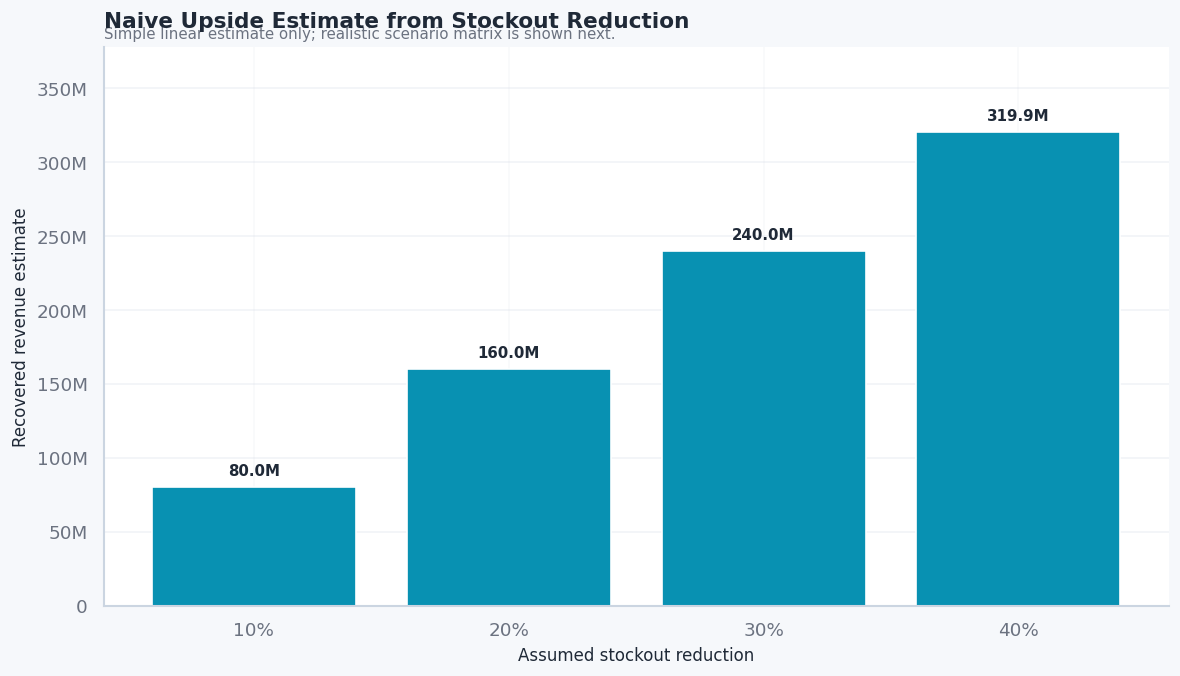

In [37]:
fig, ax = plt.subplots(figsize=(10, 5.8), facecolor=BACKGROUND)
plot_df = scenario_stockout.copy()
ax.bar(
    plot_df['Mức giảm stockout giả định'].map(lambda v: f'{v:.0%}'),
    plot_df['Recovered revenue estimate'],
    color=PALETTE['accent'],
    edgecolor='white'
)
clean_axis(
    ax,
    'Naive Upside Estimate from Stockout Reduction',
    'Assumed stockout reduction',
    'Recovered revenue estimate',
    subtitle='Simple linear estimate only; realistic scenario matrix is shown next.'
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))
label_vbars(ax, fmt=lambda v: fmt_currency(v, 1))
plt.tight_layout()
plt.show()


In [38]:
scenario_20 = scenario_stockout.loc[scenario_stockout['Mức giảm stockout giả định'] == 0.20].iloc[0]
scenario_40 = scenario_stockout.loc[scenario_stockout['Mức giảm stockout giả định'] == 0.40].iloc[0]

scenario_takeaways = pd.DataFrame({
    'Scenario': ['20% stockout reduction', '40% stockout reduction'],
    'Recovered revenue': [
        fmt_currency(scenario_20['Recovered revenue estimate']),
        fmt_currency(scenario_40['Recovered revenue estimate'])
    ],
    'Recovered gross margin': [
        fmt_currency(scenario_20['Recovered gross margin estimate']),
        fmt_currency(scenario_40['Recovered gross margin estimate'])
    ],
    'Use case': [
        'Base case for pilot business case',
        'Upside case if intervention scales successfully'
    ]
})

display(scenario_takeaways)


,Scenario,Recovered revenue,Recovered gross margin,Use case
0,20% stockout reduction,160.0M,32.4M,Base case for pilot business case
1,40% stockout reduction,319.9M,64.8M,Upside case if intervention scales successfully


### Nhận xét về kịch bản tài chính

Nếu giảm thiếu hàng **20%**, doanh nghiệp có thể thu hồi khoảng **160.0M doanh thu** và **32.4M lợi nhuận gộp**. Nếu giảm **40%**, doanh thu có thể phục hồi khoảng **319.9M**.

Nhưng không nên hiểu rằng giảm thiếu hàng bằng mọi giá là tốt. Nếu để giảm thiếu hàng mà phải nhập thêm quá nhiều, làm tăng chi phí lưu kho hoặc tạo thêm dư hàng, lợi nhuận thực tế có thể không cải thiện.

**Việc nên làm:** dùng kịch bản 20% làm pilot ban đầu trên nhóm sản phẩm ưu tiên. Sau khi đo hiệu quả thực tế, mới quyết định mở rộng.

**Kết luận:** Giảm thiếu hàng nên được triển khai như một thử nghiệm có đo lợi ích - chi phí, không phải tăng tồn kho trên diện rộng.

**Executive takeaway:** Base case giảm stockout 20% tạo upside khoảng **160.0M revenue** và **32.4M gross margin**. Đây là đủ lớn để chạy pilot, nhưng chỉ nên mở rộng nếu gross margin phục hồi lớn hơn chi phí tồn kho tăng thêm.

### 12.1 [Prescriptive] Realistic Scenario Matrix

Phần này sửa điểm yếu của kịch bản tuyến tính. Trong thực tế, không phải toàn bộ nhu cầu bị mất sẽ quay lại.

Ba giả định được đưa vào:

- **Stockout reduction:** doanh nghiệp giảm thiếu hàng được bao nhiêu phần trăm.
- **Demand recovery:** trong phần nhu cầu bị mất, bao nhiêu phần thật sự quay lại mua.
- **Cannibalization:** bao nhiêu phần doanh thu thu hồi chỉ là chuyển từ sản phẩm khác trong cùng danh mục, không phải doanh thu mới hoàn toàn.

Base case sử dụng: giảm stockout 20%, thu hồi 70% nhu cầu, cannibalization 10%.


In [39]:
stockout_reductions = [0.10, 0.20, 0.30, 0.40]
demand_recovery_rates = [0.50, 0.70, 0.90]
cannibalization_rates = [0.00, 0.10, 0.20]

scenario_rows = []
for reduction in stockout_reductions:
    for recovery in demand_recovery_rates:
        for cannibalization in cannibalization_rates:
            recoverable_units = inv_lost['lost_units_est'].sum() * reduction * recovery
            gross_recovered_revenue = total_lost_revenue * reduction * recovery
            net_recovered_revenue = gross_recovered_revenue * (1 - cannibalization)
            working_capital_required = (inv_lost['lost_units_est'] * reduction * recovery * inv_lost['cogs']).sum()
            net_recovered_margin = total_lost_margin * reduction * recovery * (1 - cannibalization)
            scenario_rows.append({
                'stockout_reduction': reduction,
                'demand_recovery_rate': recovery,
                'cannibalization_rate': cannibalization,
                'recoverable_units': recoverable_units,
                'gross_recovered_revenue': gross_recovered_revenue,
                'net_recovered_revenue': net_recovered_revenue,
                'working_capital_required': working_capital_required,
                'net_recovered_margin': net_recovered_margin
            })

realistic_scenario_matrix = pd.DataFrame(scenario_rows)
base_case = realistic_scenario_matrix[
    (realistic_scenario_matrix['stockout_reduction'] == 0.20) &
    (realistic_scenario_matrix['demand_recovery_rate'] == 0.70) &
    (realistic_scenario_matrix['cannibalization_rate'] == 0.10)
].iloc[0]

scenario_display = realistic_scenario_matrix.copy()
for c in ['gross_recovered_revenue', 'net_recovered_revenue', 'working_capital_required', 'net_recovered_margin']:
    scenario_display[c] = scenario_display[c].map(fmt_currency)
for c in ['stockout_reduction', 'demand_recovery_rate', 'cannibalization_rate']:
    scenario_display[c] = scenario_display[c].map(fmt_percent)

display(scenario_display.head(12))
display(pd.DataFrame([base_case]))
realistic_scenario_matrix.to_csv(OUTPUT_DIR / 'realistic_scenario_matrix.csv', index=False)


,stockout_reduction,demand_recovery_rate,cannibalization_rate,recoverable_units,gross_recovered_revenue,net_recovered_revenue,working_capital_required,net_recovered_margin
0,10.0%,50.0%,0.0%,"7,590.1667",40.0M,40.0M,31.9M,8.1M
1,10.0%,50.0%,10.0%,"7,590.1667",40.0M,36.0M,31.9M,7.3M
2,10.0%,50.0%,20.0%,"7,590.1667",40.0M,32.0M,31.9M,6.5M
3,10.0%,70.0%,0.0%,"10,626.2333",56.0M,56.0M,44.7M,11.3M
4,10.0%,70.0%,10.0%,"10,626.2333",56.0M,50.4M,44.7M,10.2M
5,10.0%,70.0%,20.0%,"10,626.2333",56.0M,44.8M,44.7M,9.1M
6,10.0%,90.0%,0.0%,"13,662.3000",72.0M,72.0M,57.4M,14.6M
7,10.0%,90.0%,10.0%,"13,662.3000",72.0M,64.8M,57.4M,13.1M
8,10.0%,90.0%,20.0%,"13,662.3000",72.0M,57.6M,57.4M,11.7M
9,20.0%,50.0%,0.0%,"15,180.3333",80.0M,80.0M,63.8M,16.2M


,stockout_reduction,demand_recovery_rate,cannibalization_rate,recoverable_units,gross_recovered_revenue,net_recovered_revenue,working_capital_required,net_recovered_margin
13,0.2000,0.7000,0.1000,"21,252.4667","111,982,287.6534","100,784,058.8880","89,319,304.8397","20,396,684.5323"


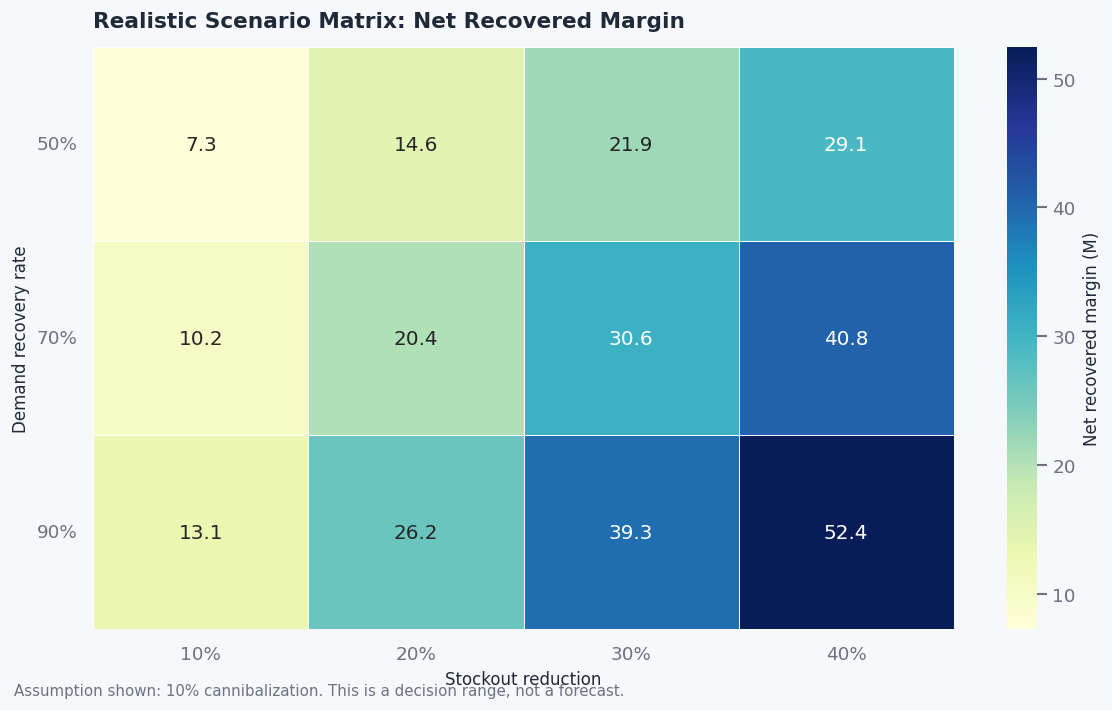

In [40]:
heatmap_data = realistic_scenario_matrix[realistic_scenario_matrix['cannibalization_rate'] == 0.10].pivot(
    index='demand_recovery_rate',
    columns='stockout_reduction',
    values='net_recovered_margin'
)
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BACKGROUND)
sns.heatmap(
    heatmap_data / 1_000_000,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Net recovered margin (M)'},
    ax=ax
)
ax.set_title('Realistic Scenario Matrix: Net Recovered Margin', loc='left', fontsize=13, fontweight='bold')
ax.set_xlabel('Stockout reduction')
ax.set_ylabel('Demand recovery rate')
ax.set_xticklabels([f'{float(t.get_text()):.0%}' for t in ax.get_xticklabels()])
ax.set_yticklabels([f'{float(t.get_text()):.0%}' for t in ax.get_yticklabels()], rotation=0)
fig.text(0.02, 0.02, 'Assumption shown: 10% cannibalization. This is a decision range, not a forecast.', fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()


#### **Prescriptive Insight: Realistic Scenario Matrix**

Bảng scenario này thực tế hơn cách tính tuyến tính đơn giản, vì không giả định rằng cứ giảm stockout bao nhiêu thì thu hồi được đúng bấy nhiêu doanh thu. Trong thực tế, một phần khách đã rời đi, một phần đã mua sản phẩm thay thế, và một phần doanh thu có thể bị “ăn” từ SKU khác trong cùng danh mục. Vì vậy bảng này đưa vào 3 giả định: mức giảm stockout, tỷ lệ demand thật sự thu hồi được, và tỷ lệ cannibalization.

Ở base case, nếu doanh nghiệp giảm stockout **20%**, thu hồi được **70% demand bị mất**, và chịu **10% cannibalization**, thì có thể thu hồi khoảng **112.0M net revenue** và khoảng **20.4M net recovered margin**. Để đạt kịch bản này, doanh nghiệp cần thêm khoảng **21,252 units** và khoảng **89.4M working capital** theo COGS.

Điểm quan trọng là upside thay đổi rất mạnh theo giả định demand recovery. Cùng mức giảm stockout **20%**, nếu chỉ thu hồi được **50% demand**, net margin còn khoảng **14.6M**; nhưng nếu thu hồi được **90% demand**, net margin tăng lên khoảng **26.2M**. Điều này cho thấy rủi ro lớn nhất không chỉ nằm ở vận hành tồn kho, mà còn nằm ở câu hỏi: khách hàng có quay lại mua khi hàng có sẵn hay không.

Heatmap cũng cho thấy kịch bản tốt nhất trong phạm vi giả định là giảm stockout **40%** và thu hồi **90% demand**, tạo khoảng **52.4M net margin**. Tuy nhiên đây không nên được hiểu là forecast chắc chắn. Đây là “decision range” để business biết khoảng lợi ích tài chính có thể đạt được nếu triển khai tốt.

Về mặt ra quyết định, base case **20% stockout reduction / 70% demand recovery / 10% cannibalization** là mức hợp lý để dùng cho pilot, vì đủ tham vọng để tạo tác động tài chính nhưng chưa quá lạc quan. Nếu pilot không chứng minh được demand recovery gần 70%, doanh nghiệp không nên mở rộng bổ sung tồn kho trên diện rộng.

**Khuyến nghị hành động:** dùng base case làm ngưỡng phê duyệt pilot. Nếu chi phí tăng tồn kho, logistics và markdown nhỏ hơn net recovered margin kỳ vọng, có thể triển khai cho nhóm SKU ưu tiên cao. Nếu chi phí vượt lợi ích kỳ vọng, nên chỉ xử lý bằng allocation/timing thay vì tăng tồn kho.

**Kết luận:** Scenario matrix cho thấy stockout reduction có upside rõ ràng, nhưng chỉ đáng đầu tư khi doanh nghiệp kiểm soát được demand recovery và tránh cannibalization quá cao.


## **13. [Prescriptive] Khuyến nghị theo nhóm tồn kho**

Phần này là nơi chuyển toàn bộ phân tích thành hành động.

Điểm quan trọng nhất: các nhóm sản phẩm khác nhau cần cách xử lý khác nhau. Nếu một mã thường xuyên thiếu hàng, có thể cần tăng tồn an toàn. Nếu một mã đang dư hàng, cần giảm nhập hoặc xả hàng. Nếu một mã vừa thiếu vừa dư, cần kiểm tra lại cách dự báo và thời điểm nhập.

Mục tiêu là tạo một playbook đơn giản để đội inventory biết nên làm gì với từng nhóm sản phẩm.

In [41]:
tradeoff_by_group = (
    matrix_df
    .groupby('inventory_group')
    .agg(
        products=('product_id', 'nunique'),
        avg_stockout_rate=('stockout_rate', 'mean'),
        avg_overstock_rate=('overstock_rate', 'mean'),
        total_lost_revenue=('lost_revenue', 'sum'),
        avg_inventory_value=('inventory_value', 'mean'),
        total_units_sold=('total_units_sold', 'sum')
    )
    .reset_index()
    .sort_values('total_lost_revenue', ascending=False)
)

action_map = {
    'Thiếu hàng thường xuyên': 'Tăng Dynamic ROP, safety stock và kiểm tra lead time',
    'Dư hàng': 'Giảm replenishment, markdown hoặc bundle để giải phóng vốn',
    'Tồn kho biến động': 'Rà soát forecast, replenishment cycle và allocation theo kênh/kho',
    'Ổn định': 'Giữ policy hiện tại, theo dõi dashboard định kỳ'
}
tradeoff_by_group['recommended_action'] = tradeoff_by_group['inventory_group'].map(action_map)

display(tradeoff_by_group)
tradeoff_by_group.to_csv(OUTPUT_DIR / 'tradeoff_by_group.csv', index=False)


,inventory_group,products,avg_stockout_rate,avg_overstock_rate,total_lost_revenue,avg_inventory_value,total_units_sold,recommended_action
0,Dư hàng,452,0.6155,0.8717,"397,886,244.4781","735,891.9541",500869,"Giảm replenishment, markdown hoặc bundle để giải phóng vốn"
2,Tồn kho biến động,360,0.7416,0.8671,"290,237,998.0219","579,916.8401",343573,"Rà soát forecast, replenishment cycle và allocation theo kênh/kho"
1,Thiếu hàng thường xuyên,449,0.8336,0.2315,"71,012,278.4795","89,259.8724",47981,"Tăng Dynamic ROP, safety stock và kiểm tra lead time"
3,Ổn định,363,0.5111,0.2562,"40,736,962.2589","89,398.1913",36451,"Giữ policy hiện tại, theo dõi dashboard định kỳ"


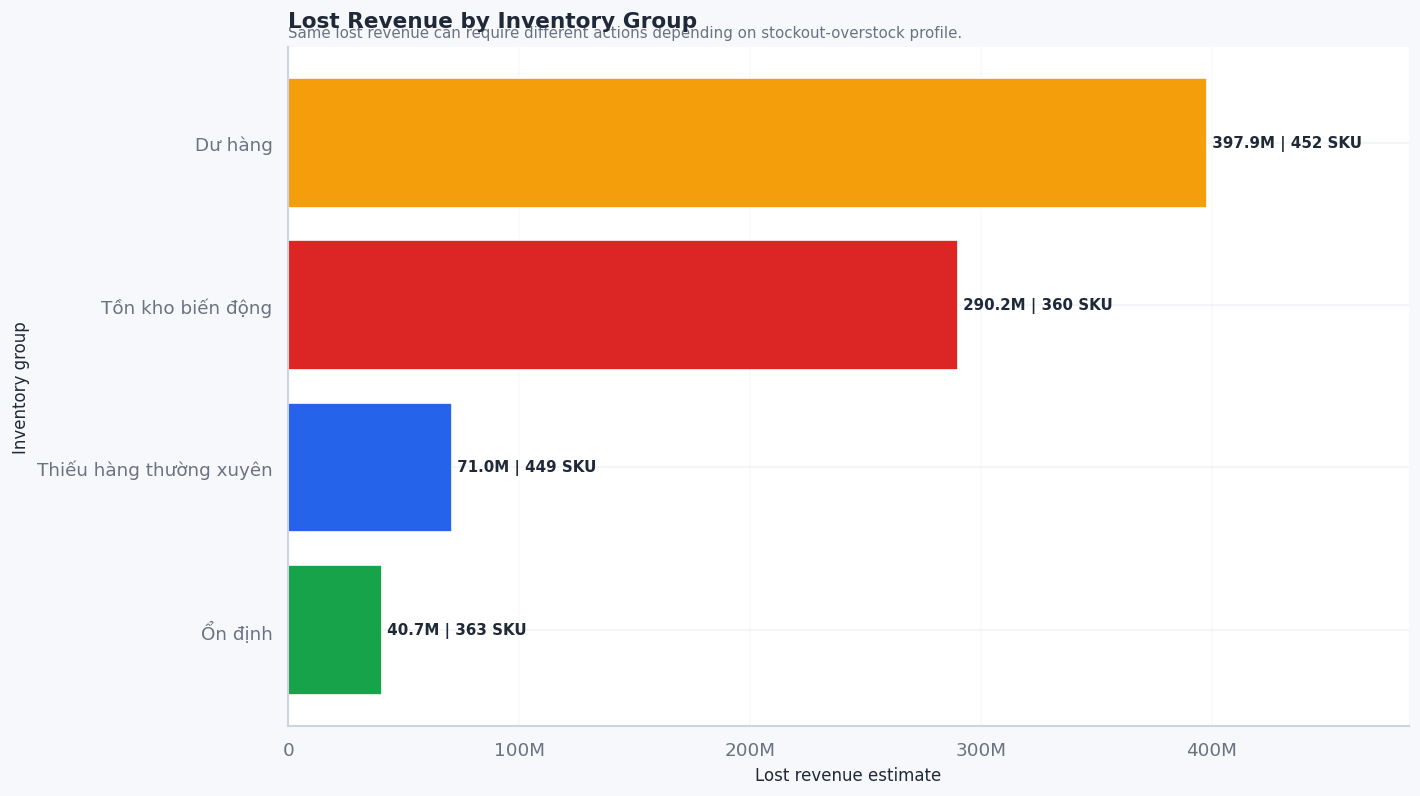

In [42]:
fig, ax = plt.subplots(figsize=(12, 6.8), facecolor=BACKGROUND)
plot_df = tradeoff_by_group.sort_values('total_lost_revenue', ascending=True).copy()
colors = plot_df['inventory_group'].map(GROUP_COLORS)
ax.barh(plot_df['inventory_group'], plot_df['total_lost_revenue'], color=colors, edgecolor='white', linewidth=1.0)
clean_axis(
    ax,
    'Lost Revenue by Inventory Group',
    'Lost revenue estimate',
    'Inventory group',
    subtitle='Same lost revenue can require different actions depending on stockout-overstock profile.'
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))
ax.margins(x=0.22)
for patch, (_, row) in zip(ax.patches, plot_df.iterrows()):
    label = f" {fmt_currency(row['total_lost_revenue'])} | {fmt_number(row['products'])} SKU"
    ax.text(patch.get_width(), patch.get_y() + patch.get_height() / 2, label, va='center', ha='left', fontsize=9, color=TEXT, weight='bold')
plt.tight_layout()
plt.show()


In [43]:
top_tradeoff_group = tradeoff_by_group.iloc[0]

tradeoff_action_summary = tradeoff_by_group[[
    'inventory_group',
    'products',
    'avg_stockout_rate',
    'avg_overstock_rate',
    'total_lost_revenue',
    'recommended_action'
]].copy()
tradeoff_action_summary['avg_stockout_rate'] = tradeoff_action_summary['avg_stockout_rate'].map(fmt_percent)
tradeoff_action_summary['avg_overstock_rate'] = tradeoff_action_summary['avg_overstock_rate'].map(fmt_percent)
tradeoff_action_summary['total_lost_revenue'] = tradeoff_action_summary['total_lost_revenue'].map(fmt_currency)

display(tradeoff_action_summary)


,inventory_group,products,avg_stockout_rate,avg_overstock_rate,total_lost_revenue,recommended_action
0,Dư hàng,452,61.6%,87.2%,397.9M,"Giảm replenishment, markdown hoặc bundle để giải phóng vốn"
2,Tồn kho biến động,360,74.2%,86.7%,290.2M,"Rà soát forecast, replenishment cycle và allocation theo kênh/kho"
1,Thiếu hàng thường xuyên,449,83.4%,23.1%,71.0M,"Tăng Dynamic ROP, safety stock và kiểm tra lead time"
3,Ổn định,363,51.1%,25.6%,40.7M,"Giữ policy hiện tại, theo dõi dashboard định kỳ"


### **Nhận xét và khuyến nghị hành động**

Nhóm tạo doanh thu bị mất lớn nhất lại là nhóm **Dư hàng**, với **397.9M** trên **452 mã sản phẩm**. Điều này cho thấy không thể nhìn “dư hàng” một cách đơn giản. Một mã có thể dư ở một số tháng nhưng vẫn thiếu vào thời điểm nhu cầu tăng.

Nếu công ty nhập thêm hàng cho cả nhóm này, vốn bị khóa có thể tăng. Nhưng nếu markdown toàn bộ nhóm này, công ty có thể xả nhầm cả những mã vẫn còn nhu cầu.

**Việc nên làm:** xử lý theo nhóm nguyên nhân:

- **Nhóm thiếu hàng thường xuyên**: tăng tồn an toàn có kiểm soát.
- **Nhóm dư hàng**: giảm nhập hoặc xả hàng có chọn lọc.
- **Nhóm biến động**: xem lại dự báo, lịch nhập và phân bổ hàng.
- **Nhóm ổn định**: giữ chính sách hiện tại và theo dõi.

**Kết luận:** Cách làm đúng không phải một chính sách chung, mà là hành động khác nhau cho từng nhóm tồn kho.

### **13.1 [Prescriptive] 30/60/90-Day Action Plan**

Một kế hoạch hành động tốt cần nói rõ ai làm gì, trong bao lâu, và đo bằng KPI nào. Phần này chuyển recommendation thành lộ trình triển khai.


In [44]:
action_plan_30_60_90 = pd.DataFrame({
    'Timeline': ['0-30 ngày', '31-60 ngày', '61-90 ngày'],
    'Owner': ['Inventory Planning + BI', 'Merchandising + Procurement', 'BI + Finance + Operations'],
    'Action': [
        'Audit top priority SKUs, validate stock on hand, pending PO, lead time, and campaign calendar.',
        'Adjust safety stock for shortage SKUs; markdown or bundle selected overstock SKUs.',
        'Deploy monthly inventory dashboard and review pilot ROI before scaling.'
    ],
    'KPI theo dõi': [
        'Top SKU stockout days, fill rate, available stock, pending PO coverage.',
        'Lost revenue estimate, inventory value locked, days of supply by SKU group.',
        'Recovered margin, working capital increase, SKU movement across inventory groups.'
    ],
    'Decision gate': [
        'Approve pilot SKU list and capital cap.',
        'Continue only if recovered margin is above incremental inventory cost.',
        'Scale policy only if pilot improves margin without increasing overstock materially.'
    ]
})

display(action_plan_30_60_90)


,Timeline,Owner,Action,KPI theo dõi,Decision gate
0,0-30 ngày,Inventory Planning + BI,"Audit top priority SKUs, validate stock on hand, pending PO, lead time, and campaign calendar.","Top SKU stockout days, fill rate, available stock, pending PO coverage.",Approve pilot SKU list and capital cap.
1,31-60 ngày,Merchandising + Procurement,Adjust safety stock for shortage SKUs; markdown or bundle selected overstock SKUs.,"Lost revenue estimate, inventory value locked, days of supply by SKU group.",Continue only if recovered margin is above incremental inventory cost.
2,61-90 ngày,BI + Finance + Operations,Deploy monthly inventory dashboard and review pilot ROI before scaling.,"Recovered margin, working capital increase, SKU movement across inventory groups.",Scale policy only if pilot improves margin without increasing overstock materially.


#### **Nhận xét: Prescriptive phải có người chịu trách nhiệm và mốc thời gian**

Nếu chỉ nói “tối ưu tồn kho”, recommendation vẫn còn chung chung. Lộ trình 30/60/90 ngày giúp biến phân tích thành kế hoạch vận hành.

30 ngày đầu nên tập trung xác minh dữ liệu và chọn SKU pilot. 60 ngày tiếp theo mới điều chỉnh safety stock hoặc markdown. Sau 90 ngày cần đo ROI trước khi mở rộng.

**Kết luận:** Không nên rollout toàn bộ ngay; nên pilot có giới hạn vốn, đo ROI rồi mới mở rộng.


## **14. [Advanced Diagnostic] Cross-table Checks: Promotion, Traffic, Returns**

Phần này thêm các góc nhìn ngoài bảng tồn kho để tăng tính sáng tạo của EDA. Mục tiêu không phải chứng minh quan hệ nhân quả tuyệt đối, mà là kiểm tra xem promotion, traffic và returns có liên quan đến vấn đề tồn kho không.

Ba câu hỏi được kiểm tra:

1. Tháng có promotion có làm stockout hoặc lost revenue tăng không?
2. Tháng traffic cao có trùng với lost revenue cao không?
3. Hàng dư có đến từ return rate cao không?


In [45]:
promotions = pd.read_csv(DATA_DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])
web_traffic = pd.read_csv(DATA_DIR / 'web_traffic.csv', parse_dates=['date'])
returns = pd.read_csv(DATA_DIR / 'returns.csv', low_memory=False)
order_items = pd.read_csv(DATA_DIR / 'order_items.csv', low_memory=False)

# 1) Promotion overlap at category-month level.
inv_cross = inv_lost.copy()
inv_cross['year_month_period'] = inv_cross['snapshot_date'].dt.to_period('M')
inv_cross['month_start'] = inv_cross['year_month_period'].dt.to_timestamp()
inv_cross['month_end'] = inv_cross['year_month_period'].dt.to_timestamp('M')

promo_rows = []
for _, row in inv_cross[['year_month_period', 'month_start', 'month_end', 'category']].drop_duplicates().iterrows():
    active = promotions[(promotions['start_date'] <= row['month_end']) & (promotions['end_date'] >= row['month_start'])]
    active = active[
        active['applicable_category'].isna() |
        (active['applicable_category'].astype(str).str.lower() == str(row['category']).lower())
    ]
    promo_rows.append({
        'year_month_period': row['year_month_period'],
        'category': row['category'],
        'promo_active': len(active) > 0,
        'active_promos': len(active),
        'avg_discount': active['discount_value'].mean() if len(active) else 0
    })
promo_month_category = pd.DataFrame(promo_rows)

inv_promo = inv_cross.merge(promo_month_category, on=['year_month_period', 'category'], how='left')
promo_impact = (
    inv_promo.groupby('promo_active')
    .agg(
        records=('product_id', 'size'),
        stockout_rate=('stockout_flag', 'mean'),
        overstock_rate=('overstock_flag', 'mean'),
        lost_revenue=('lost_revenue_est', 'sum'),
        units_sold=('units_sold', 'sum')
    )
    .reset_index()
)

# 2) Web traffic at month level.
monthly_inventory = (
    inv_lost.assign(year_month=inv_lost['snapshot_date'].dt.to_period('M').astype(str))
    .groupby('year_month')
    .agg(stockout_rate=('stockout_flag', 'mean'), lost_revenue=('lost_revenue_est', 'sum'), units_sold=('units_sold', 'sum'))
    .reset_index()
)
monthly_traffic = (
    web_traffic.assign(year_month=web_traffic['date'].dt.to_period('M').astype(str))
    .groupby('year_month')
    .agg(sessions=('sessions', 'sum'), unique_visitors=('unique_visitors', 'sum'), page_views=('page_views', 'sum'))
    .reset_index()
)
traffic_inventory = monthly_inventory.merge(monthly_traffic, on='year_month', how='inner')
traffic_threshold = traffic_inventory['sessions'].quantile(0.75)
traffic_inventory['traffic_group'] = np.where(traffic_inventory['sessions'] >= traffic_threshold, 'High traffic months', 'Normal traffic months')
traffic_impact = (
    traffic_inventory.groupby('traffic_group')
    .agg(months=('year_month', 'nunique'), avg_stockout_rate=('stockout_rate', 'mean'), lost_revenue=('lost_revenue', 'sum'), units_sold=('units_sold', 'sum'), avg_sessions=('sessions', 'mean'))
    .reset_index()
)
traffic_lost_corr = traffic_inventory['sessions'].corr(traffic_inventory['lost_revenue'])
traffic_stockout_corr = traffic_inventory['sessions'].corr(traffic_inventory['stockout_rate'])

# 3) Returns vs overstock at product level.
returns_product = returns.groupby('product_id').agg(return_quantity=('return_quantity', 'sum'), refund_amount=('refund_amount', 'sum')).reset_index()
ordered_product = order_items.groupby('product_id').agg(ordered_quantity=('quantity', 'sum')).reset_index()
return_rate_product = ordered_product.merge(returns_product, on='product_id', how='left').fillna({'return_quantity': 0, 'refund_amount': 0})
return_rate_product['return_rate_qty'] = np.where(return_rate_product['ordered_quantity'] > 0, return_rate_product['return_quantity'] / return_rate_product['ordered_quantity'], np.nan)
returns_inventory = matrix_df.merge(return_rate_product[['product_id', 'return_rate_qty', 'return_quantity']], on='product_id', how='left')
returns_impact = (
    returns_inventory.groupby('inventory_group')
    .agg(products=('product_id', 'nunique'), avg_return_rate=('return_rate_qty', 'mean'), avg_overstock_rate=('overstock_rate', 'mean'), avg_inventory_value=('inventory_value', 'mean'))
    .reset_index()
)
return_overstock_corr = returns_inventory['return_rate_qty'].corr(returns_inventory['overstock_rate'])
return_inventory_corr = returns_inventory['return_rate_qty'].corr(returns_inventory['inventory_value'])

cross_table_summary = pd.DataFrame({
    'Check': ['Promotion overlap', 'Web traffic overlap', 'Returns vs overstock'],
    'Main metric': [
        f"Promo-active stockout {fmt_percent(promo_impact.loc[promo_impact['promo_active'] == True, 'stockout_rate'].iloc[0]) if True in promo_impact['promo_active'].values else 'NA'}",
        f"Traffic-lost revenue corr {fmt_number(traffic_lost_corr, 2)}",
        f"Return-overstock corr {fmt_number(return_overstock_corr, 2)}"
    ],
    'Business read': [
        'Use to check campaign inventory readiness.',
        'Market-level signal only; traffic is not SKU-level.',
        'Low correlation means returns are unlikely to be the main overstock driver.'
    ]
})

display(promo_impact)
display(traffic_impact)
display(returns_impact)
display(cross_table_summary)

cross_table_summary.to_csv(OUTPUT_DIR / 'cross_table_inventory_checks.csv', index=False)


,promo_active,records,stockout_rate,overstock_rate,lost_revenue,units_sold
0,False,11627,0.6777,0.7116,"77,269,570.5594",192152
1,True,48620,0.6724,0.7747,"722,603,912.6791",736722


,traffic_group,months,avg_stockout_rate,lost_revenue,units_sold,avg_sessions
0,High traffic months,30,0.6802,"86,707,185.7481",237633,"1,151,845.6000"
1,Normal traffic months,90,0.6702,"679,056,112.3602",642817,"632,190.7667"


,inventory_group,products,avg_return_rate,avg_overstock_rate,avg_inventory_value
0,Dư hàng,452,0.0357,0.8717,"735,891.9541"
1,Thiếu hàng thường xuyên,449,0.0338,0.2315,"89,259.8724"
2,Tồn kho biến động,360,0.0343,0.8671,"579,916.8401"
3,Ổn định,363,0.0367,0.2562,"89,398.1913"


,Check,Main metric,Business read
0,Promotion overlap,Promo-active stockout 67.2%,Use to check campaign inventory readiness.
1,Web traffic overlap,Traffic-lost revenue corr -0.39,Market-level signal only; traffic is not SKU-level.
2,Returns vs overstock,Return-overstock corr -0.01,Low correlation means returns are unlikely to be the main overstock driver.


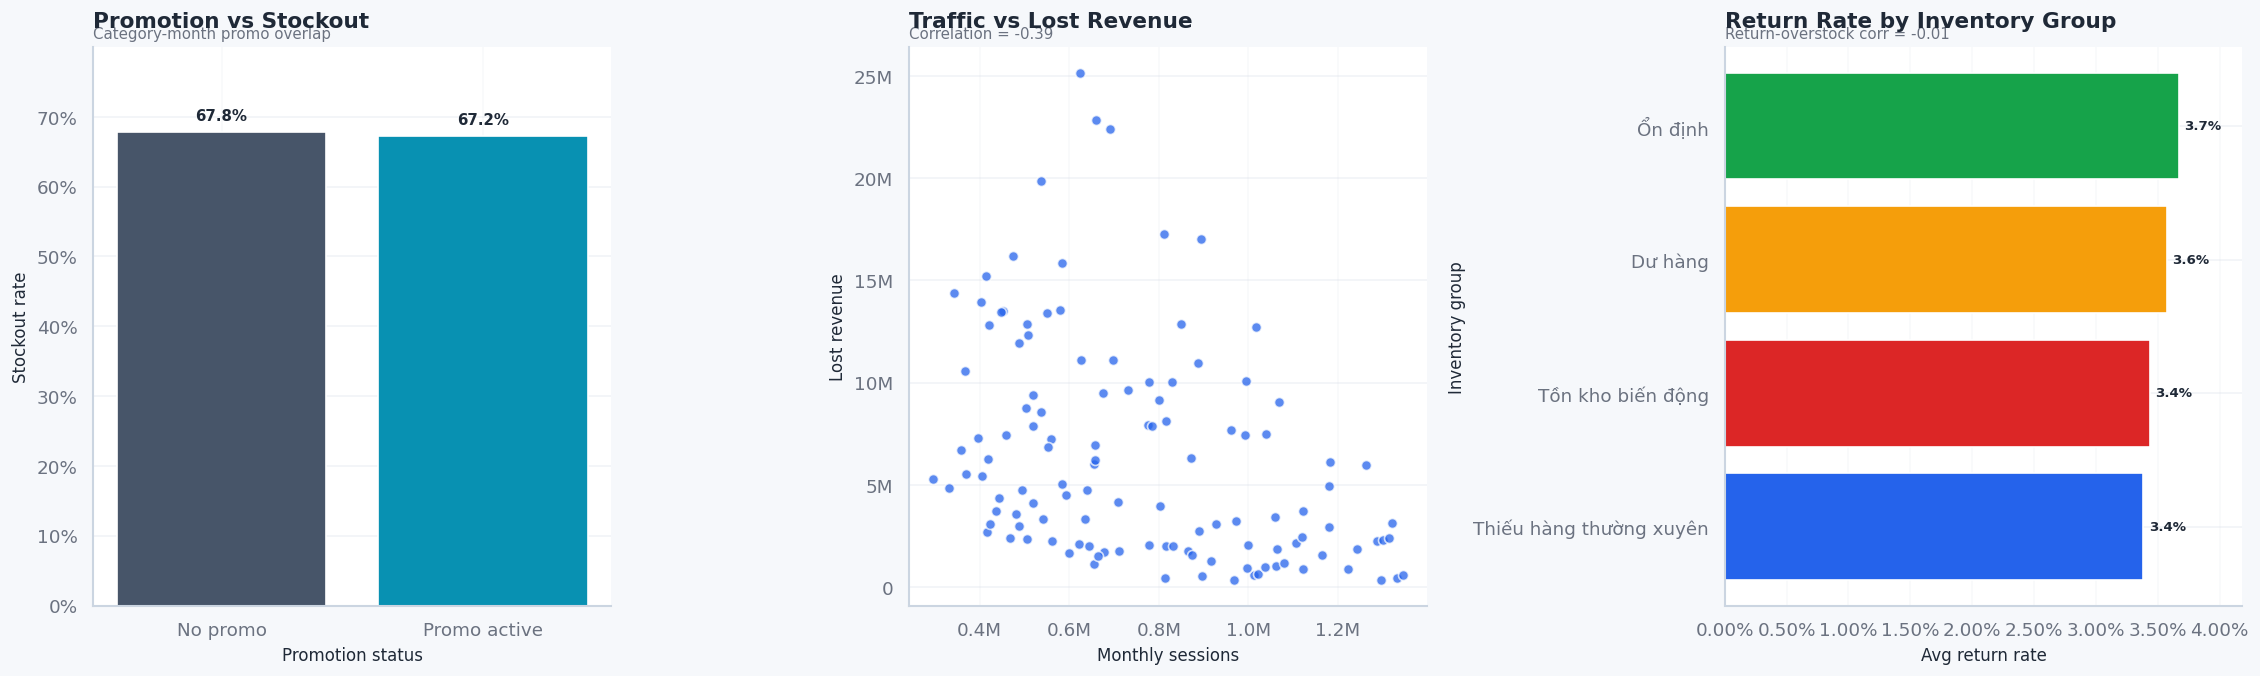

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.8), facecolor=BACKGROUND)

promo_plot = promo_impact.copy()
promo_plot['label'] = promo_plot['promo_active'].map({True: 'Promo active', False: 'No promo'})
axes[0].bar(promo_plot['label'], promo_plot['stockout_rate'], color=[PALETTE['accent'] if x else PALETTE['neutral'] for x in promo_plot['promo_active']], edgecolor='white')
clean_axis(axes[0], 'Promotion vs Stockout', 'Promotion status', 'Stockout rate', subtitle='Category-month promo overlap')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
label_vbars(axes[0], fmt=lambda v: fmt_percent(v))

axes[1].scatter(traffic_inventory['sessions'], traffic_inventory['lost_revenue'], color=PALETTE['stockout'], alpha=0.75, edgecolor='white')
clean_axis(axes[1], 'Traffic vs Lost Revenue', 'Monthly sessions', 'Lost revenue', subtitle=f'Correlation = {fmt_number(traffic_lost_corr, 2)}')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_number(x/1_000_000, 1) + 'M'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: fmt_currency(x, 0)))

returns_plot = returns_impact.sort_values('avg_return_rate', ascending=True)
axes[2].barh(returns_plot['inventory_group'], returns_plot['avg_return_rate'], color=returns_plot['inventory_group'].map(GROUP_COLORS), edgecolor='white')
clean_axis(axes[2], 'Return Rate by Inventory Group', 'Avg return rate', 'Inventory group', subtitle=f'Return-overstock corr = {fmt_number(return_overstock_corr, 2)}')
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
label_hbars(axes[2], fmt=lambda v: fmt_percent(v), fontsize=8)

plt.tight_layout()
plt.show()


#### **Advanced Diagnostic Insight: Promotion, Traffic, Returns**

Phần cross-table này dùng thêm promotion, web traffic và returns để kiểm tra xem tồn kho xấu có đến từ các nguyên nhân bên ngoài inventory hay không.

**Promotion:** Stockout rate trong tháng có promotion là **67.2%**, gần như không khác tháng không promotion (**67.8%**). Điều này cho thấy promotion không làm tăng tần suất thiếu hàng một cách rõ ràng. Tuy nhiên, lost revenue trong nhóm promo-active lên tới **722.6M**, cao hơn rất nhiều so với nhóm không promo (**77.3M**). Business implication ở đây là promotion có thể đang chạy trên các SKU/category có doanh thu lớn hơn, nên khi thiếu hàng xảy ra trong giai đoạn có campaign, thiệt hại tài chính lớn hơn. Vì vậy, trước mỗi campaign cần có checklist inventory readiness cho SKU được đẩy bán.

**Web traffic:** Tháng traffic cao có stockout rate **68.0%**, chỉ nhỉnh hơn tháng thường **67.0%**. Correlation giữa sessions và lost revenue là **-0.39**, nghĩa là chưa có bằng chứng rằng traffic cao trực tiếp kéo lost revenue tăng. Đây là tín hiệu quan trọng: vấn đề stockout không đơn giản là “web nhiều khách quá nên hết hàng”, mà có khả năng nằm ở SKU mix, replenishment timing và allocation. Vì web traffic chỉ ở cấp tháng, chưa đến cấp SKU, kết quả này nên được xem là market-level check, không phải bằng chứng nhân quả.

**Returns:** Return rate giữa các nhóm tồn kho rất gần nhau, khoảng **3.4% - 3.7%**. Nhóm “Dư hàng” có return rate **3.6%**, không cao hơn đáng kể so với nhóm “Ổn định” (**3.7%**). Correlation giữa return rate và overstock gần như bằng 0 (**-0.01**), nên returns không phải nguyên nhân chính làm dư hàng. Điều này giúp loại bỏ một giả thuyết: hàng dư không đến chủ yếu từ việc khách trả hàng, mà nhiều khả năng đến từ forecast sai, nhập sai SKU, hoặc replenishment không khớp demand.

**Khuyến nghị hành động:** với promotion, cần kiểm tra tồn kho trước campaign cho SKU/category được đẩy bán; với traffic, cần nối thêm dữ liệu conversion và product view theo SKU nếu muốn chứng minh tác động; với returns, không nên ưu tiên xử lý overstock bằng chính sách return trước, mà nên tập trung vào forecast, allocation và markdown/bundle cho SKU dư hàng.

**Kết luận:** Cross-table checks cho thấy nguyên nhân chính của vấn đề tồn kho vẫn nằm trong cách phân bổ và lập kế hoạch tồn kho, không phải do promotion, traffic hay returns một cách trực tiếp.


## 15. [Executive Summary] Tóm tắt cho báo cáo

Phần này gom toàn bộ câu chuyện thành bản tóm tắt cho stakeholder.

Nếu chỉ có thời gian đọc một phần, hãy đọc phần này. Nó trả lời trực tiếp:

- Vấn đề tồn kho chính là gì?
- Vấn đề nằm ở nhóm nào?
- Mã nào có rủi ro sắp tới?
- Doanh nghiệp nên xử lý như thế nào?
- Cơ hội tài chính nếu cải thiện là bao nhiêu?

Mục tiêu là giúp người đọc hiểu logic kinh doanh mà không cần xem code.

In [47]:
final_summary = pd.DataFrame({
    'Cấp độ': [
        'Descriptive - Chuyện gì xảy ra?',
        'Diagnostic - Vì sao xảy ra?',
        'Predictive - Điều gì có thể xảy ra?',
        'Prescriptive - Nên làm gì?'
    ],
    'Phần trong notebook': [
        'KPI + contradiction explanation + distributions',
        'Category/segment/lost revenue/overstock/matrix + Streetwear SKU mix + cross-table checks',
        'Dynamic ROP + ROP sensitivity + stockout risk tier',
        'Priority score + action ROI + realistic scenario + 30/60/90 plan'
    ],
    'Thông điệp chính': [
        f'Stockout rate {fmt_percent(stockout_rate)}, overstock rate {fmt_percent(overstock_rate)}, fill rate {fmt_percent(fill_rate_avg)} are explainable because metrics measure different things.',
        f'Lost revenue estimated at {fmt_currency(total_lost_revenue)}; Streetwear needs SKU-level mix correction, not category-level blanket stock increase.',
        f'Current ROP flags only {fmt_number(below_rop_records)} records; calibrated ROP and risk tier should be used together.',
        f'Base case scenario can recover {fmt_currency(base_case["net_recovered_revenue"])} net revenue and {fmt_currency(base_case["net_recovered_margin"])} net margin under realistic assumptions.'
    ],
    'Ý nghĩa kinh doanh': [
        'Không nên xem fill rate cao là bằng chứng tồn kho khỏe; cần điều tra stockout days và days of supply outliers.',
        'Cần xử lý sai cơ cấu SKU, đặc biệt trong Streetwear.',
        'ROP cần calibration trước khi dùng làm policy; risk tier là danh sách theo dõi rộng hơn.',
        'Prescriptive phải đi kèm vốn cần bỏ ra, ROI, owner và timeline.'
    ]
})

display(final_summary)

export_files = [
    'inventory_kpi.csv',
    'lost_by_category.csv',
    'product_priority.csv',
    'rop_validation.csv',
    'tradeoff_by_group.csv',
    'streetwear_sku_mix.csv',
    'rop_sensitivity.csv',
    'prescriptive_roi_top_skus.csv',
    'realistic_scenario_matrix.csv',
    'cross_table_inventory_checks.csv'
]
export_checks = pd.DataFrame({'file': export_files})
export_checks['path'] = export_checks['file'].apply(lambda f: str(OUTPUT_DIR / f))
export_checks['exists'] = export_checks['file'].apply(lambda f: (OUTPUT_DIR / f).exists())
export_checks['rows'] = export_checks['file'].apply(lambda f: len(pd.read_csv(OUTPUT_DIR / f)) if (OUTPUT_DIR / f).exists() else 0)
display(export_checks)


,Cấp độ,Phần trong notebook,Thông điệp chính,Ý nghĩa kinh doanh
0,Descriptive - Chuyện gì xảy ra?,KPI + contradiction explanation + distributions,"Stockout rate 67.3%, overstock rate 76.3%, fill rate 96.1% are explainable because metrics measure different things.",Không nên xem fill rate cao là bằng chứng tồn kho khỏe; cần điều tra stockout days và days of supply outliers.
1,Diagnostic - Vì sao xảy ra?,Category/segment/lost revenue/overstock/matrix + Streetwear SKU mix + cross-table checks,"Lost revenue estimated at 799.9M; Streetwear needs SKU-level mix correction, not category-level blanket stock increase.","Cần xử lý sai cơ cấu SKU, đặc biệt trong Streetwear."
2,Predictive - Điều gì có thể xảy ra?,Dynamic ROP + ROP sensitivity + stockout risk tier,Current ROP flags only 5 records; calibrated ROP and risk tier should be used together.,ROP cần calibration trước khi dùng làm policy; risk tier là danh sách theo dõi rộng hơn.
3,Prescriptive - Nên làm gì?,Priority score + action ROI + realistic scenario + 30/60/90 plan,Base case scenario can recover 100.8M net revenue and 20.4M net margin under realistic assumptions.,"Prescriptive phải đi kèm vốn cần bỏ ra, ROI, owner và timeline."


,file,path,exists,rows
0,inventory_kpi.csv,/home/ductien/Documents/DATATHON_2026/outputs/inventory_kpi.csv,True,10
1,lost_by_category.csv,/home/ductien/Documents/DATATHON_2026/outputs/lost_by_category.csv,True,4
2,product_priority.csv,/home/ductien/Documents/DATATHON_2026/outputs/product_priority.csv,True,1624
3,rop_validation.csv,/home/ductien/Documents/DATATHON_2026/outputs/rop_validation.csv,True,2
4,tradeoff_by_group.csv,/home/ductien/Documents/DATATHON_2026/outputs/tradeoff_by_group.csv,True,4
5,streetwear_sku_mix.csv,/home/ductien/Documents/DATATHON_2026/outputs/streetwear_sku_mix.csv,True,4
6,rop_sensitivity.csv,/home/ductien/Documents/DATATHON_2026/outputs/rop_sensitivity.csv,True,54
7,prescriptive_roi_top_skus.csv,/home/ductien/Documents/DATATHON_2026/outputs/prescriptive_roi_top_skus.csv,True,20
8,realistic_scenario_matrix.csv,/home/ductien/Documents/DATATHON_2026/outputs/realistic_scenario_matrix.csv,True,36
9,cross_table_inventory_checks.csv,/home/ductien/Documents/DATATHON_2026/outputs/cross_table_inventory_checks.csv,True,3


## **16. [Report-ready] Tổng kết theo flow chuẩn cho báo cáo**

### **1. Bối cảnh kinh doanh**

Doanh nghiệp đang gặp một bài toán tồn kho hai chiều: vừa có nhiều thời điểm thiếu hàng, vừa có nhiều hàng dư trong kho. Với ngành thời trang, điều này đặc biệt rủi ro vì nhu cầu thay đổi nhanh và sản phẩm có thể lỗi mùa nếu tồn quá lâu.

Mục tiêu không phải là nhập thêm hàng cho toàn bộ danh mục, mà là **đưa đúng hàng về đúng mã sản phẩm, đúng thời điểm và đúng mức nhu cầu**.

### **2. Hiện trạng chính**

Tỷ lệ thiếu hàng đạt **67.3%**, tỷ lệ dư hàng đạt **76.3%**, trong khi tỷ lệ đáp ứng đơn hàng vẫn **96.1%**. Các con số này không thật sự mâu thuẫn vì chúng đo các góc khác nhau: stockout flag chỉ cần có thiếu hàng trong tháng, còn fill rate vẫn có thể cao nếu số ngày thiếu hàng ít.

Điểm đáng lo hơn là **days of supply trung bình 912.7 ngày**, cho thấy một phần hàng đang bán chậm hoặc bị kéo lên bởi outlier. Đây là tín hiệu cần điều tra, không nên bỏ qua.

### **3. Nguyên nhân và tác động tài chính**

Thiếu hàng làm mất ước tính **151,803 sản phẩm bán ra**, tương đương **799.9M doanh thu** và **161.9M lợi nhuận gộp**. **Streetwear** là nhóm chịu tác động lớn nhất, nhưng phân tích sâu hơn cho thấy Streetwear không phải một vấn đề duy nhất: có mã cần bổ sung và có mã cần giảm/xả.

Vì vậy, hướng xử lý đúng là SKU-level mix correction, không phải tăng hàng Streetwear đại trà.

### **4. Dự báo và cảnh báo rủi ro**

Điểm đặt hàng lại hiện tại chỉ bắt được rất ít bản ghi, vì ROP thấp hơn nhiều so với tồn kho bình quân và dữ liệu là snapshot theo tháng. ROP không nên bị bỏ, nhưng cần calibration bằng lead time dài hơn, service level cao hơn, percentile demand và mùa vụ.

Bảng xếp hạng rủi ro thiếu hàng được dùng như danh sách theo dõi rộng hơn, giúp đội inventory kiểm tra nhóm `Critical` và `High` trước kỳ bán tiếp theo.

### **5. Khuyến nghị hành động**

Prescriptive cần đi kèm vốn, ROI và owner. Với top priority SKUs, notebook ước tính vốn cần bổ sung, doanh thu/lợi nhuận có thể thu hồi và ROI proxy theo base case 70% demand recovery.

Khuyến nghị triển khai theo nhóm:

- Nhóm thiếu hàng: tăng tồn an toàn có kiểm soát.
- Nhóm dư hàng: giảm nhập, bundle hoặc markdown có chọn lọc.
- Nhóm biến động: xem lại dự báo, lịch nhập và phân bổ.
- Nhóm ổn định: tiếp tục theo dõi.

### **6. Kịch bản tài chính thực tế**

Kịch bản tuyến tính chỉ là upside thô. Kịch bản thực tế hơn cần trừ phần nhu cầu không quay lại và phần doanh thu bị cannibalization. Base case sử dụng giảm stockout 20%, thu hồi 70% nhu cầu và cannibalization 10% để tạo vùng quyết định thận trọng hơn.

### **7. Kế hoạch 30/60/90 ngày**

- **0-30 ngày:** Inventory Planning + BI kiểm tra top SKU, tồn thực tế, đơn hàng nhập sắp về, lead time và lịch campaign.
- **31-60 ngày:** Merchandising + Procurement điều chỉnh safety stock cho nhóm thiếu hàng và markdown/bundle nhóm dư hàng.
- **61-90 ngày:** BI + Finance + Ops đo ROI pilot, triển khai dashboard tháng và quyết định mở rộng.

### **8. Cross-table checks**

Promotion, web traffic và returns được dùng như các kiểm tra bổ sung. Kết quả nên được xem là tín hiệu điều tra, không phải bằng chứng nhân quả tuyệt đối. Nếu traffic hoặc promotion trùng với stockout/lost revenue cao, cần chuẩn bị tồn kho trước campaign. Nếu returns không liên quan mạnh đến overstock, nguyên nhân dư hàng nhiều khả năng nằm ở mua hàng, phân bổ hoặc dự báo.

### **Kết luận cuối cùng**

Cơ hội lớn nhất không nằm ở việc tăng tồn kho toàn bộ danh mục. Cơ hội lớn nhất nằm ở việc **tái phân bổ hàng tồn thông minh hơn**: bổ sung đúng mã đang thiếu, giảm hàng ở mã đang dư, hiệu chỉnh cảnh báo sớm và triển khai pilot có đo ROI trước khi mở rộng.
